In [1]:
import EOSutils as meos

import numpy as np
import matplotlib.pyplot as plt

import matplotlib.style
import matplotlib as mpl
import matplotlib.colors as colors
import matplotlib.cm as cmx
from mpl_toolkits.axes_grid1 import make_axes_locatable

mpl.style.use('classic')

from astropy.table import Table
from astropy import units as u
from astropy.constants import G

from decimal import Decimal

import mesa_helper as mh
import os
import shutil
import copy
import time
import warnings

from scipy import ndimage, interpolate, optimize
from scipy.integrate import quad
import pickle

%matplotlib inline
%load_ext autoreload
%autoreload 2

# calculate MESA columns

## functions for fermi-dirac integral calculation (for degeneracy parameter, aka final column of mesa table)

In [2]:
def quad_fdk(k, eta):
    r = quad(lambda x: (x**k)/(1.+np.exp(x-eta)),
            0, np.inf,epsabs=1e-300,epsrel=1e-8,limit=100)
    return r[0], r[1]

def quad_gfdk(k, eta, theta):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        def func(x):
            return ((x**k)*np.sqrt(1+ (0.5*theta*x)))/(1.+np.exp(x-eta))
        # first derivative of the above. note: this only holds if k>0 (true in our case, k=0.5)
        # see Fukushima 2015 "Precise and fast computation of Fermi-Dirac integral of
        #  integer and half integer order by piecewise minimax rational approximation"
        def dfunc(x):
            return k*(x)**(k-1)*np.sqrt(1+theta*x/2.)/(1.+np.exp(x-eta))
    r = quad(func, 0, np.inf,epsabs=1e-300,epsrel=1e-8,limit=100)
    dr = quad(dfunc, 0, np.inf,epsabs=1e-300,epsrel=1e-8,limit=100)
    return r[0], dr[0]


h = 6.62607015e-27 # erg*s
m_e = 9.1093837015e-28 #g
c = 2.99792458e10 #cm/s
kB = 1.380649e-16 #erg/K
m_p = 1.6605e-24 #g/amu

def fdint_abs_diff(eta_test, theta, fdint_to_match):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        fdint_test, dfdint_test = quad_gfdk(0.5, eta_test, theta)
    return np.abs(fdint_to_match - fdint_test) #, dfdint_test

def solve_fdint(rhs, theta, eta0 = -0.01):
    #opt = optimize.minimize(fdint_abs_diff, x0=eta0, args=(theta,rhs), jac=True, bounds=[(-1000.,1000.)],tol=1.e-10)
    opt = optimize.minimize(fdint_abs_diff, x0=eta0, args=(theta,rhs), bounds=[(-1000.,1000.)],tol=1.e-10)
    opt_eta = opt.x[0]
    #print(opt.success)
    #print(opt.message)
    return opt_eta

# other columns

In [3]:
# load SCVH tables, which have H2 vs. H, He vs. He+ fraction informaton for mu, mu_e calcs
infile = open("./SCVH_H_rhoT_with_Hfractions.pkl","rb")
scvh_H_rhoT = pickle.load(infile)
infile.close()

infile = open("./SCVH_He_rhoT_with_Hefractions.pkl","rb")
scvh_He_rhoT = pickle.load(infile)
infile.close()

In [4]:
def MESA_cols_6to16(table, X=1, Y=0, mu_Z=None, calc_eta=False):
    """
    this assumes that the following attributes are already defined:
    table.log10Tgrid
    table.log10rhogrid
    table.log10Pgrid
    table.log10Egrid
    table.log10Sgrid
    table.chiRho
    table.dlS_dlrho_T
    table.chiT
    table.dlS_dlT_rho

    and that the remainder of the MESA columns already exist in the table object, they just currently equal None.
    """
    S = 10**table.log10Sgrid #erg g^-1 K^-1
    rho = 10**table.log10rhogrid # g cm^-3
    E = 10**table.log10Egrid # erg g^-1
    T = 10**table.log10Tgrid # K

    dlrho_dlT_P = -1. * table.chiT/table.chiRho
    dlrho_dlP_T = 1./table.chiRho 

    dlS_dlT_P = table.dlS_dlT_rho - (table.dlS_dlrho_T * (table.chiT/table.chiRho))
    dlS_dlP_T = table.dlS_dlrho_T/table.chiRho

    # prevent negative chiRho, chiT, Cp, Cv, gamma1, grad_ad values by eliminating wrong-signed finite difference quantities ahead of time
    # chiRho, chiT must be positive
    # dlS_dlT_P, dlS_dlT_rho must be positive
    # dlS_dlP_T, dlS_dlrho_T must be negative

    # set wrong-signed values to nan
    table.chiRho[table.chiRho <= 0] = np.nan
    table.chiT[table.chiT <= 0] = np.nan
    dlS_dlT_P[dlS_dlT_P <= 0] = np.nan
    table.dlS_dlT_rho[table.dlS_dlT_rho <= 0] = np.nan
    dlS_dlP_T[dlS_dlP_T >= 0] = np.nan
    table.dlS_dlrho_T[table.dlS_dlrho_T >= 0] = np.nan

    # fill in by interpolation    
    table.chiRho = meos.fill_in_nans(table.chiRho, table)
    table.chiT = meos.fill_in_nans(table.chiT, table)
    dlS_dlT_P = meos.fill_in_nans(dlS_dlT_P, table)
    table.dlS_dlT_rho = meos.fill_in_nans(table.dlS_dlT_rho, table)
    dlS_dlP_T = meos.fill_in_nans(dlS_dlP_T, table)
    table.dlS_dlrho_T = meos.fill_in_nans(table.dlS_dlrho_T, table)

    table.grad_ad = -1.* table.dlS_dlrho_T/((table.chiRho*table.dlS_dlT_rho) - (table.chiT*table.dlS_dlrho_T))
    
    table.Cp = S * dlS_dlT_P
    table.Cv = S * table.dlS_dlT_rho

    table.dE_drho_T = table.dlE_dlrho_T * (E/rho) #dE/drho = (dlE/dlrho) * (E/rho)
    table.dS_dT_rho = table.dlS_dlT_rho * (S/T) #dS/dT = (dlS/dlT) * (S/T)
    table.dS_drho_T = table.dlS_dlrho_T * (S/rho) #dS/drho = (dlS/dlrho) * (S/rho)

   # below assumes fully ionized material! wrong (see Helled+2025, SCVH paper)
    #table.mu = (4./(6*X + 4*Y + 2))*np.ones_like(table.log10Tgrid)
    #table.log_free_e = np.log10(0.5*(1+X))*np.ones_like(table.log10Tgrid) # = 1/mu_e 

    # correct proportions of molecular/atomic/ionized material extrapolated from SCVH
    f_H2 = scvh_H_rhoT.nm_grid
    f_H = scvh_H_rhoT.na_grid

    f_He = scvh_He_rhoT.nm_grid
    f_Heplus = scvh_He_rhoT.na_grid

    mu_H = 0.5 + 1.5*f_H2 + 0.5*f_H
    mu_He = (4./3.) + (8./3.)*f_He + (4./3.)*f_Heplus
        
    Z = 1. - X - Y

    if Z > 0:  
        mu_tot = 1./((X/mu_H) + (Y/mu_He) + (Z/mu_Z))
    else:
        mu_tot = 1./((X/mu_H) + (Y/mu_He))
        
    table.mu = mu_tot

    #for pure metal tables, mu_e = 0 and log_free_e = -inf
    if Z == 1.:
        table.log_free_e = -100.*np.ones_like(table.log10Tgrid)
    else:
        mu_e = 1./( X*((1.-f_H2-f_H)/(2*mu_H)) + Y*((2.-2*f_He-f_Heplus)/(3.*mu_He)) )
        table.log_free_e = np.log10(1./mu_e)

    table.gamma3 = (-1. * (table.dlS_dlrho_T/table.dlS_dlT_rho)) + 1.
    table.gamma1 = table.chiT*(table.gamma3 - 1.) + table.chiRho

    table.gamma1[table.gamma1 <= 0] = np.nan
    table.grad_ad[table.grad_ad <= 0] = np.nan
    table.gamma1 = meos.fill_in_nans(table.gamma1, table)
    table.grad_ad = meos.fill_in_nans(table.grad_ad, table)
    
    table.eta = np.zeros_like(table.log10Tgrid)

    if calc_eta is True:
        for i in range(np.shape(table.log10Tgrid)[1]):
            print(table.log10Tgrid[1][i])
            for j in range(np.shape(table.log10rhogrid)[0]):
                this_recip_mu_e = (10**table.log_free_e[j,i])
                this_n_e = 10**table.log10rhogrid[j,i] * this_recip_mu_e * (1./m_p) # g/cm^3 * e-/amu * amu/g = e-/cm^3
                this_T = 10**table.log10Tgrid[j,i]
                rhs = (this_n_e * h**3)/(4*np.pi*(2*m_e*kB*this_T)**(3./2.))
                theta = (kB*this_T)/(m_e*c**2)
    
                # if too few free e-, then just set eta to an arbitrary low value (same thing is done in MESA EoS code)
                if table.log_free_e[j,i]  <= -4:
                    opt_eta_ = -20
                else:
                    #print("")
                    #print(this_n_e)
                    #print(this_T)
                    #print(theta)
                    #print(rhs)
                    opt_eta_ = solve_fdint(rhs=rhs,theta=theta)
                table.eta[j,i] = opt_eta_
        

    return

# put table in MESA format and write file

## first: re-map from (log10rho, log10T) to (log10Q, log10T) and extrapolate to make rectangular

In [5]:
class log10Q_log10T_table(object):
    def __init__(self, units='cgs', **kwargs):
        if units == 'cms' or units == 'cgs' or units == 'CMS':
            self.units = units
        else: 
            print('units must be cgs or mks or CMS (T [K], P [GPa], rho [g/cm^3], U [MJ/kg], S [MJ/kg/K])')

        self.X = None
        self.Y = None
        
        self.atomic_number = None
        self.mass_number = None

        self.log10Qgrid_QT = None
        self.log10Tgrid_QT = None
        self.log10Pgrid_QT = None
        self.log10Egrid_QT = None
        self.log10Sgrid_QT = None

        self.chiRho_QT = None 
        self.chiT_QT = None 
        self.Cp_QT = None
        self.Cv_QT = None

        self.dE_drho_T_QT = None
        self.dS_dT_rho_QT = None
        self.dS_drho_T_QT = None
        self.mu_QT = None
        self.log_free_e_QT = None
        self.gamma1_QT = None
        self.gamma3_QT = None
        self.grad_ad_QT = None
        self.eta_QT = None
        

In [6]:
def extrapolate_to_wide_rho_grid(old_attrgrid, old_rhoarr, old_Tarr, new_rhogrid, new_Tgrid):
    """
    takes a grid defined on -8 <= log10rho <= 6 and linearly extrapolates it to -20 <= log10rho <= 9.4, which is wide enough to include the entire rectangular log10Q grid
    """

    interp_attr_given_log10rho_log10T = interpolate.RegularGridInterpolator(points=(old_rhoarr, old_Tarr), values=old_attrgrid, bounds_error=False, fill_value=None, method='linear')

    new_attrgrid = interp_attr_given_log10rho_log10T((new_rhogrid, new_Tgrid))

    return new_attrgrid

In [7]:
def cut_out_relevant_Q(new_attrgrid, new_rhogrid, new_Tgrid):

    Qgrid = new_rhogrid - 2*new_Tgrid + 12

    desired_Qarr = np.arange(-12.,5.45,0.05)
    desired_Tarr = new_Tgrid[0]
    existing_rhoarr = new_rhogrid[:,0]

    masked_attrgrid = np.zeros_like(new_attrgrid)
    masked_rhogrid = np.zeros_like(new_attrgrid)
    masked_Tgrid = np.zeros_like(new_attrgrid)

    for i,rho in enumerate(existing_rhoarr):
        for j,T in enumerate(desired_Tarr):
            q = rho - 2*T + 12
            if (q >= -12) and (q <= 5.4):
                masked_attrgrid[i, j] = new_attrgrid[i,j]
                masked_rhogrid[i, j] = new_rhogrid[i,j]
                masked_Tgrid[i, j] = new_Tgrid[i,j]
            else:
                masked_attrgrid[i, j] = np.nan
                masked_rhogrid[i, j] = np.nan
                masked_Tgrid[i, j] = np.nan
            
    return masked_attrgrid, masked_rhogrid, masked_Tgrid

In [8]:
def change_to_QT(widerho_attr_grid, widerho_grid, widerho_Tgrid):

    desired_Qarr = np.arange(-12.,5.45,0.05)
    desired_Tarr = widerho_Tgrid[0]

    current_Qgrid = widerho_grid - 2*widerho_Tgrid + 12
    #print(current_Qgrid)

    Qgrid, Tgrid = np.meshgrid(desired_Qarr, desired_Tarr)
    #print(Qgrid[:,0])

    attr_QTgrid = np.zeros_like(Qgrid)
    #print(Qgrid)
    
    for i, q in enumerate(desired_Qarr):

        thisQmask = (np.abs(current_Qgrid - q) < 0.01)
        #print(len(widerho_Tgrid[thisQmask]))
        attr_QTgrid[:,i] = widerho_attr_grid[thisQmask]
        
    
    return attr_QTgrid

In [9]:
def change_table_coordinates(table, extrapolation_row_idxs=None,extrapolation_col_idxs=None):
    """
    input table must already have all MESA columns defined
    """

    QT_table = log10Q_log10T_table()

    QT_table.X = table.X
    QT_table.Y = table.Y
    if hasattr(table, 'atomic_number'):
        QT_table.atomic_number = table.atomic_number
    if hasattr(table, 'mass_number'):
        QT_table.mass_number = table.mass_number

    Tarr = table.log10Tgrid[0]
    Qarr = np.unique(np.round(table.log10Qgrid[table.log10Qgrid <= 5.4],6))
    numlogQs = len(Qarr)
    logQmin = np.min(Qarr)
    logQmax = np.max(Qarr)
    dellogQ = Qarr[1] - Qarr[0]

    wide_Tgrid, wide_rhogrid = np.meshgrid(table.log10Tgrid[0], np.arange(-20.,9.45,0.05))

    wide_Pgrid = extrapolate_to_wide_rho_grid(meos.fill_in_nans(table.log10Pgrid, table), old_rhoarr=table.log10rhogrid[:,0], old_Tarr=table.log10Tgrid[0], new_rhogrid=wide_rhogrid,new_Tgrid=wide_Tgrid)

    desired_Qarr = np.arange(-12.,5.45,0.05)
    desired_Tarr = wide_Tgrid[0]

    QT_table.log10Qgrid_QT, QT_table.log10Tgrid_QT = np.meshgrid(desired_Qarr, desired_Tarr)

    QT_table.log10Pgrid_QT = change_to_QT(wide_Pgrid, wide_rhogrid, wide_Tgrid)
    #print(QT_table.log10Pgrid_QT[np.isnan(QT_table.log10Pgrid_QT)])

    wide_Egrid = extrapolate_to_wide_rho_grid(meos.fill_in_nans(table.log10Egrid, table), old_rhoarr=table.log10rhogrid[:,0], old_Tarr=table.log10Tgrid[0], new_rhogrid=wide_rhogrid,new_Tgrid=wide_Tgrid)
    QT_table.log10Egrid_QT = change_to_QT(wide_Egrid, wide_rhogrid, wide_Tgrid)

    wide_Sgrid = extrapolate_to_wide_rho_grid(meos.fill_in_nans(table.log10Sgrid, table), old_rhoarr=table.log10rhogrid[:,0], old_Tarr=table.log10Tgrid[0], new_rhogrid=wide_rhogrid,new_Tgrid=wide_Tgrid)
    QT_table.log10Sgrid_QT = change_to_QT(wide_Sgrid, wide_rhogrid, wide_Tgrid)

    # chiT, chiRho, Cp returning nans in the first 3 rows (T = 2.0,2.05,2.1). Fix this by extrapolation
    wide_chiRho_grid = extrapolate_to_wide_rho_grid(meos.fill_in_nans(table.chiRho, table), old_rhoarr=table.log10rhogrid[:,0], old_Tarr=table.log10Tgrid[0], new_rhogrid=wide_rhogrid,new_Tgrid=wide_Tgrid)
    QT_table.chiRho_QT = change_to_QT(wide_chiRho_grid, wide_rhogrid, wide_Tgrid)
    QT_table.chiRho_QT = meos.fill_in_nans_QT(QT_table.chiRho_QT, QT_table, extrapolation_row_idxs=extrapolation_row_idxs,extrapolation_col_idxs=extrapolation_col_idxs)

    wide_chiT_grid = extrapolate_to_wide_rho_grid(meos.fill_in_nans(table.chiT, table), old_rhoarr=table.log10rhogrid[:,0], old_Tarr=table.log10Tgrid[0], new_rhogrid=wide_rhogrid,new_Tgrid=wide_Tgrid)
    QT_table.chiT_QT = change_to_QT(wide_chiT_grid, wide_rhogrid, wide_Tgrid)
    QT_table.chiT_QT = meos.fill_in_nans_QT(QT_table.chiT_QT, QT_table, extrapolation_row_idxs=extrapolation_row_idxs,extrapolation_col_idxs=extrapolation_col_idxs)

    wide_Cp_grid = extrapolate_to_wide_rho_grid(meos.fill_in_nans(table.Cp, table), old_rhoarr=table.log10rhogrid[:,0], old_Tarr=table.log10Tgrid[0], new_rhogrid=wide_rhogrid,new_Tgrid=wide_Tgrid)
    QT_table.Cp_QT = change_to_QT(wide_Cp_grid, wide_rhogrid, wide_Tgrid)
    QT_table.Cp_QT = meos.fill_in_nans_QT(QT_table.Cp_QT, QT_table, extrapolation_row_idxs=extrapolation_row_idxs,extrapolation_col_idxs=extrapolation_col_idxs)

    wide_Cv_grid = extrapolate_to_wide_rho_grid(meos.fill_in_nans(table.Cv, table), old_rhoarr=table.log10rhogrid[:,0], old_Tarr=table.log10Tgrid[0], new_rhogrid=wide_rhogrid,new_Tgrid=wide_Tgrid)
    QT_table.Cv_QT = change_to_QT(wide_Cv_grid, wide_rhogrid, wide_Tgrid)
    QT_table.Cv_QT = meos.fill_in_nans_QT(QT_table.Cv_QT, QT_table, extrapolation_row_idxs=extrapolation_row_idxs,extrapolation_col_idxs=extrapolation_col_idxs)

    wide_dE_drho_T_grid = extrapolate_to_wide_rho_grid(meos.fill_in_nans(table.dE_drho_T, table), old_rhoarr=table.log10rhogrid[:,0], old_Tarr=table.log10Tgrid[0], new_rhogrid=wide_rhogrid,new_Tgrid=wide_Tgrid)
    QT_table.dE_drho_T_QT = change_to_QT(wide_dE_drho_T_grid, wide_rhogrid, wide_Tgrid)
    QT_table.dE_drho_T_QT = meos.fill_in_nans_QT(QT_table.dE_drho_T_QT, QT_table, extrapolation_row_idxs=extrapolation_row_idxs,extrapolation_col_idxs=extrapolation_col_idxs)

    wide_dS_dT_rho_grid = extrapolate_to_wide_rho_grid(meos.fill_in_nans(table.dS_dT_rho, table), old_rhoarr=table.log10rhogrid[:,0], old_Tarr=table.log10Tgrid[0], new_rhogrid=wide_rhogrid,new_Tgrid=wide_Tgrid)

    QT_table.dS_dT_rho_QT = change_to_QT(wide_dS_dT_rho_grid, wide_rhogrid, wide_Tgrid)
    QT_table.dS_dT_rho_QT = meos.fill_in_nans_QT(QT_table.dS_dT_rho_QT, QT_table, extrapolation_row_idxs=extrapolation_row_idxs,extrapolation_col_idxs=extrapolation_col_idxs)

    wide_dS_drho_T_grid = extrapolate_to_wide_rho_grid(meos.fill_in_nans(table.dS_drho_T, table), old_rhoarr=table.log10rhogrid[:,0], old_Tarr=table.log10Tgrid[0], new_rhogrid=wide_rhogrid,new_Tgrid=wide_Tgrid)
    QT_table.dS_drho_T_QT = change_to_QT(wide_dS_drho_T_grid, wide_rhogrid, wide_Tgrid)
    QT_table.dS_drho_T_QT = meos.fill_in_nans_QT(QT_table.dS_drho_T_QT, QT_table, extrapolation_row_idxs=extrapolation_row_idxs,extrapolation_col_idxs=extrapolation_col_idxs)

    wide_mu_grid = extrapolate_to_wide_rho_grid(meos.fill_in_nans(table.mu, table), old_rhoarr=table.log10rhogrid[:,0], old_Tarr=table.log10Tgrid[0], new_rhogrid=wide_rhogrid,new_Tgrid=wide_Tgrid)
    QT_table.mu_QT = change_to_QT(wide_mu_grid, wide_rhogrid, wide_Tgrid)

    wide_log_free_e_grid = extrapolate_to_wide_rho_grid(meos.fill_in_nans(table.log_free_e, table), old_rhoarr=table.log10rhogrid[:,0], old_Tarr=table.log10Tgrid[0], new_rhogrid=wide_rhogrid,new_Tgrid=wide_Tgrid)
    QT_table.log_free_e_QT = change_to_QT(wide_log_free_e_grid, wide_rhogrid, wide_Tgrid)

    table.gamma1[table.gamma1 <= 0] = np.nan
    table.grad_ad[table.grad_ad <= 0] = np.nan
    
    wide_gamma1_grid = extrapolate_to_wide_rho_grid(meos.fill_in_nans(table.gamma1, table), old_rhoarr=table.log10rhogrid[:,0], old_Tarr=table.log10Tgrid[0], new_rhogrid=wide_rhogrid,new_Tgrid=wide_Tgrid)
    QT_table.gamma1_QT = change_to_QT(wide_gamma1_grid, wide_rhogrid, wide_Tgrid)
    QT_table.gamma1_QT = meos.fill_in_nans_QT(QT_table.gamma1_QT, QT_table, extrapolation_row_idxs=extrapolation_row_idxs,extrapolation_col_idxs=extrapolation_col_idxs)

    wide_gamma3_grid = extrapolate_to_wide_rho_grid(meos.fill_in_nans(table.gamma3, table), old_rhoarr=table.log10rhogrid[:,0], old_Tarr=table.log10Tgrid[0], new_rhogrid=wide_rhogrid,new_Tgrid=wide_Tgrid)
    QT_table.gamma3_QT = change_to_QT(wide_gamma3_grid, wide_rhogrid, wide_Tgrid)
    QT_table.gamma3_QT = meos.fill_in_nans_QT(QT_table.gamma3_QT, QT_table, extrapolation_row_idxs=extrapolation_row_idxs,extrapolation_col_idxs=extrapolation_col_idxs)

    wide_grad_ad_grid = extrapolate_to_wide_rho_grid(meos.fill_in_nans(table.grad_ad, table), old_rhoarr=table.log10rhogrid[:,0], old_Tarr=table.log10Tgrid[0], new_rhogrid=wide_rhogrid,new_Tgrid=wide_Tgrid)
    QT_table.grad_ad_QT = change_to_QT(wide_grad_ad_grid, wide_rhogrid, wide_Tgrid)
    QT_table.grad_ad_QT = meos.fill_in_nans_QT(QT_table.grad_ad_QT, QT_table, extrapolation_row_idxs=extrapolation_row_idxs,extrapolation_col_idxs=extrapolation_col_idxs)

    wide_eta_grid = extrapolate_to_wide_rho_grid(meos.fill_in_nans(table.eta, table), old_rhoarr=table.log10rhogrid[:,0], old_Tarr=table.log10Tgrid[0], new_rhogrid=wide_rhogrid,new_Tgrid=wide_Tgrid)
    QT_table.eta_QT = change_to_QT(wide_eta_grid, wide_rhogrid, wide_Tgrid)

    # deal with the (vanishingly small) number of table entries where grad_ad or gamma1 rounds to 0
    QT_table.gamma1_QT[QT_table.gamma1_QT <= 1.e-5] += 1.e-5
    QT_table.grad_ad_QT[QT_table.grad_ad_QT <= 1.e-5] += 1.e-5
    
    return QT_table

## write table to file

In [10]:
def write_MESA_table_QT(QTtable, outfilename, version=1, X=1.0, Z=0.0):
    """
    Convert a table in (Q,T) grid format into MESA's bizarre (T, Q) format and save to file.
    """
    Tarr = np.unique(QTtable.log10Tgrid_QT)
    numlogTs = len(Tarr)
    logTmin = np.min(Tarr)
    logTmax = np.max(Tarr)
    dellogT = Tarr[1] - Tarr[0]

    # only use Qs <= 5.4, because this is the value that corresponds to the boundary between physical and unphysical values in the CMS pure H table
    Qarr = np.round(np.unique(QTtable.log10Qgrid_QT), 2)

    numlogQs = len(Qarr)
    logQmin = np.min(Qarr)
    logQmax = np.max(Qarr)
    dellogQ = Qarr[1] - Qarr[0]
    
    header0keys = ['version','X','Z','num logTs','logT min','logT max','del logT','num logQs','logQ min','logQ max','del logQ']
    header0vals = [version,X,Z,numlogTs,logTmin,logTmax,dellogT,numlogQs,logQmin,logQmax,dellogQ]

    header0=""
    for k in header0keys:
        kstr = '{:>14}'.format(k)
        header0 = header0 + kstr

    header1=""
    for v in header0vals:
        vstr = '{:>14}'.format(str(np.round(v,6)))
        header1 = header1 + vstr

    header2keys =['logT','logPgas','logE','logS','chiRho','chiT','Cp','Cv','dE_dRho','dS_dT','dS_dRho','mu ','log_free_e','gamma1','gamma3','grad_ad','eta']

    with open(outfilename, 'w') as outfile:
        outfile.write(header0)
        outfile.write('\n')
        outfile.write(header1)
        outfile.write('\n')

        for i, logQ in enumerate(Qarr):
            outfile.write('\n')
            outfile.write('       logQ = logRho - 2*logT + 12')
            outfile.write('\n')
            logQstr = f"{np.round(logQ,6):#.4g}"
            logQstr = logQstr.split(".")[0] + '.' + logQstr.split(".")[1][0:2]
            outfile.write('{:>12}'.format(logQstr))
            outfile.write('\n')
            outfile.write('\n')
            header2=''
            for l, key in enumerate(header2keys):
                if l==0:
                    kstr = key
                elif l > 0 and l <= 3:
                    kstr = '{:>10}'.format(key)
                elif l > 3 and l <= 10:
                    kstr = '{:>14}'.format(key)
                else:
                    kstr = '{:>10}'.format(key)    
                header2 = header2 + kstr
            outfile.write(header2)
            outfile.write('\n')

            # write data here

            # get columns
            # attributes are named:
            # log10Qgrid, log10Tgrid, log10Pgrid, log10Egrid, log10Sgrid, chiRho, chiT, Cp, Cv, dE_drho_T, dS_dT_rho, dS_drho_T, mu, log_free_e, gamma1, gamma3, grad_ad, eta
            # every one of them is a (281, 121) array (281 rho values, 121 T values)

            thisQmask = (np.round(QTtable.log10Qgrid_QT,6) == logQ)

            for j in range(np.shape(QTtable.log10Qgrid_QT[thisQmask])[0]):
                rowList = [QTtable.log10Tgrid_QT[thisQmask][j], 
                           QTtable.log10Pgrid_QT[thisQmask][j],
                           QTtable.log10Egrid_QT[thisQmask][j],
                           QTtable.log10Sgrid_QT[thisQmask][j],
                           QTtable.chiRho_QT[thisQmask][j],
                           QTtable.chiT_QT[thisQmask][j],
                           QTtable.Cp_QT[thisQmask][j], 
                           QTtable.Cv_QT[thisQmask][j],
                           QTtable.dE_drho_T_QT[thisQmask][j],
                           QTtable.dS_dT_rho_QT[thisQmask][j],
                           QTtable.dS_drho_T_QT[thisQmask][j],
                           QTtable.mu_QT[thisQmask][j],
                           QTtable.log_free_e_QT[thisQmask][j], 
                           QTtable.gamma1_QT[thisQmask][j],
                           QTtable.gamma3_QT[thisQmask][j],
                           QTtable.grad_ad_QT[thisQmask][j],
                           QTtable.eta_QT[thisQmask][j],
                          ]
                           
                rowStr=""
                # from here: want different formatting for the different columns, actually 
                #logT   logPgas      logE      logS       chiRho         chiT           Cp           Cv      dE_dRho        dS_dT      dS_dRho      mu  log_free_e   gamma1    gamma3   grad_ad       eta
                #2.10  -4.28120   9.90528   9.17145  9.88041E-01  1.03588E+00  1.14092E+08  6.83968E+07 -1.90043E+22  5.43295E+05 -4.35851E+21  0.50000 -99.00000   1.64814   1.63724   0.38664  -20.00000

                for k, r in enumerate(rowList):
                    if k == 0:
                        rstr = "{:.2f}".format(r)
                    elif k > 0 and k <= 3:
                        rstr = ' ' + "{:.5f}".format(r)
                        rstr = '{:>10}'.format(rstr)
                    elif (k > 3 and k <= 10) or (k>=13 and k<=15):
                        try:
                            rstr = ' ' + meos.MESA_format_e(r)
                        except IndexError:
                            this_logrho = logQ + 2*rowList[0] - 12
                            if this_logrho < -8 or this_logrho > 6:
                                r = 0.
                                rstr = ' ' + "{:.5f}".format(r)

                            else:
                                print(k,header2keys[k],r,np.sign(r))

                                if k == 4:
                                    r = np.median(QTtable.chiRho_QT[np.isfinite(QTtable.chiRho_QT)])
                                elif k==5:
                                    r = np.median(QTtable.chiT_QT[np.isfinite(QTtable.chiT_QT)])
                                elif k==6:
                                    r = np.median(QTtable.Cp_QT[np.isfinite(QTtable.Cp_QT)])
                                elif k==7:
                                    r = np.median(QTtable.Cv_QT[np.isfinite(QTtable.Cv_QT)])
                                elif k==8:
                                    r = np.median(QTtable.dE_drho_T_QT[np.isfinite(QTtable.dE_drho_T_QT)])
                                elif k==9:
                                    r = np.median(QTtable.dS_dT_rho_QT[np.isfinite(QTtable.dS_dT_rho_QT)])
                                elif k==10:
                                    r = np.median(QTtable.dS_drho_T_QT[np.isfinite(QTtable.dS_drho_T_QT)])
                                
                                rstr = ' ' + "{:.5f}".format(r)
                                
                        rstr = '{:>14}'.format(rstr)
                    else:
                        rstr = ' ' + "{:.5f}".format(r)
                        rstr = '{:>10}'.format(rstr)
                    
                    rowStr = rowStr + rstr
                    
                outfile.write(rowStr)
                outfile.write('\n')

            
            outfile.write('\n')
            #outfile.write('\n')

    
    return

# For every EoS below, also save TC versions (smoothing = 1,2,5) and control versions (smoothing = 1,2,5 x scaling fac = 0.05, 0.1, 0.25)

In [11]:
smoothing_arr = np.array((1,2,5))
scaling_fac_arr = np.array((0.05,0.1,0.25))

# for plotting
x = np.arange(-12,5.45,0.05)
y1 = 2 - 0.5*x
y2 = 9 - 0.5*x



unphys_x = np.linspace(-8,6,50)
unphys_y = 3.3 + (1./2.)*np.linspace(-8,6,50) + np.log10(1) - (5./3)*np.log10(1)


# Load in pre-processed H, He tables from XY_eos_prep.ipynb

## H

In [12]:
infile = open("./cms19_mazevet2022_H_blend.pkl","rb")
bln_H = pickle.load(infile)
infile.close()

In [13]:
#start = time.time()
MESA_cols_6to16(bln_H,X=1.,Y=0.,calc_eta=True)
#end = time.time()
#print((end-start)/60.)

bln_H.log10Qgrid = bln_H.log10rhogrid - 2.*bln_H.log10Tgrid + 12
bln_H_QT = change_table_coordinates(bln_H)

#write_MESA_table_QT(bln_H_QT, './my_MESAformat_tables/mesa-planetblend_00z100x.data',version=1, X=1.0, Z=0.0)
write_MESA_table_QT(bln_H_QT, './meos_MESAformat_CMS19+HG23+rock+water/mesa-planetblend_00z100x.data',version=1, X=1.0, Z=0.0)

/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/3179727013.py:16: RuntimeWarning: overflow encountered in power
  S = 10**table.log10Sgrid #erg g^-1 K^-1
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/3179727013.py:18: RuntimeWarning: overflow encountered in power
  E = 10**table.log10Egrid # erg g^-1
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/3179727013.py:53: RuntimeWarning: invalid value encountered in multiply
  table.dE_drho_T = table.dlE_dlrho_T * (E/rho) #dE/drho = (dlE/dlrho) * (E/rho)
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/3179727013.py:84: RuntimeWarning: divide by zero encountered in divide
  mu_e = 1./( X*((1.-f_H2-f_H)/(2*mu_H)) + Y*((2.-2*f_He-f_Heplus)/(3.*mu_He)) )
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/3179727013.py:85: RuntimeWarning: divide by zero encountered in log10
  table.log_free_e = np.log10(1./mu_e)
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipyk

In [ ]:
for s_i, s in enumerate(smoothing_arr):
    print(s)
    infile = open("./cms19_mazevet2022_H_blend.pkl","rb")
    bln_H_TC = pickle.load(infile)
    infile.close()

    #print(bln_H_TC.log10Tgrid[:,0])
    '''
    meos.contourf_subplots_with_colorbars(nRow=1, nCol=4, 
                                xs=bln_H_TC.log10rhogrid,
                                ys=bln_H_TC.log10Tgrid,
                                zs=[bln_H_TC.log10Pgrid,bln_H_TC.log10Sgrid,bln_H_TC.log10Egrid, np.log10(np.abs(10**bln_H_TC.log10Egrid - ((10**bln_H_TC.log10Tgrid) * (10**bln_H_TC.log10Sgrid))))],
                                xlims=(-8,6),
                                ylims=(1.5,8.5),
                                zlims=[(1,23),(8,12),(8,20),(1,20)],
                                levels=20,
                                xlabels=r'$\log_{10}\rho$',
                                ylabels=r'$\log_{10}T$',
                                zlabels=['P','S','E','F'],
                                cmap='magma', vlines=None, hlines=None, otherlines_x=None, otherlines_y=None, 
                                species='H', plot_interpolation_lines=False, savename=None)

    '''

    bln_H_TC.compute_F_table(F_smoothing_kernel=s, F_nan_fill_value=None)

    # replace existing PSE grids with F-based versions
    bln_H_TC.log10Pgrid = meos.fill_in_nans(bln_H_TC.F_log10Pgrid,bln_H_TC)
    bln_H_TC.log10Sgrid = meos.fill_in_nans(bln_H_TC.F_log10Sgrid,bln_H_TC)
    bln_H_TC.log10Egrid = meos.fill_in_nans(bln_H_TC.F_log10Egrid,bln_H_TC)

    bln_H_TC.log10Ugrid = bln_H_TC.log10Egrid

    bln_H_TC.compute_partials(species='H')
    '''
    meos.contourf_subplots_with_colorbars(nRow=1, nCol=4, 
                                xs=bln_H_TC.log10rhogrid,
                                ys=bln_H_TC.log10Tgrid,
                                zs=[bln_H_TC.log10Pgrid,bln_H_TC.log10Sgrid,bln_H_TC.log10Egrid,np.log10(np.abs(10**bln_H_TC.log10Egrid - ((10**bln_H_TC.log10Tgrid) * (10**bln_H_TC.log10Sgrid))))],
                                xlims=(-8,6),
                                ylims=(1.5,8.5),
                                zlims=[(1,23),(8,12),(8,20),(1,20)],
                                levels=20,
                                xlabels=r'$\log_{10}\rho$',
                                ylabels=r'$\log_{10}T$',
                                zlabels=['P','S','E','F'],
                                cmap='magma', vlines=None, hlines=None, otherlines_x=None, otherlines_y=None, 
                                species='H', plot_interpolation_lines=False, savename=None)
    '''
    #start = time.time()
    MESA_cols_6to16(bln_H_TC,X=1.,Y=0.,calc_eta=False)
    #end = time.time()
    #print((end-start)/60.)
    
    bln_H_TC.log10Qgrid = bln_H_TC.log10rhogrid - 2.*bln_H_TC.log10Tgrid + 12.

    bln_H_TC_QT = change_table_coordinates(bln_H_TC,extrapolation_row_idxs=None)
    '''
    meos.contourf_subplots_with_colorbars(nRow=1, nCol=2, 
                                xs=bln_H_TC_QT.log10Qgrid_QT,
                                ys=bln_H_TC_QT.log10Tgrid_QT,
                                zs=[bln_H_TC_QT.dE_drho_T_QT,bln_H_TC_QT.Cp_QT],
                                xlims=(-12,5.4),
                                ylims=(2,8),
                                zlims=None,
                                levels=20,
                                xlabels=r'$\log_{10}Q$',
                                ylabels=r'$\log_{10}T$',
                                zlabels=['dE_drho','Cp'],
                                cmap='magma', vlines=None, hlines=None, otherlines_x=[x], otherlines_y=[y1,y2], 
                                species='H', plot_interpolation_lines=False, savename=None)
    '''
    #write_MESA_table_QT(bln_H_TC_QT, './my_MESAformat_tables/mesa-planetblend_00z100x.data',version=1, X=1.0, Z=0.0)
    write_MESA_table_QT(bln_H_TC_QT, './meos_MESAformat_CMS19+HG23+rock+water/mesa-planetblend-TC_s={0}_00z100x.data'.format(s),version=1, X=1.0, Z=0.0)
      

In [17]:
for s_i, s in enumerate(smoothing_arr):
    for sf_i, sf in enumerate(scaling_fac_arr):
        infile = open("./cms19_mazevet2022_H_blend.pkl","rb")
        bln_H_control = pickle.load(infile)
        infile.close()
    
        bln_H_control.compute_F_table(F_smoothing_kernel=s, F_nan_fill_value='reflect')

        bln_H_control.F_Pgrid = meos.fill_in_nans(bln_H_control.F_Pgrid,bln_H_control)
        bln_H_control.F_Sgrid = meos.fill_in_nans(bln_H_control.F_Sgrid,bln_H_control)
        bln_H_control.F_Egrid = meos.fill_in_nans(bln_H_control.F_Egrid,bln_H_control)
    
        # replace existing PSE grids with F-based versions
        P_diff = bln_H_control.F_Pgrid - 10**bln_H_control.log10Pgrid
        S_diff = bln_H_control.F_Sgrid - 10**bln_H_control.log10Sgrid
        E_diff = bln_H_control.F_Egrid - 10**bln_H_control.log10Egrid

        bln_H_control.log10Pgrid = np.log10( 10**bln_H_control.log10Pgrid - sf*P_diff )
        bln_H_control.log10Sgrid = np.log10( 10**bln_H_control.log10Sgrid - sf*S_diff )
        bln_H_control.log10Egrid = np.log10( 10**bln_H_control.log10Egrid - sf*E_diff )

        bln_H_control.log10Pgrid = meos.fill_in_nans(bln_H_control.log10Pgrid,bln_H_control)
        bln_H_control.log10Sgrid = meos.fill_in_nans(bln_H_control.log10Sgrid,bln_H_control)
        bln_H_control.log10Egrid = meos.fill_in_nans(bln_H_control.log10Egrid,bln_H_control)
    
        bln_H_control.log10Ugrid = bln_H_control.log10Egrid

        bln_H_control.compute_partials(species='H')
    
        #start = time.time()
        MESA_cols_6to16(bln_H_control,X=1.,Y=0.,calc_eta=False)
        #end = time.time()
        #print((end-start)/60.)
        
        bln_H_control.log10Qgrid = bln_H_control.log10rhogrid - 2.*bln_H_control.log10Tgrid + 12
        bln_H_control_QT = change_table_coordinates(bln_H_control,extrapolation_row_idxs=None)
        '''
        meos.contourf_sublots_with_colorbars(nRow=1, nCol=2, 
                                    xs=bln_H_control_QT.log10Qgrid_QT,
                                    ys=bln_H_control_QT.log10Tgrid_QT,
                                    zs=[bln_H_control_QT.dE_drho_T_QT,bln_H_control_QT.Cp_QT],
                                    xlims=(-12,5.4),
                                    ylims=(2,8),
                                    zlims=None,
                                    levels=20,
                                    xlabels=r'$\log_{10}Q$',
                                    ylabels=r'$\log_{10}T$',
                                    zlabels=['dE_drho','Cp'],
                                    cmap='magma', vlines=None, hlines=None, otherlines_x=[x], otherlines_y=[y1,y2], 
                                    species='H', plot_interpolation_lines=False, savename=None)
        '''
        
        #write_MESA_table_QT(bln_H_control_QT, './my_MESAformat_tables/mesa-planetblend_00z100x.data',version=1, X=1.0, Z=0.0)
        write_MESA_table_QT(bln_H_control_QT, './meos_MESAformat_CMS19+HG23+rock+water/mesa-planetblend-control_s={0}_sf={1}_00z100x.data'.format(s,sf),version=1, X=1.0, Z=0.0)
          

<>:37: SyntaxWarning: invalid escape sequence '\l'
<>:37: SyntaxWarning: invalid escape sequence '\l'
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_13865/420948029.py:37: SyntaxWarning: invalid escape sequence '\l'
  '''
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_13865/420948029.py:15: RuntimeWarning: overflow encountered in power
  S_diff = bln_H_control.F_Sgrid - 10**bln_H_control.log10Sgrid
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_13865/420948029.py:16: RuntimeWarning: overflow encountered in power
  E_diff = bln_H_control.F_Egrid - 10**bln_H_control.log10Egrid
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_13865/420948029.py:18: RuntimeWarning: invalid value encountered in log10
  bln_H_control.log10Pgrid = np.log10( 10**bln_H_control.log10Pgrid - sf*P_diff )
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_13865/420948029.py:19: RuntimeWarning: overflow encountered in power
  bln_H_control.log10Sgrid = np.log10( 

## He

In [15]:
infile = open("./cms19_He_interpolated_over_bad_columns.pkl","rb")
cms_He = pickle.load(infile)
infile.close()


MESA_cols_6to16(cms_He,X=0.,Y=1.,calc_eta=True)
cms_He_QT = change_table_coordinates(cms_He,extrapolation_row_idxs=None)

#print(len(cms_He_QT.chiT_QT[~np.isfinite(cms_He_QT.chiT_QT)]))
#print(cms_He_QT.Cp_QT[0:])
'''
meos.contourf_subplots_with_colorbars(nRow=1, nCol=3, 
                                xs=cms_He.log10rhogrid,
                                ys=cms_He.log10Tgrid,
                                zs=[cms_He.dP_dT,cms_He.log10Tgrid,cms_He.log10Pgrid],
                                xlims=(-8,6),
                                ylims=(2,8),
                                zlims=None,
                                levels=20,
                                xlabels=r'$\log_{10}rho$',
                                ylabels=r'$\log_{10}T$',
                                zlabels=['dP_dT','T','P'],
                                cmap='magma', vlines=None, hlines=None, otherlines_x=[x], otherlines_y=[y1,y2], 
                                species='He', plot_interpolation_lines=False, savename=None)

meos.contourf_subplots_with_colorbars(nRow=1, nCol=1, 
                                xs=cms_He_QT.log10Qgrid_QT,
                                ys=cms_He_QT.log10Tgrid_QT,
                                zs=[cms_He_QT.chiT_QT,cms_He_QT.Cp_QT],
                                xlims=(-12,5.4),
                                ylims=(2,8),
                                zlims=None,
                                levels=20,
                                xlabels=r'$\log_{10}Q$',
                                ylabels=r'$\log_{10}T$',
                                zlabels=['chiT','Cp'],
                                cmap='magma', vlines=None, hlines=None, otherlines_x=[x], otherlines_y=[y1,y2], 
                                species='He', plot_interpolation_lines=False, savename=None)
'''

#write_MESA_table_QT(cms_He_QT, './my_MESAformat_tables/mesa-planetblend_00z00x.data',version=1, X=0.0, Z=0.0)
write_MESA_table_QT(cms_He_QT, './meos_MESAformat_CMS19+HG23+rock+water/mesa-planetblend_00z00x.data',version=1, X=0.0, Z=0.0)

<>:11: SyntaxWarning: invalid escape sequence '\l'
<>:11: SyntaxWarning: invalid escape sequence '\l'
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/3138272271.py:11: SyntaxWarning: invalid escape sequence '\l'
  '''


2.0
2.05
2.1
2.15
2.2
2.25
2.3
2.35
2.4
2.45
2.5
2.55
2.6
2.65
2.7
2.75
2.8
2.85
2.9
2.95
3.0
3.05
3.1
3.15
3.2
3.25
3.3
3.35
3.4
3.45
3.5
3.55
3.6
3.65
3.7
3.75
3.8
3.85
3.9
3.95
4.0
4.05
4.1
4.15
4.2
4.25
4.3
4.35
4.4
4.45
4.5
4.55
4.6
4.65
4.7
4.75
4.8
4.85
4.9
4.95
5.0
5.05
5.1
5.15
5.2
5.25
5.3
5.35
5.4
5.45
5.5
5.55
5.6
5.65
5.7
5.75
5.8
5.85
5.9
5.95
6.0
6.05
6.1
6.15
6.2
6.25
6.3
6.35
6.4
6.45
6.5
6.55
6.6
6.65
6.7
6.75
6.8
6.85
6.9
6.95
7.0
7.05
7.1
7.15
7.2
7.25
7.3
7.35
7.4
7.45
7.5
7.55
7.6
7.65
7.7
7.75
7.8
7.85
7.9
7.95
8.0


In [16]:
for s_i, s in enumerate(smoothing_arr):
    print(s)
    infile = open("./cms19_He_interpolated_over_bad_columns.pkl","rb")
    cms_He_TC = pickle.load(infile)
    infile.close()

    cms_He_TC.compute_F_table(F_smoothing_kernel=s, F_nan_fill_value='reflect')
    '''
    meos.contourf_subplots_with_colorbars(nRow=1, nCol=4, 
                                xs=cms_He_TC.log10rhogrid,
                                ys=cms_He_TC.log10Tgrid,
                                zs=[cms_He_TC.log10Pgrid,cms_He_TC.log10Sgrid,cms_He_TC.log10Egrid, np.log10(np.abs(10**cms_He_TC.log10Egrid - ((10**cms_He_TC.log10Tgrid) * (10**cms_He_TC.log10Sgrid))))],
                                xlims=(-8,6),
                                ylims=(1.5,8.5),
                                zlims=[(1,23),(8,12),(8,20),(1,20)],
                                levels=20,
                                xlabels=r'$\log_{10}Q$',
                                ylabels=r'$\log_{10}T$',
                                zlabels=['P','S','E','F'],
                                cmap='magma', vlines=None, hlines=None, otherlines_x=None, otherlines_y=None, 
                                species='H', plot_interpolation_lines=False, savename=None)

    '''
    # replace existing PSE grids with F-based versions
    cms_He_TC.log10Pgrid = meos.fill_in_nans(cms_He_TC.F_log10Pgrid,cms_He_TC)
    cms_He_TC.log10Sgrid = meos.fill_in_nans(cms_He_TC.F_log10Sgrid,cms_He_TC)
    cms_He_TC.log10Egrid = meos.fill_in_nans(cms_He_TC.F_log10Egrid,cms_He_TC)

    cms_He_TC.log10Ugrid = cms_He_TC.log10Egrid
    
    cms_He_TC.compute_partials(species='He')
    '''
    meos.contourf_subplots_with_colorbars(nRow=1, nCol=4, 
                                xs=cms_He_TC.log10rhogrid,
                                ys=cms_He_TC.log10Tgrid,
                                zs=[cms_He_TC.log10Pgrid,cms_He_TC.log10Sgrid,cms_He_TC.log10Egrid,np.log10(np.abs(10**cms_He_TC.log10Egrid - ((10**cms_He_TC.log10Tgrid) * (10**cms_He_TC.log10Sgrid))))],
                                xlims=(-8,6),
                                ylims=(1.5,8.5),
                                zlims=[(1,23),(8,12),(8,20),(1,20)],
                                levels=20,
                                xlabels=r'$\log_{10}Q$',
                                ylabels=r'$\log_{10}T$',
                                zlabels=['P','S','E','F'],
                                cmap='magma', vlines=None, hlines=None, otherlines_x=None, otherlines_y=None, 
                                species='H', plot_interpolation_lines=False, savename=None)

    '''
    #start = time.time()
    MESA_cols_6to16(cms_He_TC,X=0.,Y=1.,calc_eta=False)
    #end = time.time()
    #print((end-start)/60.)
    
    cms_He_TC.log10Qgrid = cms_He_TC.log10rhogrid - 2.*cms_He_TC.log10Tgrid + 12

    cms_He_TC_QT = change_table_coordinates(cms_He_TC,extrapolation_row_idxs=None)
    '''
    meos.contourf_sublots_with_colorbars(nRow=1, nCol=2, 
                                xs=cms_He_TC_QT.log10Qgrid_QT,
                                ys=cms_He_TC_QT.log10Tgrid_QT,
                                zs=[cms_He_TC_QT.dE_drho_T_QT,cms_He_TC_QT.Cp_QT],
                                xlims=(-12,5.4),
                                ylims=(2,8),
                                zlims=None,
                                levels=20,
                                xlabels=r'$\log_{10}Q$',
                                ylabels=r'$\log_{10}T$',
                                zlabels=['dE_drho','Cp'],
                                cmap='magma', vlines=None, hlines=None, otherlines_x=[x], otherlines_y=[y1,y2], 
                                species='H', plot_interpolation_lines=False, savename=None)
    '''
    #write_MESA_table_QT(cms_He_TC_QT, './my_MESAformat_tables/mesa-planetblend_00z00x.data',version=1, X=0.0, Z=0.0)
    write_MESA_table_QT(cms_He_TC_QT, './meos_MESAformat_CMS19+HG23+rock+water/mesa-planetblend-TC_s={0}_00z00x.data'.format(s),version=1, X=0.0, Z=0.0)
      

<>:8: SyntaxWarning: invalid escape sequence '\l'
<>:32: SyntaxWarning: invalid escape sequence '\l'
<>:56: SyntaxWarning: invalid escape sequence '\l'
<>:8: SyntaxWarning: invalid escape sequence '\l'
<>:32: SyntaxWarning: invalid escape sequence '\l'
<>:56: SyntaxWarning: invalid escape sequence '\l'
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/2314175048.py:8: SyntaxWarning: invalid escape sequence '\l'
  '''
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/2314175048.py:32: SyntaxWarning: invalid escape sequence '\l'
  '''
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/2314175048.py:56: SyntaxWarning: invalid escape sequence '\l'
  '''


1


/Users/emily/Documents/astro/giant_planets/MESA_EoS/EOSutils/EOSutils/EOSutils.py:1185: RuntimeWarning: invalid value encountered in log10
  self.F_log10Pgrid = np.log10(self.F_Pgrid)
/Users/emily/Documents/astro/giant_planets/MESA_EoS/EOSutils/EOSutils/EOSutils.py:1186: RuntimeWarning: invalid value encountered in log10
  self.F_log10Sgrid = np.log10(self.F_Sgrid)
/Users/emily/Documents/astro/giant_planets/MESA_EoS/EOSutils/EOSutils/EOSutils.py:1187: RuntimeWarning: invalid value encountered in log10
  self.F_log10Egrid = np.log10(self.F_Egrid)


2
5


In [17]:
for s_i, s in enumerate(smoothing_arr):
    for sf_i, sf in enumerate(scaling_fac_arr):
        infile = open("./cms19_He_interpolated_over_bad_columns.pkl","rb")
        cms_He_control = pickle.load(infile)
        infile.close()
    
        cms_He_control.compute_F_table(F_smoothing_kernel=s, F_nan_fill_value='reflect')

        cms_He_control.F_Pgrid = meos.fill_in_nans(cms_He_control.F_Pgrid,cms_He_control)
        cms_He_control.F_Sgrid = meos.fill_in_nans(cms_He_control.F_Sgrid,cms_He_control)
        cms_He_control.F_Egrid = meos.fill_in_nans(cms_He_control.F_Egrid,cms_He_control)
    
        # replace existing PSE grids with F-based versions
        P_diff = cms_He_control.F_Pgrid - 10**cms_He_control.log10Pgrid
        S_diff = cms_He_control.F_Sgrid - 10**cms_He_control.log10Sgrid
        E_diff = cms_He_control.F_Egrid - 10**cms_He_control.log10Egrid

        cms_He_control.log10Pgrid = np.log10( 10**cms_He_control.log10Pgrid - sf*P_diff )
        cms_He_control.log10Sgrid = np.log10( 10**cms_He_control.log10Sgrid - sf*S_diff )
        cms_He_control.log10Egrid = np.log10( 10**cms_He_control.log10Egrid - sf*E_diff )

        cms_He_control.log10Pgrid = meos.fill_in_nans(cms_He_control.log10Pgrid,cms_He_control)
        cms_He_control.log10Sgrid = meos.fill_in_nans(cms_He_control.log10Sgrid,cms_He_control)
        cms_He_control.log10Egrid = meos.fill_in_nans(cms_He_control.log10Egrid,cms_He_control)
    
    
        cms_He_control.log10Ugrid = cms_He_control.log10Egrid

        cms_He_control.compute_partials(species='He')
    
    
        #start = time.time()
        MESA_cols_6to16(cms_He_control,X=1.,Y=0.,calc_eta=False)
        #end = time.time()
        #print((end-start)/60.)
        
        cms_He_control.log10Qgrid = cms_He_control.log10rhogrid - 2.*cms_He_control.log10Tgrid + 12
        cms_He_control_QT = change_table_coordinates(cms_He_control,extrapolation_row_idxs=None)
        '''
        meos.contourf_sublots_with_colorbars(nRow=1, nCol=2, 
                                    xs=cms_He_control_QT.log10Qgrid_QT,
                                    ys=cms_He_control_QT.log10Tgrid_QT,
                                    zs=[cms_He_control_QT.dE_drho_T_QT,cms_He_control_QT.Cp_QT],
                                    xlims=(-12,5.4),
                                    ylims=(2,8),
                                    zlims=None,
                                    levels=20,
                                    xlabels=r'$\log_{10}Q$',
                                    ylabels=r'$\log_{10}T$',
                                    zlabels=['dE_drho','Cp'],
                                    cmap='magma', vlines=None, hlines=None, otherlines_x=[x], otherlines_y=[y1,y2], 
                                    species='H', plot_interpolation_lines=False, savename=None)

        '''
        #write_MESA_table_QT(bln_H_control_QT, './my_MESAformat_tables/mesa-planetblend_00z00x.data',version=1, X=0.0, Z=0.0)
        write_MESA_table_QT(cms_He_control_QT, './meos_MESAformat_CMS19+HG23+rock+water/mesa-planetblend-control_s={0}_sf={1}_00z00x.data'.format(s,sf),version=1, X=0.0, Z=0.0)
          

<>:39: SyntaxWarning: invalid escape sequence '\l'
<>:39: SyntaxWarning: invalid escape sequence '\l'
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/2590206094.py:39: SyntaxWarning: invalid escape sequence '\l'
  '''
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/2590206094.py:18: RuntimeWarning: invalid value encountered in log10
  cms_He_control.log10Pgrid = np.log10( 10**cms_He_control.log10Pgrid - sf*P_diff )
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/2590206094.py:19: RuntimeWarning: invalid value encountered in log10
  cms_He_control.log10Sgrid = np.log10( 10**cms_He_control.log10Sgrid - sf*S_diff )
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/2590206094.py:20: RuntimeWarning: invalid value encountered in log10
  cms_He_control.log10Egrid = np.log10( 10**cms_He_control.log10Egrid - sf*E_diff )
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/3179727013.py:84: RuntimeWarning: divide by ze

# Mixture tables

In [18]:
# load SCVH tables, which have H2 vs. H, He vs. He+ fraction informaton for mu, mu_e calcs
infile = open("./SCVH_H_PT_with_Hfractions.pkl","rb")
scvh_H_PT = pickle.load(infile)
infile.close()

infile = open("./SCVH_He_PT_with_Hefractions.pkl","rb")
scvh_He_PT = pickle.load(infile)
infile.close()

In [19]:
kB = 1.380649e-16 #erg/K
mH = 1.6605390689e-24 #g

def add_mixing_terms(H_PTtable, He_PTtable, Z_PTtable=None, X=0.755, Y=0.245, mu_Z=None, HG23path="/Users/emily/Documents/astro/giant_planets/MESA_EoS/HG23_Vmix_Smix_Umix.csv"):
    """
    Assumes that all three input tables are evaluated on the same P, T grid, and that
    the grid coordinates are
    
    Tarr=np.arange(2.,8.04,0.05) 
    Parr=np.arange(1.0,23.04,0.05)

    Mixing terms are given by Howard & Guillot 2023 eqs 1,2
    
    1/rho_mix = X/rho_H + Y/rho_He + X*Y*V_mix, where V_mix is given in the table
    S_mix = X*S_H + Y*S_He + X*Y*S_mix
    E_mix = X*E_H + Y*E_He
    """

    Z = 1. - (X + Y)

    HHe_log10Tgrid = H_PTtable.log10Tgrid
    HHe_log10Pgrid = H_PTtable.log10Pgrid

    mixed_table = meos.simple_table()
    mixed_table.X = X
    mixed_table.Y = Y
    
    mixed_log10rhogrid = np.zeros_like(HHe_log10Tgrid)
    mixed_log10Sgrid = np.zeros_like(HHe_log10Tgrid)
    mixed_log10Egrid = np.zeros_like(HHe_log10Tgrid)

    HG23 = np.genfromtxt(HG23path,delimiter=',')

    Tarr = np.arange(2.,8.04,0.05)
    Parr = np.arange(1.0,23.04,0.05)

    nHHe_P = np.shape(mixed_log10rhogrid)[0]
    
    if Z_PTtable is not None and Z > 0: 
        Z_rho_trunc = Z_PTtable.log10rhogrid[-nHHe_P:]
        Z_S_trunc = Z_PTtable.log10Sgrid[-nHHe_P:]
        Z_E_trunc = Z_PTtable.log10Egrid[-nHHe_P:]

    for i, P in enumerate(Parr):
        Pround = np.round(P,2)
        this_Pmask_HG23 = (np.round(HG23[:,0],2) == Pround)

        for j, T in enumerate(Tarr):
            Tround = np.round(T,2)

            this_Vmix = HG23[this_Pmask_HG23][:,2][j]
            this_Smix = HG23[this_Pmask_HG23][:,3][j]
            this_Umix = HG23[this_Pmask_HG23][:,4][j]

            rho_H = 10**H_PTtable.log10rhogrid[i,j]
            rho_He = 10**He_PTtable.log10rhogrid[i,j]

            S_H = 10**H_PTtable.log10Sgrid[i,j]
            S_He = 10**He_PTtable.log10Sgrid[i,j]

            U_H = 10**H_PTtable.log10Egrid[i,j]
            U_He = 10**He_PTtable.log10Egrid[i,j]
            
            f_H2 = scvh_H_PT.nm_grid[i,j]
            f_H = scvh_H_PT.na_grid[i,j]

            f_He = scvh_He_PT.nm_grid[i,j]
            f_Heplus = scvh_He_PT.na_grid[i,j]
            
            mu_H = 0.5 + 1.5*f_H2 + 0.5*f_H
            mu_He = (4./3.) + (8./3.)*f_He + (4./3.)*f_Heplus

            if Z > 0.:
                mu_tot = 1./((X/mu_H) + (Y/mu_He) + (Z/mu_Z))
                f_X = X*(mu_tot/mu_H)
                f_Y = Y*(mu_tot/mu_He)
                f_Z = Z*(mu_tot/mu_Z)

                if X==0. and Y==0.:
                    S_id_mix_XYonly = 0.
                    S_id_mix_XYZ = 0.
                elif X==0. and Y > 0.:
                    S_id_mix_XYonly = 0.
                    S_id_mix_XYZ = -1.*kB*((f_Y*np.log(f_Y) + f_Z*np.log(f_Z))/(mH * (f_X + 4.*f_Y + mu_Z*f_Z)))
                elif X > 0. and Y == 0.:
                    S_id_mix_XYonly = 0.
                    S_id_mix_XYZ = -1.*kB*((f_H*np.log(f_X) + f_Z*np.log(f_Z))/(mH * (f_X + 4.*f_Y + mu_Z*f_Z)))
                else:
                    S_id_mix_XYonly = -1.*kB*((f_H*np.log(f_X) + f_Y*np.log(f_Y))/(mH * (f_X + 4.*f_Y)))
                    S_id_mix_XYZ = -1.*kB*((f_H*np.log(f_X) + f_Y*np.log(f_Y) + f_Z*np.log(f_Z))/(mH * (f_X + 4.*f_Y + mu_Z*f_Z)))
                
            else:
                mu_tot = 1./((X/mu_H) + (Y/mu_He))

                f_X = X*(mu_tot/mu_H)
                f_Y = Y*(mu_tot/mu_He)

                if X==0. or Y==0:
                    S_id_mix_XYonly = 0.
                else:
                    S_id_mix_XYonly = -1.*kB*((f_H*np.log(f_X) + f_Y*np.log(f_Y))/(mH * (f_X + 4.*f_Y)))
                        
            if Z_PTtable is None or Z==0:
                mixed_log10rhogrid[i,j] = np.log10(1./((X/rho_H) + (Y/rho_He) + X*Y*this_Vmix))
                mixed_log10Sgrid[i,j] = np.log10(X*S_H + Y*S_He + X*Y*this_Smix)
                mixed_log10Egrid[i,j] = np.log10(X*U_H + Y*U_He + X*Y*this_Umix)
                '''
                if ~np.isfinite(mixed_log10Sgrid[i,j]):
                    print(X*S_H + Y*S_He + X*Y*this_Smix)
                    #print("H contribution is")
                    #print(S_H)
                    #print("He contribution is")
                    #print(S_He)
                    #print("S_mix is")
                    #print(this_Smix)
                    print(mixed_log10Sgrid[i,j])
                    print(mixed_log10rhogrid[i,j])
                    print(mixed_log10Egrid[i,j])
                    print("P,T is")
                    print(P,T)
                '''

            else:
                rho_Z = 10**Z_rho_trunc[i,j]
                S_Z = 10**Z_S_trunc[i,j]
                U_Z = 10**Z_E_trunc[i,j]
                
                mixed_log10rhogrid[i,j] = np.log10(1./((X/rho_H) + (Y/rho_He) + (Z/rho_Z) + X*Y*this_Vmix))
                mixed_log10Sgrid[i,j] = np.log10(X*S_H + Y*S_He + X*Y*this_Smix + Z*S_Z - S_id_mix_XYonly + S_id_mix_XYZ)
                mixed_log10Egrid[i,j] = np.log10(X*U_H + Y*U_He + X*Y*this_Umix + Z*U_Z)

    if Z_PTtable is not None and Z > 0:
        mixed_table.log10Tgrid = Z_PTtable.log10Tgrid
        mixed_table.log10Pgrid = Z_PTtable.log10Pgrid

        mixed_log10rhogrid_plusZ = copy.deepcopy(Z_PTtable.log10rhogrid)
        mixed_log10Sgrid_plusZ = copy.deepcopy(Z_PTtable.log10Sgrid)
        mixed_log10Egrid_plusZ = copy.deepcopy(Z_PTtable.log10Egrid)

        #print(np.shape(mixed_log10rhogrid))
        #print(np.shape(mixed_log10rhogrid_plusZ))
        
        print(mixed_table.log10Pgrid)
        print(mixed_table.log10Pgrid[-nHHe_P:])
        mixed_log10rhogrid_plusZ[-nHHe_P:] = mixed_log10rhogrid
        mixed_log10Sgrid_plusZ[-nHHe_P:] = mixed_log10Sgrid
        mixed_log10Egrid_plusZ[-nHHe_P:] = mixed_log10Egrid

        mixed_table.log10rhogrid = mixed_log10rhogrid_plusZ
        mixed_table.log10Sgrid = mixed_log10Sgrid_plusZ
        mixed_table.log10Egrid = mixed_log10Egrid_plusZ
        
    else:
        mixed_table.log10Tgrid = HHe_log10Tgrid
        mixed_table.log10Pgrid = HHe_log10Pgrid
        
        mixed_table.log10rhogrid = mixed_log10rhogrid
        mixed_table.log10Sgrid = mixed_log10Sgrid
        mixed_table.log10Egrid = mixed_log10Egrid
    
    return mixed_table
    


In [20]:
testsmall = np.zeros((441,121))
testbig = np.ones((721,121))

testbig[-441:,:] = testsmall
print(testbig)

[[1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [21]:
class reinterpolate_mixed_table_to_rhoT(object):
    '''
    For holding the re-interpolation of a (P,T) table into (rho,T) coordinates

    '''

    def __init__(self, PTtable, X, Y, desired_Tarr=np.arange(2.,8.04,0.05), desired_rhoarr=np.arange(-8.0,6.04, 0.05), reference_Pgrid=None, P_lowlim=1., units='cgs', **kwargs):
        if units == 'cms' or units == 'cgs' or units == 'CMS':
            self.units = units
        else: 
            print('units must be cgs or mks or CMS (T [K], P [GPa], rho [g/cm^3], U [MJ/kg], S [MJ/kg/K])')


        self.X = X
        self.Y = Y

        start_Tgrid = PTtable.log10Tgrid
        start_Pgrid = PTtable.log10Pgrid
        start_rhogrid = PTtable.log10rhogrid
        start_Sgrid = PTtable.log10Sgrid
        start_Egrid = PTtable.log10Egrid

        
        start_Tarr = np.arange(2.0, 8.04, 0.05)
        start_Parr = np.arange(P_lowlim,23.04,0.05)

        # re-interpolate to (rho, T) for plot comparison
        self.log10Tgrid, self.log10rhogrid = np.meshgrid(desired_Tarr, desired_rhoarr)
        self.log10Pgrid = None
        self.log10Sgrid = None
        self.log10Egrid = None

        # construct an interpolator to get rho as a function of (P, T)
        interp_log10rho_given_log10P_log10T_cubic = interpolate.RegularGridInterpolator(points=(start_Parr, start_Tarr), values=start_rhogrid, bounds_error=False, fill_value=None, method='cubic')
        interp_log10rho_given_log10P_log10T_slinear = interpolate.RegularGridInterpolator(points=(start_Parr, start_Tarr), values=start_rhogrid, bounds_error=False, fill_value=None, method='slinear')
        interp_log10rho_given_log10P_log10T_linear = interpolate.RegularGridInterpolator(points=(start_Parr, start_Tarr), values=start_rhogrid, bounds_error=False, fill_value=None, method='linear')

        def interp_log10rho(log10P, log10T, method='linear'):
            if method == 'cubic':
                return interp_log10rho_given_log10P_log10T_cubic((log10P,log10T))
            elif method == 'slinear':
                return interp_log10rho_given_log10P_log10T_slinear((log10P,log10T))
            elif method == 'linear':
                return interp_log10rho_given_log10P_log10T_linear((log10P,log10T))
        
        def log10rho_abs_diff(log10P, log10rho, log10T, method='linear'):
            return np.abs(log10rho - interp_log10rho(log10P,log10T,method))


        # construct interpolators to get S and U as functions of (P,T)
        interp_log10S_given_log10P_log10T_cubic = interpolate.RegularGridInterpolator(points=(start_Parr, start_Tarr), values=start_Sgrid, bounds_error=False, fill_value=None, method='cubic')
        interp_log10S_given_log10P_log10T_slinear = interpolate.RegularGridInterpolator(points=(start_Parr, start_Tarr), values=start_Sgrid, bounds_error=False, fill_value=None, method='slinear')
        interp_log10S_given_log10P_log10T_linear = interpolate.RegularGridInterpolator(points=(start_Parr, start_Tarr), values=start_Sgrid, bounds_error=False, fill_value=None, method='linear')
        
        interp_log10U_given_log10P_log10T_cubic = interpolate.RegularGridInterpolator(points=(start_Parr, start_Tarr), values=start_Egrid, bounds_error=False, fill_value=None, method='cubic')
        interp_log10U_given_log10P_log10T_slinear = interpolate.RegularGridInterpolator(points=(start_Parr, start_Tarr), values=start_Egrid, bounds_error=False, fill_value=None, method='slinear')
        interp_log10U_given_log10P_log10T_linear = interpolate.RegularGridInterpolator(points=(start_Parr, start_Tarr), values=start_Egrid, bounds_error=False, fill_value=None, method='linear')

        def reinterp_log10S(log10P, log10T, method='linear'):
            if method == 'cubic':
                return interp_log10S_given_log10P_log10T_cubic((log10P,log10T))
            elif method == 'slinear':
                return interp_log10S_given_log10P_log10T_slinear((log10P,log10T))
            elif method == 'linear':
                return interp_log10S_given_log10P_log10T_linear((log10P,log10T))
        
        def reinterp_log10U(log10P, log10T, method='linear'):
            if method == 'cubic':
                return interp_log10U_given_log10P_log10T_cubic((log10P,log10T))
            elif method == 'slinear':
                return interp_log10U_given_log10P_log10T_slinear((log10P,log10T))
            elif method == 'linear':
                return interp_log10U_given_log10P_log10T_linear((log10P,log10T))
        
        
        def solve_log10PSU(log10rho, log10T, log10P0=5., method='linear'):
            opt = optimize.minimize(log10rho_abs_diff, x0=log10P0, args=(log10rho,log10T,method),bounds=[(P_lowlim,24.0)], tol=1.e-10) 
            opt_log10P = opt.x[0]
        
            recorresponding_log10S = reinterp_log10S(opt_log10P, log10T, method)
            recorresponding_log10U = reinterp_log10U(opt_log10P, log10T, method)
            return opt_log10P, recorresponding_log10S, recorresponding_log10U


        # interpolate!
        log10Pgrid_reinterpolated = np.zeros_like(self.log10Tgrid)
        log10Sgrid_reinterpolated = np.zeros_like(self.log10Tgrid)
        log10Egrid_reinterpolated = np.zeros_like(self.log10Tgrid)
        
        for i in range(np.shape(self.log10Tgrid)[1]):
            this_log10T = self.log10Tgrid[0][i]
            for j in range(np.shape(self.log10rhogrid)[0]):
                this_log10rho = self.log10rhogrid[:,0][j]

                if reference_Pgrid is not None:
                     reinterpolated_log10P, reinterpolated_log10S, reinterpolated_log10U  = solve_log10PSU(log10rho=this_log10rho, log10T=this_log10T, log10P0=reference_Pgrid[j,i], method='linear')
                else:
                    if this_log10T < 4.5:
                        if this_log10rho < -6.5:
                            reinterpolated_log10P, reinterpolated_log10S, reinterpolated_log10U  = solve_log10PSU(log10rho=this_log10rho, log10T=this_log10T, log10P0=4.5, method='linear')
                        else:
                            reinterpolated_log10P, reinterpolated_log10S, reinterpolated_log10U  = solve_log10PSU(log10rho=this_log10rho, log10T=this_log10T, log10P0=5, method='linear')
                    else:
                        if this_log10rho < -5.5:
                            reinterpolated_log10P, reinterpolated_log10S, reinterpolated_log10U  = solve_log10PSU(log10rho=this_log10rho, log10T=this_log10T, log10P0=8, method='linear')
                        else:
                            reinterpolated_log10P, reinterpolated_log10S, reinterpolated_log10U  = solve_log10PSU(log10rho=this_log10rho, log10T=this_log10T, log10P0=10, method='linear')
            
                log10Pgrid_reinterpolated[j,i] = reinterpolated_log10P
                log10Sgrid_reinterpolated[j,i] = reinterpolated_log10S
                log10Egrid_reinterpolated[j,i] = reinterpolated_log10U

        self.log10Pgrid = log10Pgrid_reinterpolated
        self.log10Sgrid = log10Sgrid_reinterpolated
        self.log10Egrid = log10Egrid_reinterpolated
        '''
        # nans after change of basis to (P,T)?
        print("nans after change of basis back to (rho,T)?")
        print("P")
        print(self.log10Pgrid[~np.isfinite(self.log10Pgrid)])
        print(self.log10Pgrid[~np.isfinite(self.log10Pgrid)])
        print(self.log10Pgrid[~np.isfinite(self.log10rhogrid)])
        print(self.log10Pgrid[~np.isfinite(self.log10rhogrid)])
        print("T")
        print(self.log10Tgrid[~np.isfinite(self.log10Pgrid)])
        print(self.log10Tgrid[~np.isfinite(self.log10Pgrid)])
        print(self.log10Tgrid[~np.isfinite(self.log10rhogrid)])
        print(self.log10Tgrid[~np.isfinite(self.log10rhogrid)])
        print("rho")
        print(self.log10rhogrid[~np.isfinite(self.log10Pgrid)])
        print(self.log10rhogrid[~np.isfinite(self.log10Pgrid)])
        print(self.log10rhogrid[~np.isfinite(self.log10rhogrid)])
        print(self.log10rhogrid[~np.isfinite(self.log10rhogrid)])
        '''
        
        self.chiRho = None # finite diff quantity 1, aka dlP_dlrho_T
        self.dlS_dlrho_T = None # finite diff quantity 3
        self.dlE_dlrho_T = None

        self.chiT = None # finite diff quantity 2, aka dlP_dlT_rho
        self.dlS_dlT_rho = None # finite diff quantity 4

        self.Cp = None
        self.Cv = None

        self.dE_drho_T = None
        self.dS_dT_rho = None
        self.dS_drho_T = None
        self.dE_drho_T_direct = None
        self.dS_dT_rho_direct = None
        self.dS_drho_T_direct = None
        self.mu = None
        self.log_free_e = None
        self.gamma1 = None
        self.gamma3 = None
        self.grad_ad = None
        self.eta = None
        self.log10Qgrid = self.log10rhogrid - 2.*self.log10Tgrid + 12

    def compute_atomic_number(self):
        self.atomic_number = self.X + 2*(1.-self.X)
        self.mass_number = self.X + 4*(1.-self.X)

    def compute_partials(self,species='H'):
        self.dP_drho, self.dS_drho, self.dE_drho, self.dP_dT, self.dS_dT, self.dE_dT = meos.finite_difference_PSE(self, 10**self.log10Pgrid, 10**self.log10Sgrid, 10**self.log10Egrid, species=species, maskUnphysicalRegion=False, plot=False, savename=None)
            
        self.chiRho = self.dP_drho * (10**self.log10rhogrid/10**self.log10Pgrid)
        self.dlS_dlrho_T = self.dS_drho * (10**self.log10rhogrid/10**self.log10Sgrid)
        self.dlE_dlrho_T = self.dE_drho * (10**self.log10rhogrid/10**self.log10Egrid)
    
        self.chiT = self.dP_dT * (10**self.log10Tgrid/10**self.log10Pgrid)
        self.dlS_dlT_rho = self.dS_dT * (10**self.log10Tgrid/10**self.log10Sgrid)

    def compute_F_table(self, F_smoothing_kernel=1, F_nan_fill_value='reflect'):
        
        self.dF_drho, self.dF_dT, self.F_Pgrid, self.F_Sgrid, self.F_Egrid, self.Fgrid = meos.compute_F(self, F_smoothing_kernel=F_smoothing_kernel, F_nan_fill_value=F_nan_fill_value)
        
        self.F_log10Pgrid = np.log10(self.F_Pgrid)
        self.F_log10Sgrid = np.log10(self.F_Sgrid)
        self.F_log10Egrid = np.log10(self.F_Egrid)



# Interpolate to (P,T)

## pure H

In [22]:
'''
start = time.time()
bln_H_PT = meos.interpolated_PTtable(bln_H)
end = time.time()
print((end-start)/60.)
'''

'\nstart = time.time()\nbln_H_PT = meos.interpolated_PTtable(bln_H)\nend = time.time()\nprint((end-start)/60.)\n'

In [23]:
'''
outfile = open("./bln_H_PT.pkl","wb")
pickle.dump(bln_H_PT,outfile)
outfile.close()
'''

'\noutfile = open("./bln_H_PT.pkl","wb")\npickle.dump(bln_H_PT,outfile)\noutfile.close()\n'

In [24]:
infile = open("./bln_H_PT.pkl","rb")
bln_H_PT = pickle.load(infile)
infile.close()

## pure He

In [25]:
'''
start = time.time()
cms_He_PT = meos.interpolated_PTtable(cms_He)
end = time.time()
print((end-start)/60.)
'''

'\nstart = time.time()\ncms_He_PT = meos.interpolated_PTtable(cms_He)\nend = time.time()\nprint((end-start)/60.)\n'

In [26]:
'''
outfile = open("./cms_He_PT.pkl","wb")
pickle.dump(cms_He_PT,outfile)
outfile.close()
'''

'\noutfile = open("./cms_He_PT.pkl","wb")\npickle.dump(cms_He_PT,outfile)\noutfile.close()\n'

In [27]:
infile = open("./cms_He_PT.pkl","rb")
cms_He_PT = pickle.load(infile)
infile.close()

# mixed H-He tables

<>:19: SyntaxWarning: invalid escape sequence '\l'
<>:79: SyntaxWarning: invalid escape sequence '\l'
<>:105: SyntaxWarning: invalid escape sequence '\l'
<>:133: SyntaxWarning: invalid escape sequence '\l'
<>:163: SyntaxWarning: invalid escape sequence '\l'
<>:215: SyntaxWarning: invalid escape sequence '\l'
<>:19: SyntaxWarning: invalid escape sequence '\l'
<>:79: SyntaxWarning: invalid escape sequence '\l'
<>:105: SyntaxWarning: invalid escape sequence '\l'
<>:133: SyntaxWarning: invalid escape sequence '\l'
<>:163: SyntaxWarning: invalid escape sequence '\l'
<>:215: SyntaxWarning: invalid escape sequence '\l'
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/57721078.py:19: SyntaxWarning: invalid escape sequence '\l'
  '''
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/57721078.py:79: SyntaxWarning: invalid escape sequence '\l'
  '''
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/57721078.py:105: SyntaxWarning: invalid escape sequen

[0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9]
[0.9 0.8 0.7 0.6 0.5 0.4 0.3 0.2 0.1]
0.1


/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/1621059805.py:105: RuntimeWarning: invalid value encountered in log10
  mixed_log10Sgrid[i,j] = np.log10(X*S_H + Y*S_He + X*Y*this_Smix)


0
2.562830114364624


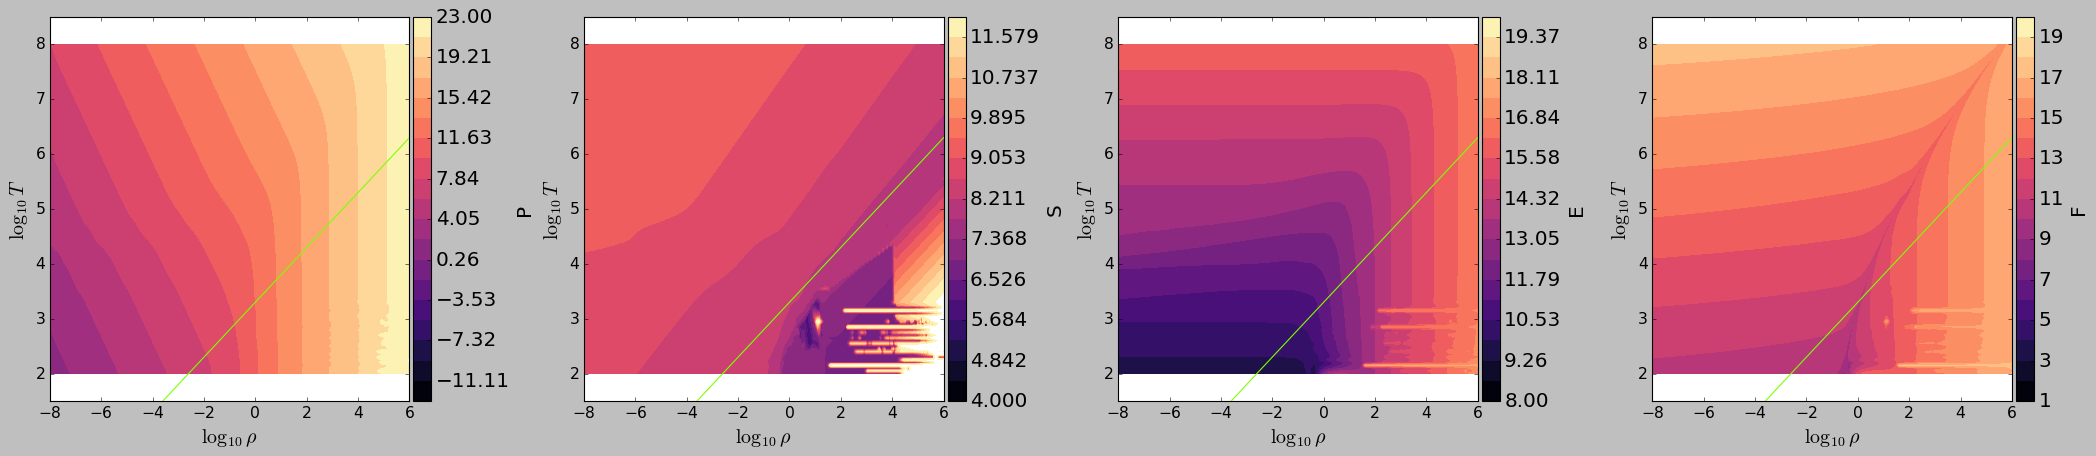

2.0
2.05
2.0999999999999996
2.1499999999999995
2.1999999999999993
2.249999999999999
2.299999999999999
2.3499999999999988
2.3999999999999986
2.4499999999999984
2.4999999999999982
2.549999999999998
2.599999999999998
2.6499999999999977
2.6999999999999975
2.7499999999999973
2.799999999999997
2.849999999999997
2.899999999999997
2.9499999999999966
2.9999999999999964
3.0499999999999963
3.099999999999996
3.149999999999996
3.1999999999999957
3.2499999999999956
3.2999999999999954
3.349999999999995
3.399999999999995
3.449999999999995
3.4999999999999947
3.5499999999999945
3.5999999999999943
3.649999999999994
3.699999999999994
3.749999999999994
3.7999999999999936
3.8499999999999934
3.8999999999999932
3.949999999999993
3.999999999999993
4.049999999999993
4.0999999999999925
4.149999999999992
4.199999999999992
4.249999999999992
4.299999999999992
4.349999999999992
4.3999999999999915
4.449999999999991
4.499999999999991
4.549999999999991
4.599999999999991
4.649999999999991
4.69999999999999
4.749999999999

/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/652309645.py:178: RuntimeWarning: invalid value encountered in log10
  self.F_log10Pgrid = np.log10(self.F_Pgrid)
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/652309645.py:179: RuntimeWarning: invalid value encountered in log10
  self.F_log10Sgrid = np.log10(self.F_Sgrid)
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/652309645.py:180: RuntimeWarning: invalid value encountered in log10
  self.F_log10Egrid = np.log10(self.F_Egrid)


2
5


/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/57721078.py:197: RuntimeWarning: invalid value encountered in log10
  control.log10Pgrid = np.log10( 10**control.log10Pgrid - sf*P_diff )
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/57721078.py:198: RuntimeWarning: invalid value encountered in log10
  control.log10Sgrid = np.log10( 10**control.log10Sgrid - sf*S_diff )
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/57721078.py:199: RuntimeWarning: invalid value encountered in log10
  control.log10Egrid = np.log10( 10**control.log10Egrid - sf*E_diff )


0.2


/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/1621059805.py:105: RuntimeWarning: invalid value encountered in log10
  mixed_log10Sgrid[i,j] = np.log10(X*S_H + Y*S_He + X*Y*this_Smix)


0
3.3403385480244956


/Users/emily/Documents/astro/giant_planets/MESA_EoS/EOSutils/EOSutils/EOSutils.py:1559: UserWarning: The following kwargs were not used by contour: 'shading'
  cs = axes[i,j].contourf(xs[i*nCol + j], ys[i*nCol + j], zs[i*nCol + j], shading='nearest', cmap=cmap[i*nCol + j], levels=np.linspace(zlims[i*nCol+j][0],zlims[i*nCol+j][1],levels[i*nCol+j]))


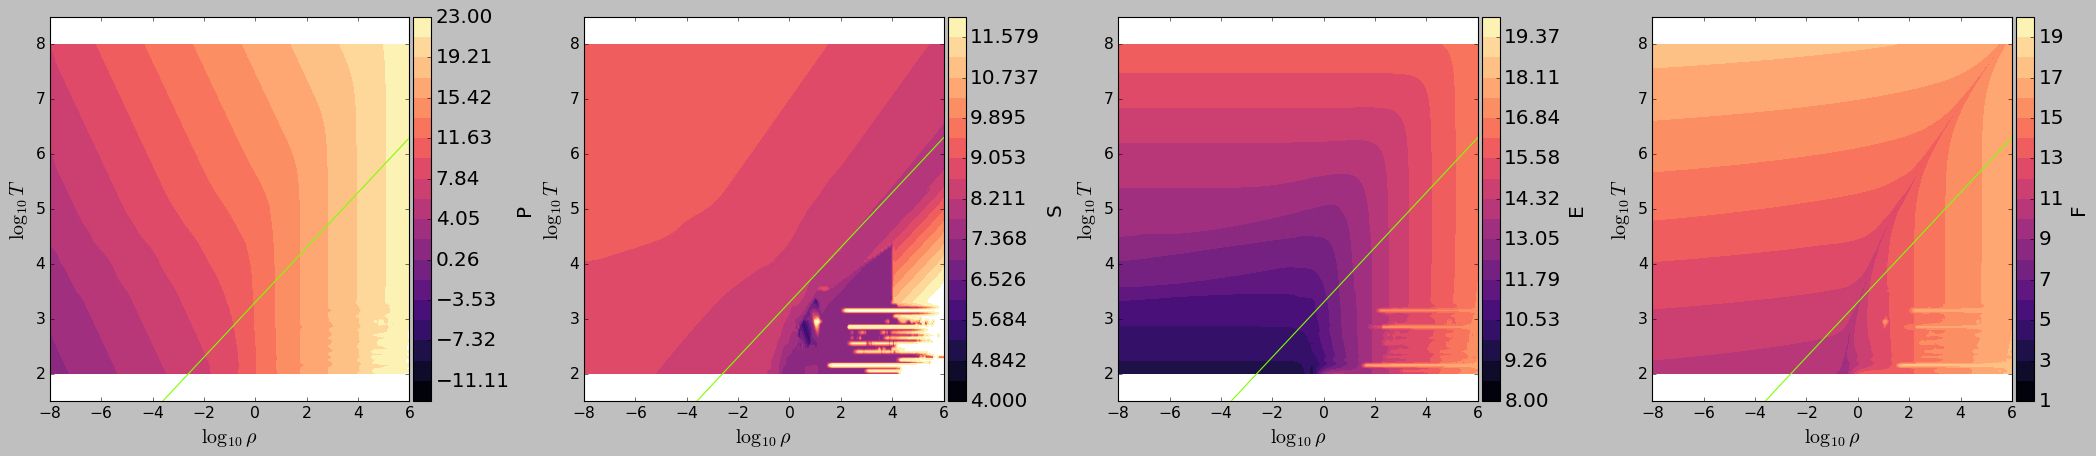

2.0
2.05
2.0999999999999996
2.1499999999999995
2.1999999999999993
2.249999999999999
2.299999999999999
2.3499999999999988
2.3999999999999986
2.4499999999999984
2.4999999999999982
2.549999999999998
2.599999999999998
2.6499999999999977
2.6999999999999975
2.7499999999999973
2.799999999999997
2.849999999999997
2.899999999999997
2.9499999999999966
2.9999999999999964
3.0499999999999963
3.099999999999996
3.149999999999996
3.1999999999999957
3.2499999999999956
3.2999999999999954
3.349999999999995
3.399999999999995
3.449999999999995
3.4999999999999947
3.5499999999999945
3.5999999999999943
3.649999999999994
3.699999999999994
3.749999999999994
3.7999999999999936
3.8499999999999934
3.8999999999999932
3.949999999999993
3.999999999999993
4.049999999999993
4.0999999999999925
4.149999999999992
4.199999999999992
4.249999999999992
4.299999999999992
4.349999999999992
4.3999999999999915
4.449999999999991
4.499999999999991
4.549999999999991
4.599999999999991
4.649999999999991
4.69999999999999
4.749999999999

/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/652309645.py:178: RuntimeWarning: invalid value encountered in log10
  self.F_log10Pgrid = np.log10(self.F_Pgrid)
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/652309645.py:179: RuntimeWarning: invalid value encountered in log10
  self.F_log10Sgrid = np.log10(self.F_Sgrid)
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/652309645.py:180: RuntimeWarning: invalid value encountered in log10
  self.F_log10Egrid = np.log10(self.F_Egrid)


2
5


/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/57721078.py:197: RuntimeWarning: invalid value encountered in log10
  control.log10Pgrid = np.log10( 10**control.log10Pgrid - sf*P_diff )
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/57721078.py:198: RuntimeWarning: invalid value encountered in log10
  control.log10Sgrid = np.log10( 10**control.log10Sgrid - sf*S_diff )
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/57721078.py:199: RuntimeWarning: invalid value encountered in log10
  control.log10Egrid = np.log10( 10**control.log10Egrid - sf*E_diff )


0.30000000000000004


/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/1621059805.py:105: RuntimeWarning: invalid value encountered in log10
  mixed_log10Sgrid[i,j] = np.log10(X*S_H + Y*S_He + X*Y*this_Smix)


0
3.2411872148513794


/Users/emily/Documents/astro/giant_planets/MESA_EoS/EOSutils/EOSutils/EOSutils.py:1559: UserWarning: The following kwargs were not used by contour: 'shading'
  cs = axes[i,j].contourf(xs[i*nCol + j], ys[i*nCol + j], zs[i*nCol + j], shading='nearest', cmap=cmap[i*nCol + j], levels=np.linspace(zlims[i*nCol+j][0],zlims[i*nCol+j][1],levels[i*nCol+j]))


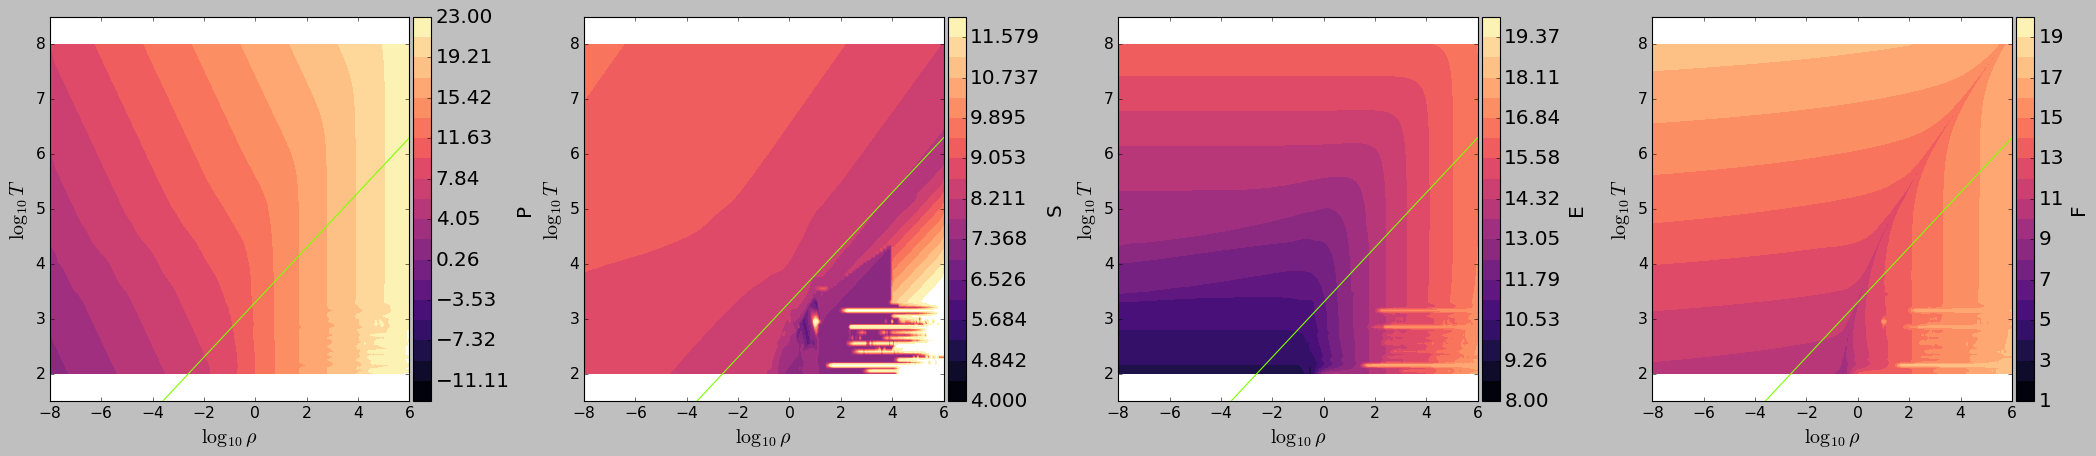

2.0
2.05
2.0999999999999996
2.1499999999999995
2.1999999999999993
2.249999999999999
2.299999999999999
2.3499999999999988
2.3999999999999986
2.4499999999999984
2.4999999999999982
2.549999999999998
2.599999999999998
2.6499999999999977
2.6999999999999975
2.7499999999999973
2.799999999999997
2.849999999999997
2.899999999999997
2.9499999999999966
2.9999999999999964
3.0499999999999963
3.099999999999996
3.149999999999996
3.1999999999999957
3.2499999999999956
3.2999999999999954
3.349999999999995
3.399999999999995
3.449999999999995
3.4999999999999947
3.5499999999999945
3.5999999999999943
3.649999999999994
3.699999999999994
3.749999999999994
3.7999999999999936
3.8499999999999934
3.8999999999999932
3.949999999999993
3.999999999999993
4.049999999999993
4.0999999999999925
4.149999999999992
4.199999999999992
4.249999999999992
4.299999999999992
4.349999999999992
4.3999999999999915
4.449999999999991
4.499999999999991
4.549999999999991
4.599999999999991
4.649999999999991
4.69999999999999
4.749999999999

/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/652309645.py:178: RuntimeWarning: invalid value encountered in log10
  self.F_log10Pgrid = np.log10(self.F_Pgrid)
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/652309645.py:179: RuntimeWarning: invalid value encountered in log10
  self.F_log10Sgrid = np.log10(self.F_Sgrid)
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/652309645.py:180: RuntimeWarning: invalid value encountered in log10
  self.F_log10Egrid = np.log10(self.F_Egrid)


2
5


/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/57721078.py:197: RuntimeWarning: invalid value encountered in log10
  control.log10Pgrid = np.log10( 10**control.log10Pgrid - sf*P_diff )
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/57721078.py:198: RuntimeWarning: invalid value encountered in log10
  control.log10Sgrid = np.log10( 10**control.log10Sgrid - sf*S_diff )
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/57721078.py:199: RuntimeWarning: invalid value encountered in log10
  control.log10Egrid = np.log10( 10**control.log10Egrid - sf*E_diff )


0.4


/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/1621059805.py:105: RuntimeWarning: invalid value encountered in log10
  mixed_log10Sgrid[i,j] = np.log10(X*S_H + Y*S_He + X*Y*this_Smix)


0
3.2450865149497985


/Users/emily/Documents/astro/giant_planets/MESA_EoS/EOSutils/EOSutils/EOSutils.py:1559: UserWarning: The following kwargs were not used by contour: 'shading'
  cs = axes[i,j].contourf(xs[i*nCol + j], ys[i*nCol + j], zs[i*nCol + j], shading='nearest', cmap=cmap[i*nCol + j], levels=np.linspace(zlims[i*nCol+j][0],zlims[i*nCol+j][1],levels[i*nCol+j]))


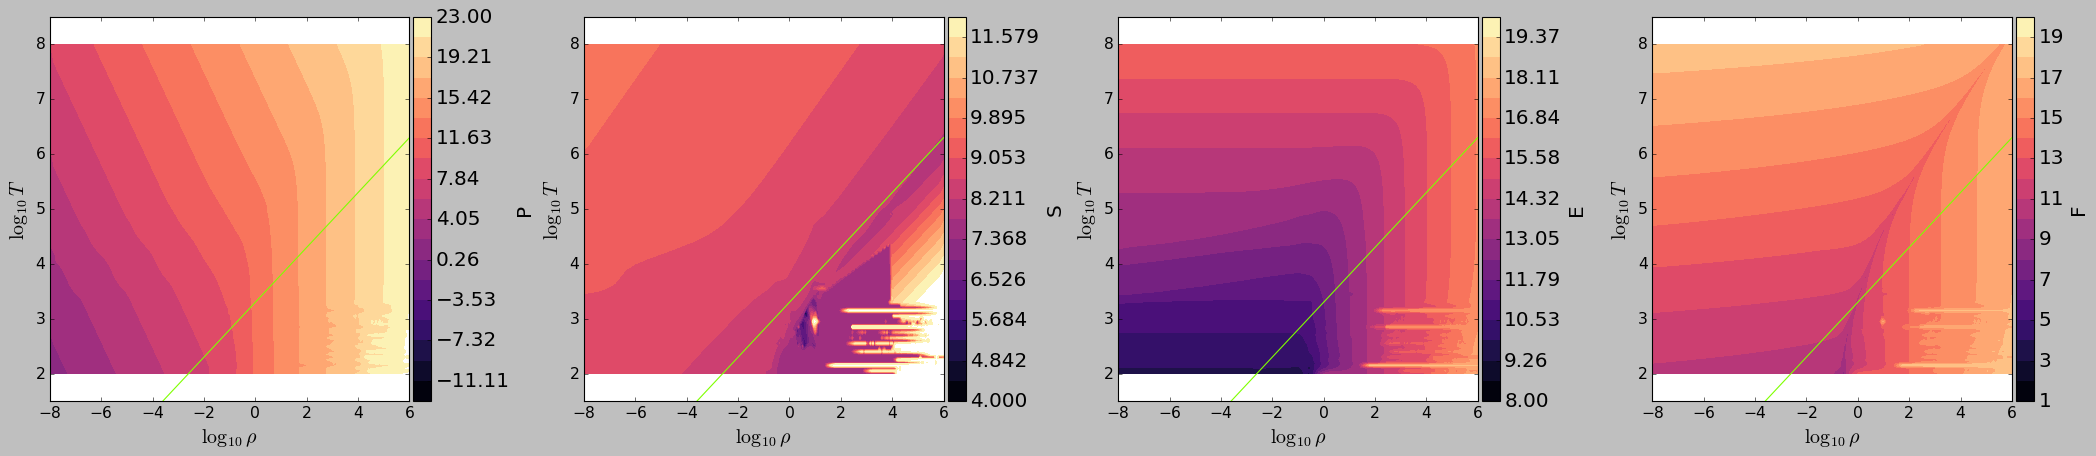

2.0
2.05
2.0999999999999996
2.1499999999999995
2.1999999999999993
2.249999999999999
2.299999999999999
2.3499999999999988
2.3999999999999986
2.4499999999999984
2.4999999999999982
2.549999999999998
2.599999999999998
2.6499999999999977
2.6999999999999975
2.7499999999999973
2.799999999999997
2.849999999999997
2.899999999999997
2.9499999999999966
2.9999999999999964
3.0499999999999963
3.099999999999996
3.149999999999996
3.1999999999999957
3.2499999999999956
3.2999999999999954
3.349999999999995
3.399999999999995
3.449999999999995
3.4999999999999947
3.5499999999999945
3.5999999999999943
3.649999999999994
3.699999999999994
3.749999999999994
3.7999999999999936
3.8499999999999934
3.8999999999999932
3.949999999999993
3.999999999999993
4.049999999999993
4.0999999999999925
4.149999999999992
4.199999999999992
4.249999999999992
4.299999999999992
4.349999999999992
4.3999999999999915
4.449999999999991
4.499999999999991
4.549999999999991
4.599999999999991
4.649999999999991
4.69999999999999
4.749999999999

/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/652309645.py:178: RuntimeWarning: invalid value encountered in log10
  self.F_log10Pgrid = np.log10(self.F_Pgrid)
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/652309645.py:179: RuntimeWarning: invalid value encountered in log10
  self.F_log10Sgrid = np.log10(self.F_Sgrid)
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/652309645.py:180: RuntimeWarning: invalid value encountered in log10
  self.F_log10Egrid = np.log10(self.F_Egrid)


2
5


/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/57721078.py:197: RuntimeWarning: invalid value encountered in log10
  control.log10Pgrid = np.log10( 10**control.log10Pgrid - sf*P_diff )
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/57721078.py:198: RuntimeWarning: invalid value encountered in log10
  control.log10Sgrid = np.log10( 10**control.log10Sgrid - sf*S_diff )
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/57721078.py:199: RuntimeWarning: invalid value encountered in log10
  control.log10Egrid = np.log10( 10**control.log10Egrid - sf*E_diff )


0.5


/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/1621059805.py:105: RuntimeWarning: invalid value encountered in log10
  mixed_log10Sgrid[i,j] = np.log10(X*S_H + Y*S_He + X*Y*this_Smix)


0
3.294210064411163


/Users/emily/Documents/astro/giant_planets/MESA_EoS/EOSutils/EOSutils/EOSutils.py:1559: UserWarning: The following kwargs were not used by contour: 'shading'
  cs = axes[i,j].contourf(xs[i*nCol + j], ys[i*nCol + j], zs[i*nCol + j], shading='nearest', cmap=cmap[i*nCol + j], levels=np.linspace(zlims[i*nCol+j][0],zlims[i*nCol+j][1],levels[i*nCol+j]))


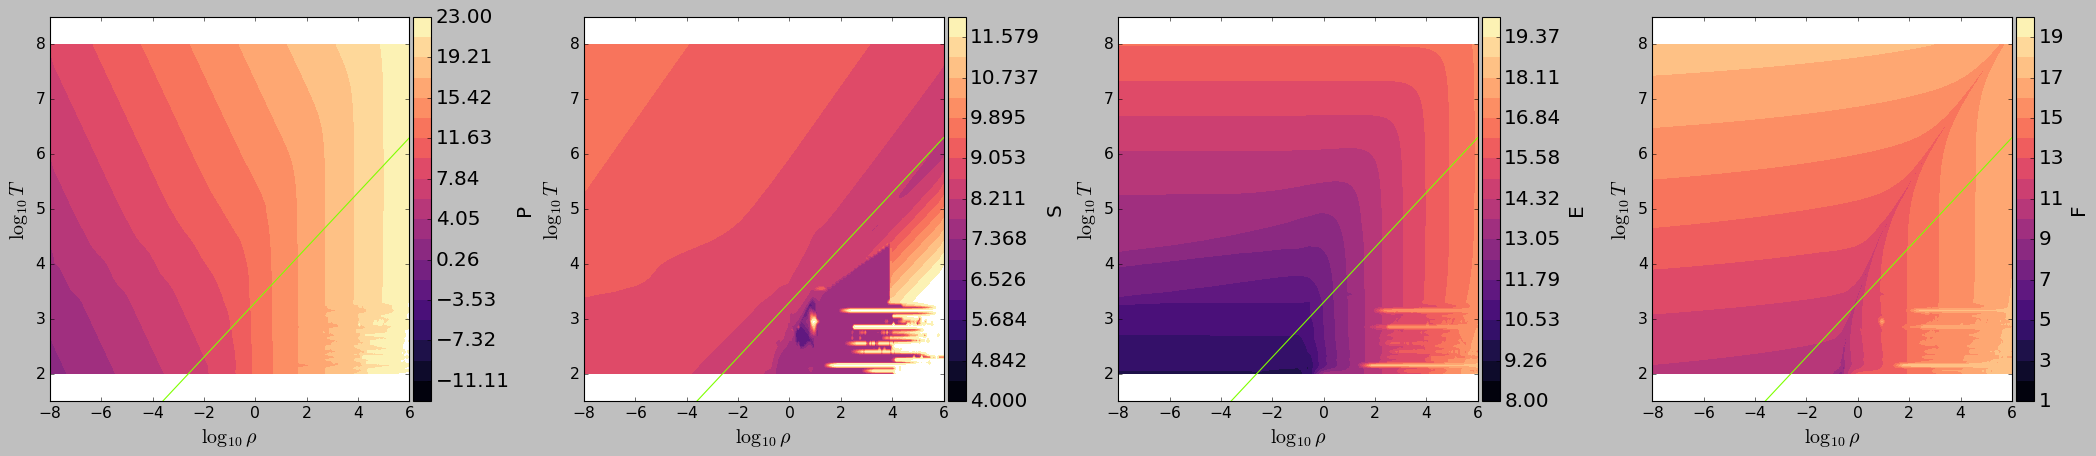

2.0
2.05
2.0999999999999996
2.1499999999999995
2.1999999999999993
2.249999999999999
2.299999999999999
2.3499999999999988
2.3999999999999986
2.4499999999999984
2.4999999999999982
2.549999999999998
2.599999999999998
2.6499999999999977
2.6999999999999975
2.7499999999999973
2.799999999999997
2.849999999999997
2.899999999999997
2.9499999999999966
2.9999999999999964
3.0499999999999963
3.099999999999996
3.149999999999996
3.1999999999999957
3.2499999999999956
3.2999999999999954
3.349999999999995
3.399999999999995
3.449999999999995
3.4999999999999947
3.5499999999999945
3.5999999999999943
3.649999999999994
3.699999999999994
3.749999999999994
3.7999999999999936
3.8499999999999934
3.8999999999999932
3.949999999999993
3.999999999999993
4.049999999999993
4.0999999999999925
4.149999999999992
4.199999999999992
4.249999999999992
4.299999999999992
4.349999999999992
4.3999999999999915
4.449999999999991
4.499999999999991
4.549999999999991
4.599999999999991
4.649999999999991
4.69999999999999
4.749999999999

/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/652309645.py:178: RuntimeWarning: invalid value encountered in log10
  self.F_log10Pgrid = np.log10(self.F_Pgrid)
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/652309645.py:179: RuntimeWarning: invalid value encountered in log10
  self.F_log10Sgrid = np.log10(self.F_Sgrid)
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/652309645.py:180: RuntimeWarning: invalid value encountered in log10
  self.F_log10Egrid = np.log10(self.F_Egrid)


2
5


/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/57721078.py:197: RuntimeWarning: invalid value encountered in log10
  control.log10Pgrid = np.log10( 10**control.log10Pgrid - sf*P_diff )
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/57721078.py:198: RuntimeWarning: invalid value encountered in log10
  control.log10Sgrid = np.log10( 10**control.log10Sgrid - sf*S_diff )
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/57721078.py:199: RuntimeWarning: invalid value encountered in log10
  control.log10Egrid = np.log10( 10**control.log10Egrid - sf*E_diff )


0.6000000000000001


/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/1621059805.py:105: RuntimeWarning: invalid value encountered in log10
  mixed_log10Sgrid[i,j] = np.log10(X*S_H + Y*S_He + X*Y*this_Smix)


0
2.848478317260742


/Users/emily/Documents/astro/giant_planets/MESA_EoS/EOSutils/EOSutils/EOSutils.py:1559: UserWarning: The following kwargs were not used by contour: 'shading'
  cs = axes[i,j].contourf(xs[i*nCol + j], ys[i*nCol + j], zs[i*nCol + j], shading='nearest', cmap=cmap[i*nCol + j], levels=np.linspace(zlims[i*nCol+j][0],zlims[i*nCol+j][1],levels[i*nCol+j]))


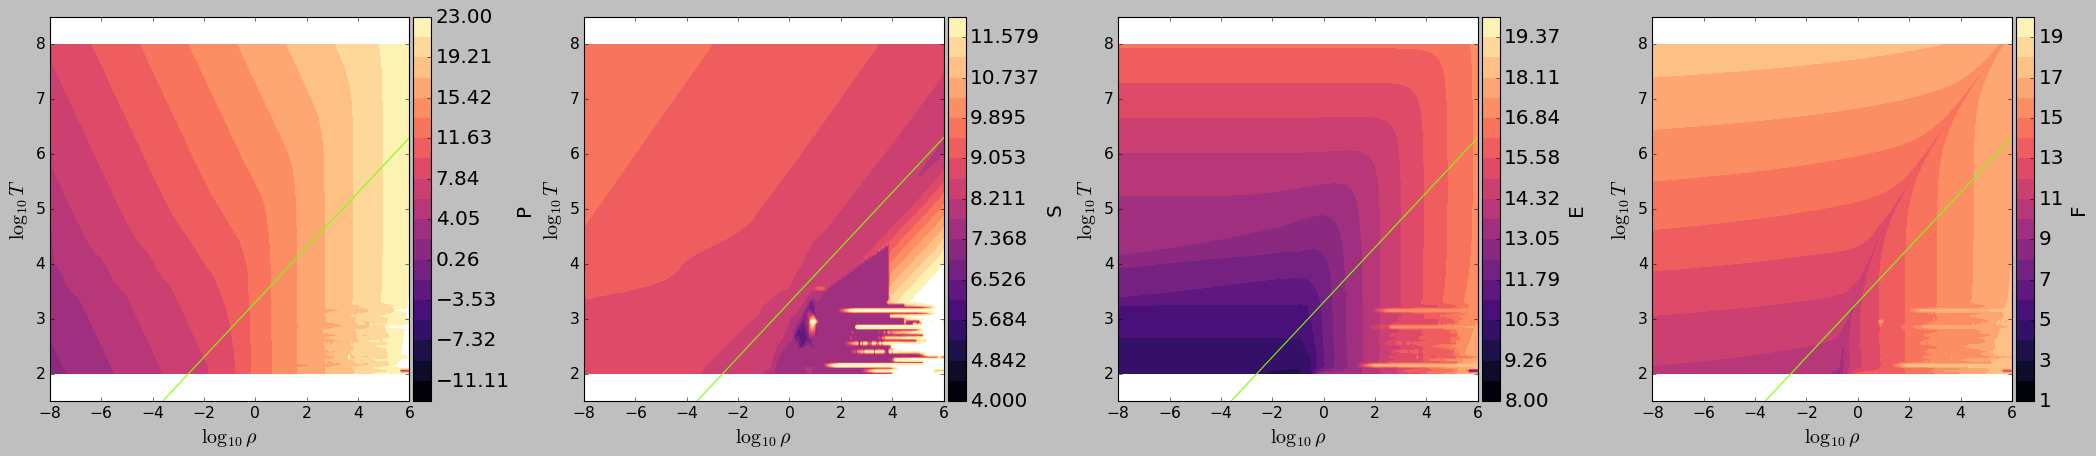

2.0
2.05
2.0999999999999996
2.1499999999999995
2.1999999999999993
2.249999999999999
2.299999999999999
2.3499999999999988
2.3999999999999986
2.4499999999999984
2.4999999999999982
2.549999999999998
2.599999999999998
2.6499999999999977
2.6999999999999975
2.7499999999999973
2.799999999999997
2.849999999999997
2.899999999999997
2.9499999999999966
2.9999999999999964
3.0499999999999963
3.099999999999996
3.149999999999996
3.1999999999999957
3.2499999999999956
3.2999999999999954
3.349999999999995
3.399999999999995
3.449999999999995
3.4999999999999947
3.5499999999999945
3.5999999999999943
3.649999999999994
3.699999999999994
3.749999999999994
3.7999999999999936
3.8499999999999934
3.8999999999999932
3.949999999999993
3.999999999999993
4.049999999999993
4.0999999999999925
4.149999999999992
4.199999999999992
4.249999999999992
4.299999999999992
4.349999999999992
4.3999999999999915
4.449999999999991
4.499999999999991
4.549999999999991
4.599999999999991
4.649999999999991
4.69999999999999
4.749999999999

/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/652309645.py:178: RuntimeWarning: invalid value encountered in log10
  self.F_log10Pgrid = np.log10(self.F_Pgrid)
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/652309645.py:179: RuntimeWarning: invalid value encountered in log10
  self.F_log10Sgrid = np.log10(self.F_Sgrid)
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/652309645.py:180: RuntimeWarning: invalid value encountered in log10
  self.F_log10Egrid = np.log10(self.F_Egrid)


2
5


/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/57721078.py:197: RuntimeWarning: invalid value encountered in log10
  control.log10Pgrid = np.log10( 10**control.log10Pgrid - sf*P_diff )
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/57721078.py:198: RuntimeWarning: invalid value encountered in log10
  control.log10Sgrid = np.log10( 10**control.log10Sgrid - sf*S_diff )
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/57721078.py:199: RuntimeWarning: invalid value encountered in log10
  control.log10Egrid = np.log10( 10**control.log10Egrid - sf*E_diff )


In [58]:
Xarr = np.arange(0.1,1.0,0.1)
#Xarr = np.atleast_1d(np.array(0.1))

print(Xarr)
Yarr = 1.-Xarr
print(Yarr)

ii, jj = np.meshgrid(np.arange(121),np.arange(441))

for i, xi in enumerate(Xarr):

    # REMOVE THIS later!
    if xi >= 0.7:
        continue
    
    print(xi)
    mixed_H_He = add_mixing_terms(H_PTtable=bln_H_PT, He_PTtable=cms_He_PT, Z_PTtable=None, X=Xarr[i], Y=1.-Xarr[i], HG23path="/Users/emily/Documents/astro/giant_planets/MESA_EoS/HG23_Vmix_Smix_Umix.csv")
    mixed_H_He.log10Sgrid = meos.fill_in_nans(mixed_H_He.log10Sgrid, mixed_H_He)
    '''
    meos.contourf_subplots_with_colorbars(nRow=1, nCol=4, 
                                xs=mixed_H_He.log10rhogrid,
                                ys=mixed_H_He.log10Tgrid,
                                zs=[mixed_H_He.log10Pgrid,mixed_H_He.log10Sgrid,mixed_H_He.log10Egrid,np.log10(np.abs(10**mixed_H_He.log10Egrid - ((10**mixed_H_He.log10Tgrid) * (10**mixed_H_He.log10Sgrid))))],
                                xlims=(-8,6),
                                ylims=(1.5,8.5),
                                zlims=[(-13,23),(4,12),(8,20),(1,20)],
                                levels=20,
                                xlabels=r'$\log_{10}\rho$',
                                ylabels=r'$\log_{10}T$',
                                zlabels=['P','S','E','F'],
                                cmap='magma', vlines=None, hlines=None, otherlines_x=[unphys_x], otherlines_y=[unphys_y], 
                                species='H', plot_interpolation_lines=False, savename=None)
               
    '''
    n_nans_left = len(mixed_H_He.log10Sgrid[~np.isfinite(mixed_H_He.log10Sgrid)])
    print(n_nans_left)
    i_arr = ii[~np.isfinite(mixed_H_He.log10Sgrid)]
    j_arr = jj[~np.isfinite(mixed_H_He.log10Sgrid)]
    for k in range(n_nans_left):
        i_ = i_arr[k]
        j_ = j_arr[k]

        mixed_H_He.log10Sgrid[j_,i_] = 0.5 * (mixed_H_He.log10Sgrid[j_-1,i_] + mixed_H_He.log10Sgrid[j_+1,i_])
    

    start = time.time()
    if xi > 0.5:
        mixed_H_He_rhoT = reinterpolate_mixed_table_to_rhoT(mixed_H_He,reference_Pgrid=bln_H.log10Pgrid, X=Xarr[i], Y=1.-Xarr[i])
    else:
        mixed_H_He_rhoT = reinterpolate_mixed_table_to_rhoT(mixed_H_He,reference_Pgrid=cms_He.log10Pgrid, X=Xarr[i], Y=1.-Xarr[i])
    end = time.time()
    print((end-start)/60.)

    meos.contourf_subplots_with_colorbars(nRow=1, nCol=4, 
                                xs=mixed_H_He_rhoT.log10rhogrid,
                                ys=mixed_H_He_rhoT.log10Tgrid,
                                zs=[mixed_H_He_rhoT.log10Pgrid,mixed_H_He_rhoT.log10Sgrid,mixed_H_He_rhoT.log10Egrid,np.log10(np.abs(10**mixed_H_He_rhoT.log10Egrid - ((10**mixed_H_He_rhoT.log10Tgrid) * (10**mixed_H_He_rhoT.log10Sgrid))))],
                                xlims=(-8,6),
                                ylims=(1.5,8.5),
                                zlims=[(-13,23),(4,12),(8,20),(1,20)],
                                levels=20,
                                xlabels=r'$\log_{10}\rho$',
                                ylabels=r'$\log_{10}T$',
                                zlabels=['P','S','E','F'],
                                cmap='magma', vlines=None, hlines=None, otherlines_x=[unphys_x], otherlines_y=[unphys_y], 
                                species='H', plot_interpolation_lines=False, savename=None)
           

    mixed_H_He_rhoT.compute_atomic_number()
    mixed_H_He_rhoT.compute_partials()

    MESA_cols_6to16(mixed_H_He_rhoT, X=Xarr[i],Y=1.-Xarr[i],calc_eta=True)

    mixed_H_He_rhoT.dS_drho_T = meos.fill_in_nans(mixed_H_He_rhoT.dS_drho_T,mixed_H_He_rhoT)
    mixed_H_He_rhoT.chiRho = meos.fill_in_nans(mixed_H_He_rhoT.chiRho,mixed_H_He_rhoT)
    
    mixed_H_He_rhoT_QT = change_table_coordinates(mixed_H_He_rhoT,extrapolation_row_idxs=None,extrapolation_col_idxs=None)
    
    '''
    meos.contourf_sublots_with_colorbars(nRow=1, nCol=6, 
                                    xs=mixed_H_He_rhoT_QT.log10Qgrid_QT,
                                    ys=mixed_H_He_rhoT_QT.log10Tgrid_QT,
                                    zs=[mixed_H_He_rhoT_QT.dE_drho_T_QT,mixed_H_He_rhoT_QT.dS_drho_T_QT,mixed_H_He_rhoT_QT.chiRho_QT,mixed_H_He_rhoT_QT.gamma1_QT,mixed_H_He_rhoT_QT.gamma3_QT,mixed_H_He_rhoT_QT.grad_ad_QT],
                                    xlims=(-12,5.4),
                                    ylims=(2,8),
                                    zlims=None,
                                    levels=20,
                                    xlabels=r'$\log_{10}Q$',
                                    ylabels=r'$\log_{10}T$',
                                    zlabels=['dE_dRho','dS_dRho','chiRho','gamma1','gamma3','grad_ad'],
                                    cmap='magma', vlines=None, hlines=None, otherlines_x=[x], otherlines_y=[y1,y2], 
                                    species='H', plot_interpolation_lines=False, savename=None)
    '''
    #print(mixed_H_He_rhoT_QT.log10Qgrid_QT[~np.isfinite(mixed_H_He_rhoT_QT.chiRho_QT)])
    #print(mixed_H_He_rhoT_QT.log10Tgrid_QT[~np.isfinite(mixed_H_He_rhoT_QT.chiRho_QT)])
    
    #write_MESA_table_QT(mixed_H_He_rhoT_QT, './my_MESAformat_tables/mesa-planetblend_00z{0}0x.data'.format(str(np.round(xi,1))[-1]),version=1, X=xi, Z=0.0)
    write_MESA_table_QT(mixed_H_He_rhoT_QT, './meos_MESAformat_CMS19+HG23+rock+water/mesa-planetblend_00z{0}0x.data'.format(str(np.round(xi,1))[-1]),version=1, X=xi, Z=0.0)
    
    for s_i, s in enumerate(smoothing_arr):
        print(s)
        TC = copy.deepcopy(mixed_H_He_rhoT)
    
        TC.compute_F_table(F_smoothing_kernel=s, F_nan_fill_value='reflect')
        '''
        meos.contourf_subplots_with_colorbars(nRow=1, nCol=4, 
                                xs=TC.log10rhogrid,
                                ys=TC.log10Tgrid,
                                zs=[TC.log10Pgrid,TC.log10Sgrid,TC.log10Egrid,np.log10(np.abs(10**TC.log10Egrid - ((10**TC.log10Tgrid) * (10**TC.log10Sgrid))))],
                                xlims=(-8,6),
                                ylims=(1.5,8.5),
                                zlims=[(1,23),(8,12),(8,20),(1,20)],
                                levels=20,
                                xlabels=r'$\log_{10}Q$',
                                ylabels=r'$\log_{10}T$',
                                zlabels=['P','S','E','F'],
                                cmap='magma', vlines=None, hlines=None, otherlines_x=None, otherlines_y=None, 
                                species='H', plot_interpolation_lines=False, savename=None)
        '''
    
        # replace existing PSE grids with F-based versions
        TC.log10Pgrid = meos.fill_in_nans(TC.F_log10Pgrid,TC)
        TC.log10Sgrid = meos.fill_in_nans(TC.F_log10Sgrid,TC)
        TC.log10Egrid = meos.fill_in_nans(TC.F_log10Egrid,TC)

        TC.log10Pgrid = TC.F_log10Pgrid
        TC.log10Sgrid = TC.F_log10Sgrid
        TC.log10Egrid = TC.F_log10Egrid
    
        TC.log10Ugrid = TC.log10Egrid

        TC.compute_partials()
        '''
        meos.contourf_subplots_with_colorbars(nRow=1, nCol=4, 
                                xs=TC.log10rhogrid,
                                ys=TC.log10Tgrid,
                                zs=[TC.log10Pgrid,TC.log10Sgrid,TC.log10Egrid,np.log10(np.abs(10**TC.log10Egrid - ((10**TC.log10Tgrid) * (10**TC.log10Sgrid))))],
                                xlims=(-8,6),
                                ylims=(1.5,8.5),
                                zlims=[(1,23),(8,12),(8,20),(1,20)],
                                levels=20,
                                xlabels=r'$\log_{10}Q$',
                                ylabels=r'$\log_{10}T$',
                                zlabels=['P','S','E','F'],
                                cmap='magma', vlines=None, hlines=None, otherlines_x=None, otherlines_y=None, 
                                species='H', plot_interpolation_lines=False, savename=None)
        '''
    

    
        MESA_cols_6to16(TC,X=Xarr[i],Y=1.-Xarr[i],calc_eta=False)

        TC.dS_drho_T = meos.fill_in_nans(TC.dS_drho_T,TC)
        TC.chiRho = meos.fill_in_nans(TC.chiRho,TC)
        TC.dE_drho_T = meos.fill_in_nans(TC.dE_drho_T,TC)
        TC.Cp = meos.fill_in_nans(TC.Cp,TC)
        
       
        TC.log10Qgrid = TC.log10rhogrid - 2.*TC.log10Tgrid + 12
        TC_QT = change_table_coordinates(TC,extrapolation_row_idxs=None,extrapolation_col_idxs=None)

        #print(TC_QT.dE_drho_T_QT)
        '''
        meos.contourf_sublots_with_colorbars(nRow=1, nCol=2, 
                                    xs=TC_QT.log10Qgrid_QT,
                                    ys=TC_QT.log10Tgrid_QT,
                                    zs=[TC_QT.dE_drho_T_QT,TC_QT.Cp_QT],
                                    xlims=(-12,5.4),
                                    ylims=(2,8),
                                    zlims=None,
                                    levels=20,
                                    xlabels=r'$\log_{10}Q$',
                                    ylabels=r'$\log_{10}T$',
                                    zlabels=['dE_drho','Cp'],
                                    cmap='magma', vlines=None, hlines=[7.2], otherlines_x=[x], otherlines_y=[y1,y2], 
                                    species='H', plot_interpolation_lines=False, savename=None)
        '''
        #write_MESA_table_QT(TC_QT, './my_MESAformat_tables/mesa-planetblend-TC_s={0}_00z{1}0x.data'.format(s,str(np.round(xi,1))[-1]),version=1, X=xi, Z=0.0)
        write_MESA_table_QT(TC_QT, './meos_MESAformat_CMS19+HG23+rock+water/mesa-planetblend-TC_s={0}_00z{1}0x.data'.format(s,str(np.round(xi,1))[-1]),version=1, X=xi, Z=0.0)
    
    for s_i, s in enumerate(smoothing_arr):
        for sf_i, sf in enumerate(scaling_fac_arr):
            control = copy.deepcopy(mixed_H_He_rhoT)
        
            control.compute_F_table(F_smoothing_kernel=s, F_nan_fill_value='reflect')

            control.F_Pgrid = meos.fill_in_nans(control.F_Pgrid,control)
            control.F_Sgrid = meos.fill_in_nans(control.F_Sgrid,control)
            control.F_Egrid = meos.fill_in_nans(control.F_Egrid,control)
    
        
            # replace existing PSE grids with F-based versions
            P_diff = control.F_Pgrid - 10**control.log10Pgrid
            S_diff = control.F_Sgrid - 10**control.log10Sgrid
            E_diff = control.F_Egrid - 10**control.log10Egrid
    
            control.log10Pgrid = np.log10( 10**control.log10Pgrid - sf*P_diff )
            control.log10Sgrid = np.log10( 10**control.log10Sgrid - sf*S_diff )
            control.log10Egrid = np.log10( 10**control.log10Egrid - sf*E_diff )

            control.log10Pgrid = meos.fill_in_nans(control.log10Pgrid,control)
            control.log10Sgrid = meos.fill_in_nans(control.log10Sgrid,control)
            control.log10Egrid = meos.fill_in_nans(control.log10Egrid,control)
    
        
            control.log10Ugrid = control.log10Egrid

            control.compute_partials()
        
            MESA_cols_6to16(control,X=Xarr[i],Y=1.-Xarr[i],calc_eta=False)
            
            control.log10Qgrid = control.log10rhogrid - 2.*control.log10Tgrid + 12
            control_QT = change_table_coordinates(control,extrapolation_row_idxs=None,extrapolation_col_idxs=None)

            '''
            meos.contourf_sublots_with_colorbars(nRow=1, nCol=2, 
                                        xs=control_QT.log10Qgrid_QT,
                                        ys=control_QT.log10Tgrid_QT,
                                        zs=[control_QT.dE_drho_T_QT,control_QT.Cp_QT],
                                        xlims=(-12,5.4),
                                        ylims=(2,8),
                                        zlims=None,
                                        levels=20,
                                        xlabels=r'$\log_{10}Q$',
                                        ylabels=r'$\log_{10}T$',
                                        zlabels=['dE_drho','Cp'],
                                        cmap='magma', vlines=None, hlines=None, otherlines_x=[x], otherlines_y=[y1,y2], 
                                        species='H', plot_interpolation_lines=False, savename=None)
            '''
            
            #write_MESA_table_QT(control_QT, './my_MESAformat_tables/mesa-planetblend-control_s={0}_sf={1}_00z{2}0x.data'.format(s,sf,str(np.round(xi,1))[-1]),version=1, X=xi, Z=0.0)
            write_MESA_table_QT(control_QT, './meos_MESAformat_CMS19+HG23+rock+water/mesa-planetblend-control_s={0}_sf={1}_00z{2}0x.data'.format(s,sf,str(np.round(xi,1))[-1]),version=1, X=xi, Z=0.0)
    

In [29]:
ls ./my_Ztables

blended_h2o.pkl   blended_iron.pkl  blended_rock.pkl


# pure H2O table

In [30]:
infile = open('./my_Ztables/blended_h2o.pkl','rb')
h2o = pickle.load(infile)
infile.close()

h2o.log10Egrid = h2o.log10Ugrid


h2o.compute_partials(species='Z')


In [31]:
MESA_cols_6to16(h2o,X=0,Y=0,mu_Z=18.015,calc_eta=True)

2.0
2.05
2.0999999999999996
2.1499999999999995
2.1999999999999993
2.249999999999999
2.299999999999999
2.3499999999999988
2.3999999999999986
2.4499999999999984
2.4999999999999982
2.549999999999998
2.599999999999998
2.6499999999999977
2.6999999999999975
2.7499999999999973
2.799999999999997
2.849999999999997
2.899999999999997
2.9499999999999966
2.9999999999999964
3.0499999999999963
3.099999999999996
3.149999999999996
3.1999999999999957
3.2499999999999956
3.2999999999999954
3.349999999999995
3.399999999999995
3.449999999999995
3.4999999999999947
3.5499999999999945
3.5999999999999943
3.649999999999994
3.699999999999994
3.749999999999994
3.7999999999999936
3.8499999999999934
3.8999999999999932
3.949999999999993
3.999999999999993
4.049999999999993
4.0999999999999925
4.149999999999992
4.199999999999992
4.249999999999992
4.299999999999992
4.349999999999992
4.3999999999999915
4.449999999999991
4.499999999999991
4.549999999999991
4.599999999999991
4.649999999999991
4.69999999999999
4.749999999999

In [32]:
h2o.log10Qgrid = h2o.log10rhogrid - 2.*h2o.log10Tgrid + 12

h2o_QT = change_table_coordinates(h2o,extrapolation_row_idxs=None)

'''
print(h2o_QT.log10Tgrid_QT[~np.isfinite(h2o_QT.Cv_QT)])
print(h2o_QT.log10Qgrid_QT[~np.isfinite(h2o_QT.Cv_QT)])
print("")
print(h2o_QT.log10Tgrid_QT[~np.isfinite(h2o_QT.dS_dT_rho_QT)])
print(h2o_QT.log10Qgrid_QT[~np.isfinite(h2o_QT.dS_dT_rho_QT)])
'''
'''
meos.contourf_sublots_with_colorbars(nRow=1, nCol=2, 
                                xs=cms_He_QT.log10Qgrid_QT,
                                ys=cms_He_QT.log10Tgrid_QT,
                                zs=[cms_He_QT.Cv_QT,cms_He_QT.dS_dT_rho_QT],
                                xlims=(-12,5.4),
                                ylims=(2,8),
                                zlims=None,
                                levels=20,
                                xlabels=r'$\log_{10}Q$',
                                ylabels=r'$\log_{10}T$',
                                zlabels=['Cv','dS_dT'],
                                cmap='magma', vlines=None, hlines=None, otherlines_x=[x], otherlines_y=[y1,y2], 
                                species='Z', plot_interpolation_lines=False, savename=None)
'''

#write_MESA_table_QT(h2o_QT, './my_MESAformat_tables/mesa-h2o_100z00x.data',version=1, X=0.0, Z=1.0)
write_MESA_table_QT(h2o_QT, './meos_MESAformat_CMS19+HG23+rock+water/mesa-h2o_100z00x.data',version=1, X=0.0, Z=1.0)

<>:12: SyntaxWarning: invalid escape sequence '\l'
<>:12: SyntaxWarning: invalid escape sequence '\l'
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/2728589785.py:12: SyntaxWarning: invalid escape sequence '\l'
  '''


# pure rock table

In [33]:
infile = open('./my_Ztables/blended_rock.pkl','rb')
rock = pickle.load(infile)
infile.close()
rock.log10Egrid = rock.log10Ugrid


rock.compute_partials(species='Z')

In [34]:
#MESA_cols_6to16(rock,X=0,Y=0,mu_Z=0.5*(140.689+216.546))
# really it's forsterite in the planet-relevant domain:
MESA_cols_6to16(rock,X=0,Y=0,mu_Z=140.689,calc_eta=True)

2.0
2.05
2.0999999999999996
2.1499999999999995
2.1999999999999993
2.249999999999999
2.299999999999999
2.3499999999999988
2.3999999999999986
2.4499999999999984
2.4999999999999982
2.549999999999998
2.599999999999998
2.6499999999999977
2.6999999999999975
2.7499999999999973
2.799999999999997
2.849999999999997
2.899999999999997
2.9499999999999966
2.9999999999999964
3.0499999999999963
3.099999999999996
3.149999999999996
3.1999999999999957
3.2499999999999956
3.2999999999999954
3.349999999999995
3.399999999999995
3.449999999999995
3.4999999999999947
3.5499999999999945
3.5999999999999943
3.649999999999994
3.699999999999994
3.749999999999994
3.7999999999999936
3.8499999999999934
3.8999999999999932
3.949999999999993
3.999999999999993
4.049999999999993
4.0999999999999925
4.149999999999992
4.199999999999992
4.249999999999992
4.299999999999992
4.349999999999992
4.3999999999999915
4.449999999999991
4.499999999999991
4.549999999999991
4.599999999999991
4.649999999999991
4.69999999999999
4.749999999999

In [35]:
rock.log10Qgrid = rock.log10rhogrid - 2.*rock.log10Tgrid + 12

rock_QT = change_table_coordinates(rock,extrapolation_row_idxs=None)

print(rock_QT.log10Tgrid_QT[~np.isfinite(rock_QT.chiRho_QT)])
print(rock_QT.log10Qgrid_QT[~np.isfinite(rock_QT.chiRho_QT)])

#write_MESA_table_QT(rock_QT, './my_MESAformat_tables/mesa-rock_100z00x.data',version=1, X=0.0, Z=1.0)
write_MESA_table_QT(rock_QT, './meos_MESAformat_CMS19+HG23+rock+water/mesa-rock_100z00x.data',version=1, X=0.0, Z=1.0)

[]
[]


# iron

In [ ]:
infile = open('./my_Ztables/blended_iron.pkl','rb')
iron = pickle.load(infile)
infile.close()

iron.log10Egrid = iron.log10Ugrid


iron.compute_partials(species='Z')

In [ ]:
MESA_cols_6to16(iron,X=0,Y=0,mu_Z=55.845,calc_eta=True)

In [ ]:
iron.log10Qgrid = iron.log10rhogrid - 2.*iron.log10Tgrid + 12

iron_QT = change_table_coordinates(iron,extrapolation_row_idxs=None)

print(iron_QT.log10Tgrid_QT[~np.isfinite(iron_QT.chiRho_QT)])
print(iron_QT.log10Qgrid_QT[~np.isfinite(iron_QT.chiRho_QT)])

#write_MESA_table_QT(iron_QT, './my_MESAformat_tables/mesa-iron_100z00x.data',version=1, X=0.0, Z=1.0)
write_MESA_table_QT(iron_QT, './meos_MESAformat_CMS19+HG23+rock+water/mesa-iron_100z00x.data',version=1, X=0.0, Z=1.0)

# 50-50 water/rock

In [36]:
def blend_z1_z2(z1table, z2table, z1frac = 0.5):

    Z = 1.
    z2frac = Z - z1frac

    shared_log10Tgrid = z1table.log10Tgrid
    shared_log10Pgrid = z1table.log10Pgrid

    mixed_table = meos.simple_table()
    mixed_table.X = 0
    mixed_table.Y = 0
    mixed_table.log10Tgrid = shared_log10Tgrid
    mixed_table.log10Pgrid = shared_log10Pgrid

    mixed_log10rhogrid = np.zeros_like(shared_log10Tgrid)
    mixed_log10Sgrid = np.zeros_like(shared_log10Tgrid)
    mixed_log10Egrid = np.zeros_like(shared_log10Tgrid)

    Tarr = np.arange(2.,8.04,0.05)
    rhoarr = np.arange(-8.,6.04,0.05)

    for i, rho in enumerate(rhoarr):
        for j, T in enumerate(Tarr):
            
            rho_z1= 10**z1table.log10rhogrid[i,j]
            rho_z2 = 10**z2table.log10rhogrid[i,j]

            S_z1 = 10**z1table.log10Sgrid[i,j]
            S_z2 = 10**z2table.log10Sgrid[i,j]

            U_z1 = 10**z1table.log10Egrid[i,j]
            U_z2 = 10**z2table.log10Egrid[i,j]

            mixed_log10rhogrid[i,j] = np.log10(1./((z1frac/rho_z1) + (z2frac/rho_z2)))
            mixed_log10Sgrid[i,j] = np.log10(z1frac*S_z1 + z2frac*S_z2)
            mixed_log10Egrid[i,j] = np.log10(z1frac*U_z1 + z2frac*U_z2)
    
    
    mixed_table.log10rhogrid = mixed_log10rhogrid
    mixed_table.log10Sgrid = mixed_log10Sgrid
    mixed_table.log10Egrid = mixed_log10Egrid
    
    return mixed_table


In [37]:
infile = open('./my_Ztables/blended_h2o.pkl','rb')
h2o_toblend = pickle.load(infile)
infile.close()
h2o_toblend.log10Egrid = h2o_toblend.log10Ugrid

In [38]:
infile = open('./my_Ztables/blended_rock.pkl','rb')
rock_toblend = pickle.load(infile)
infile.close()
rock_toblend.log10Egrid = rock_toblend.log10Ugrid

In [39]:
rock_water = blend_z1_z2(z1table=h2o_toblend, z2table=rock_toblend, z1frac = 0.5)

-12.964305130928668
22.686905294131606


/Users/emily/Documents/astro/giant_planets/MESA_EoS/EOSutils/EOSutils/EOSutils.py:1559: UserWarning: The following kwargs were not used by contour: 'shading'
  cs = axes[i,j].contourf(xs[i*nCol + j], ys[i*nCol + j], zs[i*nCol + j], shading='nearest', cmap=cmap[i*nCol + j], levels=np.linspace(zlims[i*nCol+j][0],zlims[i*nCol+j][1],levels[i*nCol+j]))


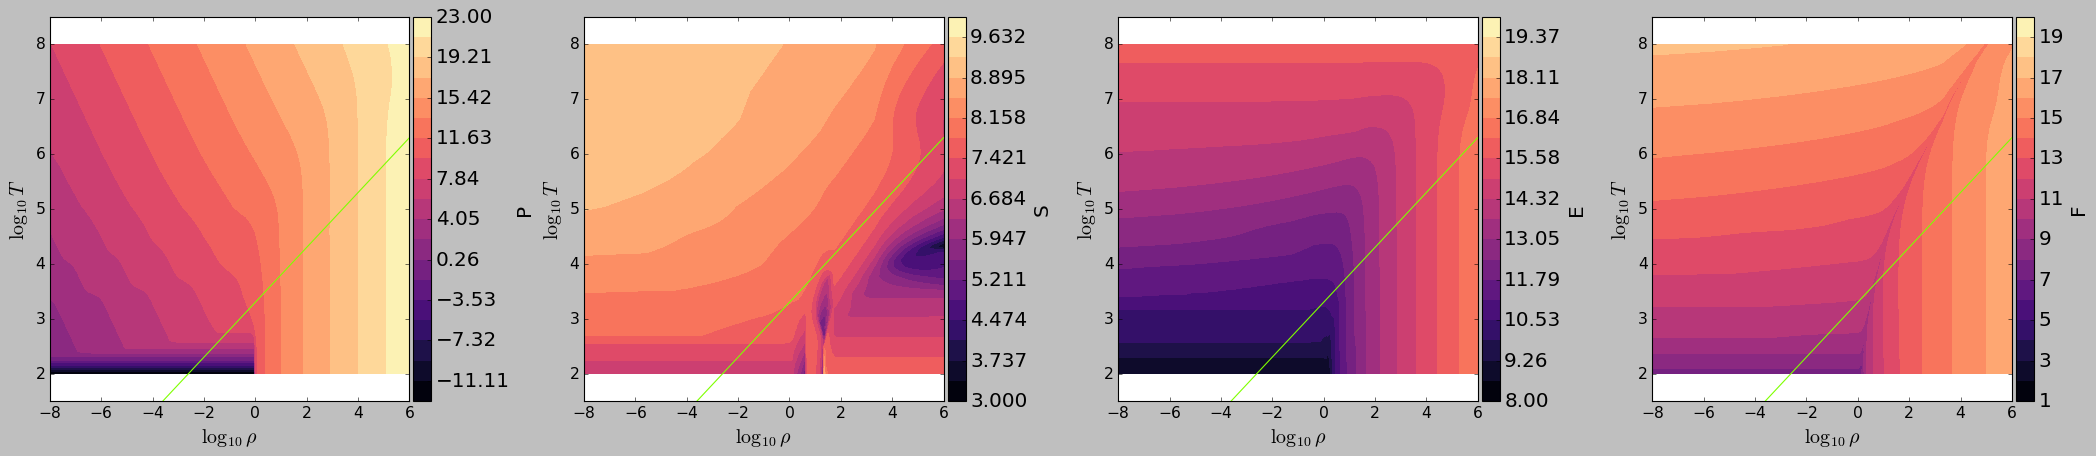

In [40]:
print(np.min(rock_water.log10Pgrid))
print(np.max(rock_water.log10Pgrid))

meos.contourf_subplots_with_colorbars(nRow=1, nCol=4, 
                                xs=rock_water.log10rhogrid,
                                ys=rock_water.log10Tgrid,
                                zs=[rock_water.log10Pgrid,rock_water.log10Sgrid,rock_water.log10Egrid,np.log10(np.abs(10**rock_water.log10Egrid - ((10**rock_water.log10Tgrid) * (10**rock_water.log10Sgrid))))],
                                xlims=(-8,6),
                                ylims=(1.5,8.5),
                                zlims=[(-13,23),(3,10),(8,20),(1,20)],
                                levels=20,
                                xlabels=r'$\log_{10}\rho$',
                                ylabels=r'$\log_{10}T$',
                                zlabels=['P','S','E','F'],
                                cmap='magma', vlines=None, hlines=None, otherlines_x=[unphys_x], otherlines_y=[unphys_y], 
                                species='H', plot_interpolation_lines=False, savename=None)


In [41]:
rock_water.compute_partials(species='Z')

In [42]:
#MESA_cols_6to16(rock_water,X=0,Y=0,mu_Z=0.5*(18.015 + 0.5*(140.689+216.546)))
# really it's forsterite in the planetary regime
MESA_cols_6to16(rock_water,X=0,Y=0,mu_Z=0.5*(18.015 + 140.689),calc_eta=True)

2.0
2.05
2.0999999999999996
2.1499999999999995
2.1999999999999993
2.249999999999999
2.299999999999999
2.3499999999999988
2.3999999999999986
2.4499999999999984
2.4999999999999982
2.549999999999998
2.599999999999998
2.6499999999999977
2.6999999999999975
2.7499999999999973
2.799999999999997
2.849999999999997
2.899999999999997
2.9499999999999966
2.9999999999999964
3.0499999999999963
3.099999999999996
3.149999999999996
3.1999999999999957
3.2499999999999956
3.2999999999999954
3.349999999999995
3.399999999999995
3.449999999999995
3.4999999999999947
3.5499999999999945
3.5999999999999943
3.649999999999994
3.699999999999994
3.749999999999994
3.7999999999999936
3.8499999999999934
3.8999999999999932
3.949999999999993
3.999999999999993
4.049999999999993
4.0999999999999925
4.149999999999992
4.199999999999992
4.249999999999992
4.299999999999992
4.349999999999992
4.3999999999999915
4.449999999999991
4.499999999999991
4.549999999999991
4.599999999999991
4.649999999999991
4.69999999999999
4.749999999999

In [43]:
rock_water.log10Qgrid = rock_water.log10rhogrid - 2.*rock_water.log10Tgrid + 12

rock_water_QT = change_table_coordinates(rock_water,extrapolation_row_idxs=None)

print(rock_water_QT.log10Tgrid_QT[~np.isfinite(rock_water_QT.Cv_QT)])
print(rock_water_QT.log10Qgrid_QT[~np.isfinite(rock_water_QT.Cv_QT)])

#write_MESA_table_QT(rock_water_QT, './my_MESAformat_tables/mesa-planetblend_100z00x.data',version=1, X=0.0, Z=1.0)
write_MESA_table_QT(rock_water_QT, './meos_MESAformat_CMS19+HG23+rock+water/mesa-planetblend_100z00x.data',version=1, X=0.0, Z=1.0)

[]
[]


<>:53: SyntaxWarning: invalid escape sequence '\l'
<>:53: SyntaxWarning: invalid escape sequence '\l'
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/472789949.py:53: SyntaxWarning: invalid escape sequence '\l'
  '''


1


/Users/emily/Documents/astro/giant_planets/MESA_EoS/EOSutils/EOSutils/EOSutils.py:506: RuntimeWarning: divide by zero encountered in log10
  self.F_log10Pgrid = np.log10(self.F_Pgrid)
/Users/emily/Documents/astro/giant_planets/MESA_EoS/EOSutils/EOSutils/EOSutils.py:506: RuntimeWarning: invalid value encountered in log10
  self.F_log10Pgrid = np.log10(self.F_Pgrid)
/Users/emily/Documents/astro/giant_planets/MESA_EoS/EOSutils/EOSutils/EOSutils.py:507: RuntimeWarning: invalid value encountered in log10
  self.F_log10Sgrid = np.log10(self.F_Sgrid)
/Users/emily/Documents/astro/giant_planets/MESA_EoS/EOSutils/EOSutils/EOSutils.py:508: RuntimeWarning: invalid value encountered in log10
  self.F_log10Egrid = np.log10(self.F_Egrid)


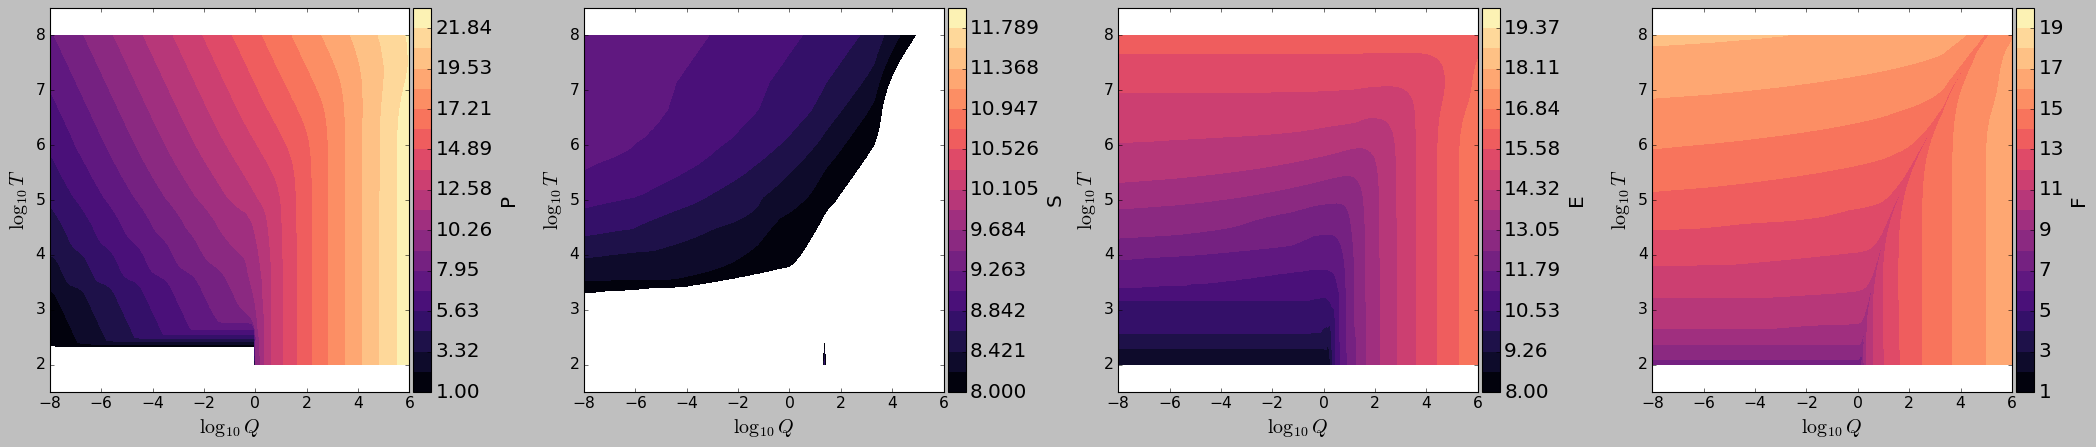

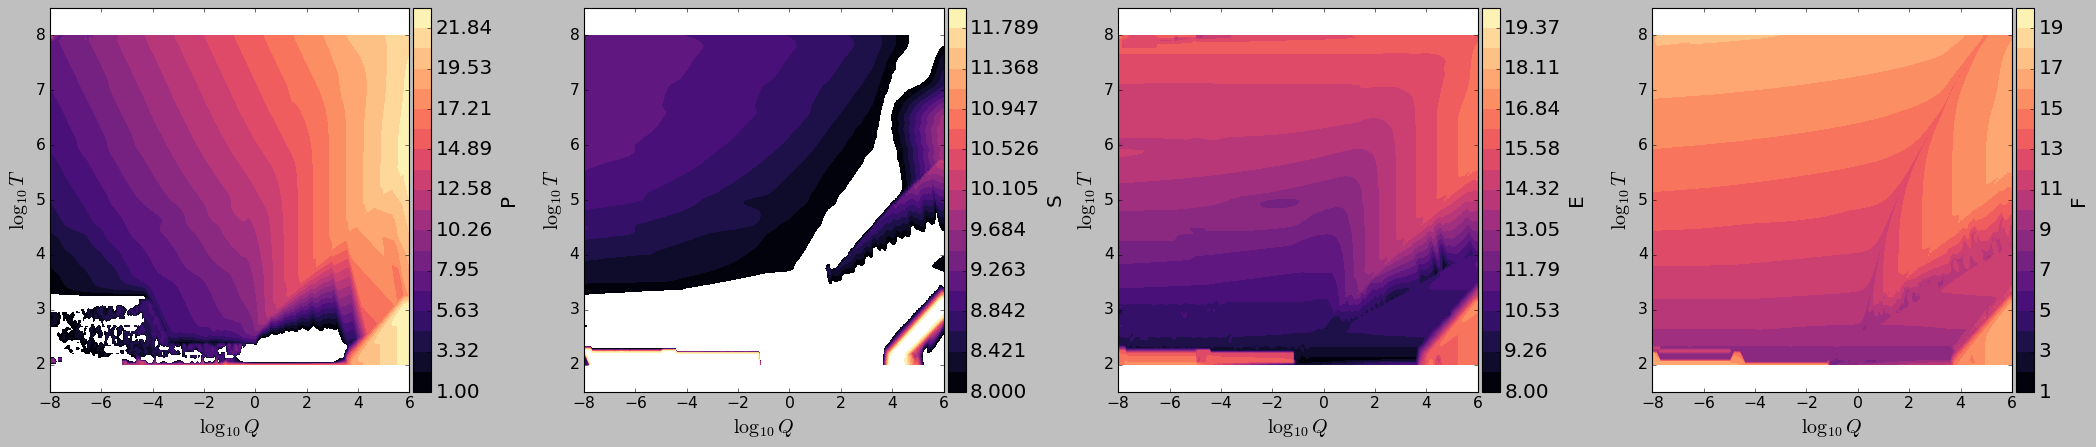

2


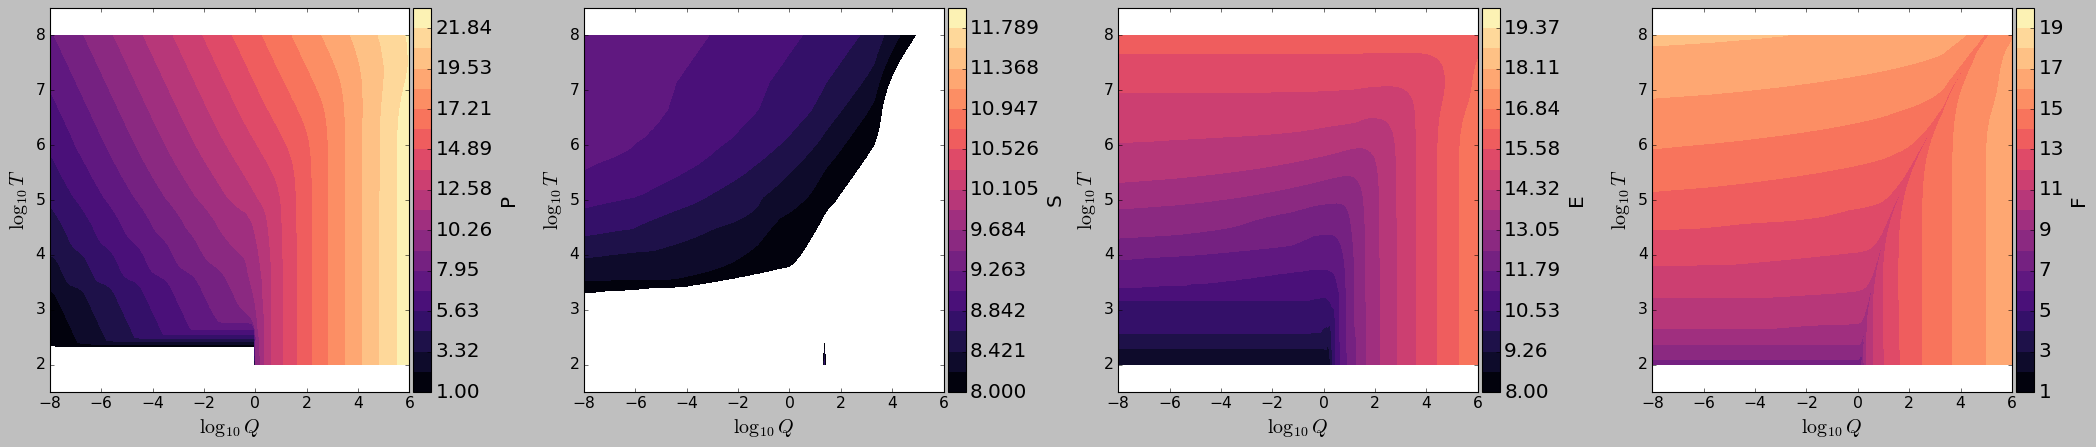

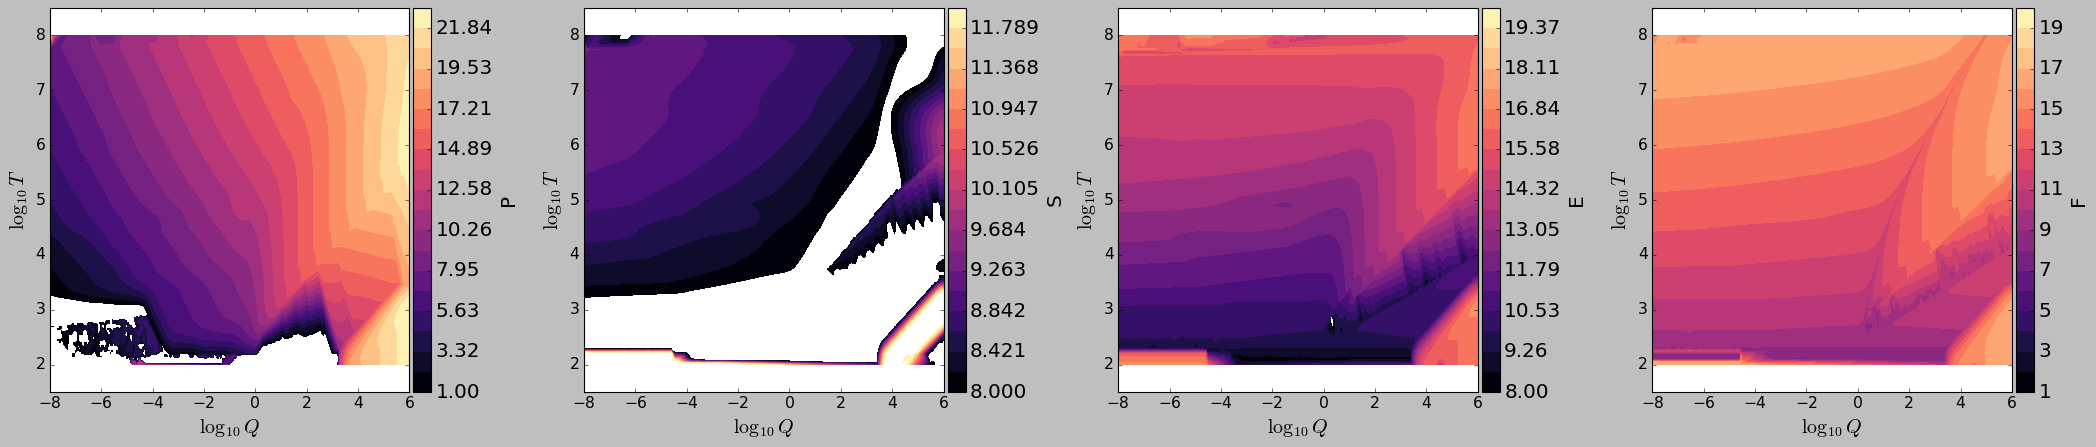

5


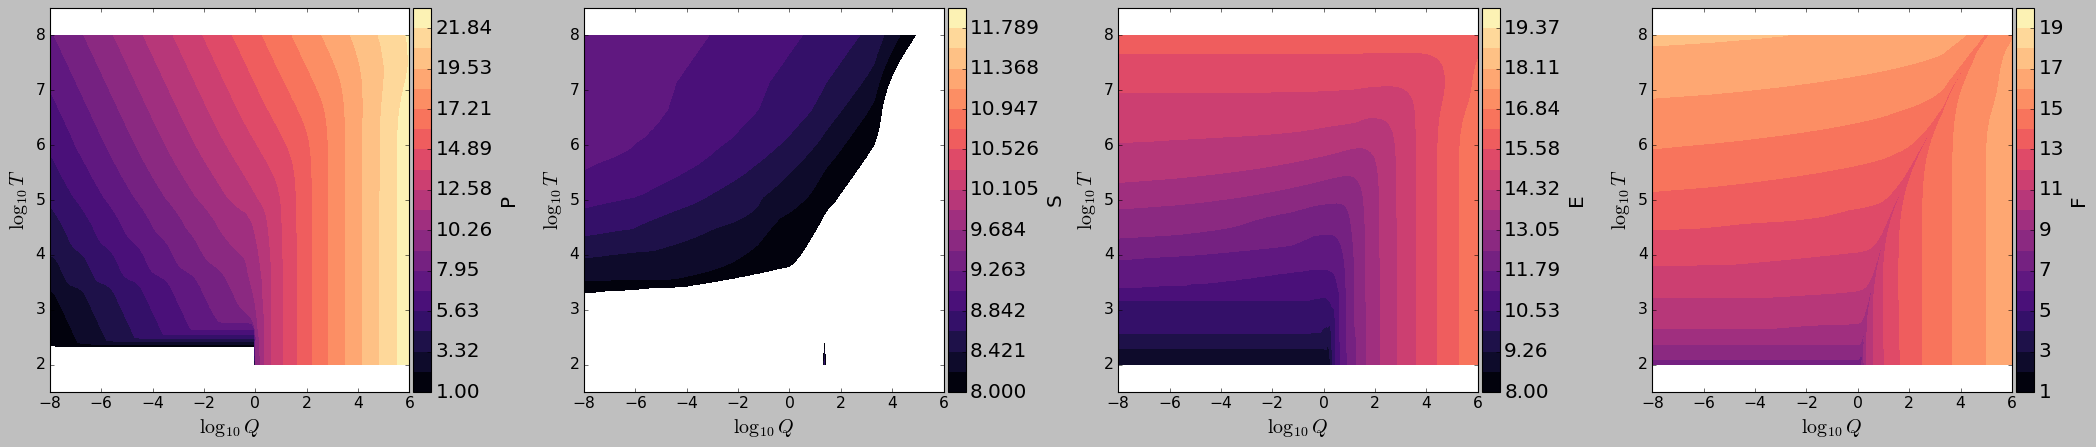

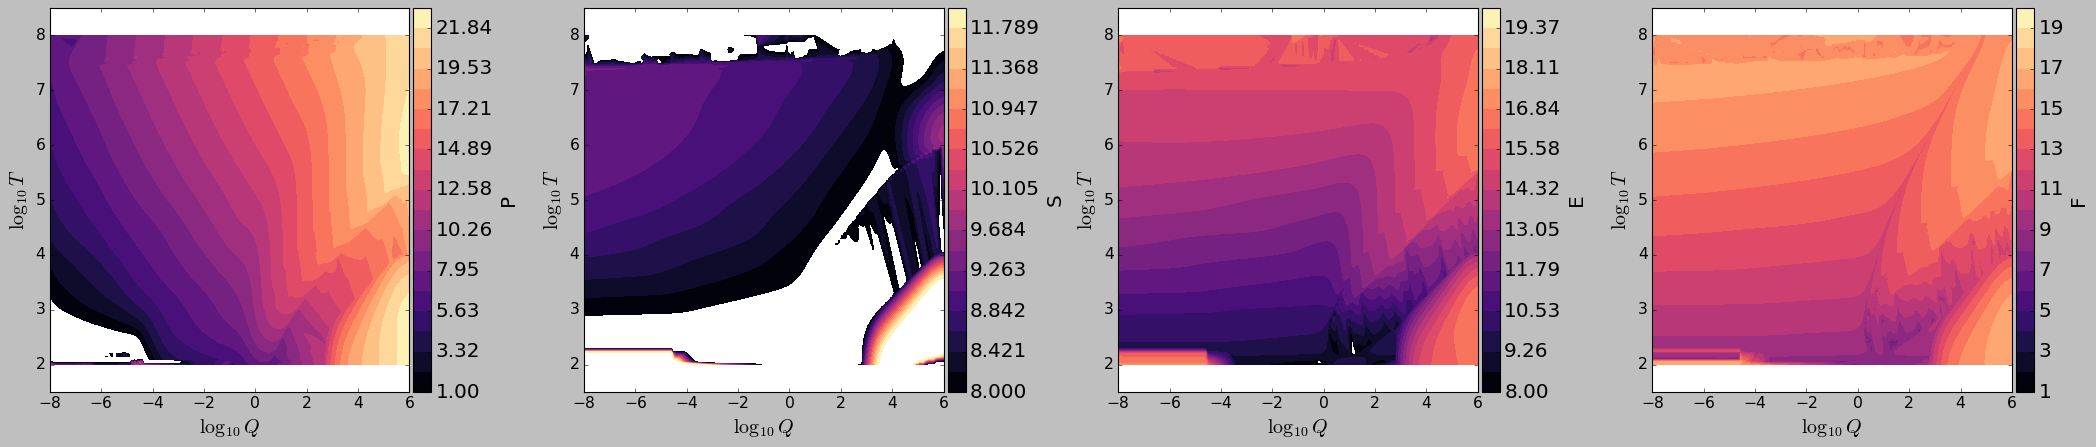

In [44]:
for s_i, s in enumerate(smoothing_arr):
    print(s)
    rock_water_TC = copy.deepcopy(rock_water)
    rock_water_TC.compute_atomic_number()

    rock_water_TC.compute_F_table(F_smoothing_kernel=s, F_nan_fill_value='reflect')

    meos.contourf_subplots_with_colorbars(nRow=1, nCol=4, 
                                xs=rock_water_TC.log10rhogrid,
                                ys=rock_water_TC.log10Tgrid,
                                zs=[rock_water_TC.log10Pgrid,rock_water_TC.log10Sgrid,rock_water_TC.log10Egrid,np.log10(np.abs(10**rock_water_TC.log10Egrid - ((10**rock_water_TC.log10Tgrid) * (10**rock_water_TC.log10Sgrid))))],
                                xlims=(-8,6),
                                ylims=(1.5,8.5),
                                zlims=[(1,23),(8,12),(8,20),(1,20)],
                                levels=20,
                                xlabels=r'$\log_{10}Q$',
                                ylabels=r'$\log_{10}T$',
                                zlabels=['P','S','E','F'],
                                cmap='magma', vlines=None, hlines=None, otherlines_x=None, otherlines_y=None, 
                                species='H', plot_interpolation_lines=False, savename=None)

    

    # replace existing PSE grids with F-based versions
    rock_water_TC.log10Pgrid = meos.fill_in_nans(rock_water_TC.F_log10Pgrid,rock_water_TC)
    rock_water_TC.log10Sgrid = meos.fill_in_nans(rock_water_TC.F_log10Sgrid,rock_water_TC)
    rock_water_TC.log10Egrid = meos.fill_in_nans(rock_water_TC.F_log10Egrid,rock_water_TC)

    rock_water_TC.log10Ugrid = rock_water_TC.log10Egrid
    
    rock_water_TC.compute_partials(species='Z')

    meos.contourf_subplots_with_colorbars(nRow=1, nCol=4, 
                                xs=rock_water_TC.log10rhogrid,
                                ys=rock_water_TC.log10Tgrid,
                                zs=[rock_water_TC.log10Pgrid,rock_water_TC.log10Sgrid,rock_water_TC.log10Egrid,np.log10(np.abs(10**rock_water_TC.log10Egrid - ((10**rock_water_TC.log10Tgrid) * (10**rock_water_TC.log10Sgrid))))],
                                xlims=(-8,6),
                                ylims=(1.5,8.5),
                                zlims=[(1,23),(8,12),(8,20),(1,20)],
                                levels=20,
                                xlabels=r'$\log_{10}Q$',
                                ylabels=r'$\log_{10}T$',
                                zlabels=['P','S','E','F'],
                                cmap='magma', vlines=None, hlines=None, otherlines_x=None, otherlines_y=None, 
                                species='H', plot_interpolation_lines=False, savename=None)

   

    MESA_cols_6to16(rock_water_TC,X=0.,Y=0.,mu_Z=0.5*(18.015 + 140.689),calc_eta=False)
    
    rock_water_TC.log10Qgrid = rock_water_TC.log10rhogrid - 2.*rock_water_TC.log10Tgrid + 12
    rock_water_TC_QT = change_table_coordinates(rock_water_TC,extrapolation_row_idxs=None)
    '''
    meos.contourf_sublots_with_colorbars(nRow=1, nCol=2, 
                                xs=rock_water_TC_QT.log10Qgrid_QT,
                                ys=rock_water_TC_QT.log10Tgrid_QT,
                                zs=[rock_water_TC_QT.dE_drho_T_QT,rock_water_TC_QT.Cp_QT],
                                xlims=(-12,5.4),
                                ylims=(2,8),
                                zlims=None,
                                levels=20,
                                xlabels=r'$\log_{10}Q$',
                                ylabels=r'$\log_{10}T$',
                                zlabels=['dE_drho','Cp'],
                                cmap='magma', vlines=None, hlines=None, otherlines_x=[x], otherlines_y=[y1,y2], 
                                species='H', plot_interpolation_lines=False, savename=None)
    '''
    #write_MESA_table_QT(rock_water_TC_QT, './my_MESAformat_tables/mesa-planetblend_100z00x.data',version=1, X=0.0, Z=1.0)
    write_MESA_table_QT(rock_water_TC_QT, './meos_MESAformat_CMS19+HG23+rock+water/mesa-planetblend-TC_s={0}_100z00x.data'.format(s),version=1, X=0.0, Z=1.0)
      

In [45]:
for s_i, s in enumerate(smoothing_arr):
    for sf_i, sf in enumerate(scaling_fac_arr):
        rock_water_control = copy.deepcopy(rock_water)
        rock_water_control.compute_atomic_number()
    
        rock_water_control.compute_F_table(F_smoothing_kernel=s, F_nan_fill_value='reflect')

        rock_water_control.F_Pgrid = meos.fill_in_nans(rock_water_control.F_Pgrid,rock_water_control)
        rock_water_control.F_Sgrid = meos.fill_in_nans(rock_water_control.F_Sgrid,rock_water_control)
        rock_water_control.F_Egrid = meos.fill_in_nans(rock_water_control.F_Egrid,rock_water_control)
    
    
        # replace existing PSE grids with F-based versions
        P_diff = rock_water_control.F_Pgrid - 10**rock_water_control.log10Pgrid
        S_diff = rock_water_control.F_Sgrid - 10**rock_water_control.log10Sgrid
        E_diff = rock_water_control.F_Egrid - 10**rock_water_control.log10Egrid

        rock_water_control.log10Pgrid = np.log10( 10**rock_water_control.log10Pgrid - sf*P_diff )
        rock_water_control.log10Sgrid = np.log10( 10**rock_water_control.log10Sgrid - sf*S_diff )
        rock_water_control.log10Egrid = np.log10( 10**rock_water_control.log10Egrid - sf*E_diff )

        rock_water_control.log10Pgrid = meos.fill_in_nans(rock_water_control.log10Pgrid,rock_water_control)
        rock_water_control.log10Sgrid = meos.fill_in_nans(rock_water_control.log10Sgrid,rock_water_control)
        rock_water_control.log10Egrid = meos.fill_in_nans(rock_water_control.log10Egrid,rock_water_control)
    
    
        rock_water_control.log10Ugrid = rock_water_control.log10Egrid

        rock_water_control.compute_partials(species='Z')

    
        MESA_cols_6to16(rock_water_control,X=0.,Y=0.,mu_Z=0.5*(18.015 + 140.689),calc_eta=False)
        
        rock_water_control.log10Qgrid = rock_water_control.log10rhogrid - 2.*rock_water_control.log10Tgrid + 12
        rock_water_control_QT = change_table_coordinates(rock_water_control,extrapolation_row_idxs=None)
        '''
        meos.contourf_sublots_with_colorbars(nRow=1, nCol=2, 
                                    xs=rock_water_control_QT.log10Qgrid_QT,
                                    ys=rock_water_control_QT.log10Tgrid_QT,
                                    zs=[rock_water_control_QT.dE_drho_T_QT,rock_water_control_QT.Cp_QT],
                                    xlims=(-12,5.4),
                                    ylims=(2,8),
                                    zlims=None,
                                    levels=20,
                                    xlabels=r'$\log_{10}Q$',
                                    ylabels=r'$\log_{10}T$',
                                    zlabels=['dE_drho','Cp'],
                                    cmap='magma', vlines=None, hlines=None, otherlines_x=[x], otherlines_y=[y1,y2], 
                                    species='H', plot_interpolation_lines=False, savename=None)

        '''
        #write_MESA_table_QT(rock_water_control_QT, './my_MESAformat_tables/mesa-planetblend_100z00x.data',version=1, X=0.0, Z=1.0)
        write_MESA_table_QT(rock_water_control_QT, './meos_MESAformat_CMS19+HG23+rock+water/mesa-planetblend-control_s={0}_sf={1}_100z00x.data'.format(s,sf),version=1, X=0.0, Z=1.0)
          

<>:36: SyntaxWarning: invalid escape sequence '\l'
<>:36: SyntaxWarning: invalid escape sequence '\l'
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/279995146.py:36: SyntaxWarning: invalid escape sequence '\l'
  '''
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/279995146.py:18: RuntimeWarning: invalid value encountered in log10
  rock_water_control.log10Pgrid = np.log10( 10**rock_water_control.log10Pgrid - sf*P_diff )
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/279995146.py:19: RuntimeWarning: invalid value encountered in log10
  rock_water_control.log10Sgrid = np.log10( 10**rock_water_control.log10Sgrid - sf*S_diff )
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/279995146.py:20: RuntimeWarning: invalid value encountered in log10
  rock_water_control.log10Egrid = np.log10( 10**rock_water_control.log10Egrid - sf*E_diff )


# XYZ mixture tables, 50/50 rock-water

In [46]:
print(type(rock_water))
rock_water.log10Ugrid = rock_water.log10Egrid
rock_water.atomic_number = 1
rock_water.mass_number= 1

<class 'EOSutils.EOSutils.simple_table'>


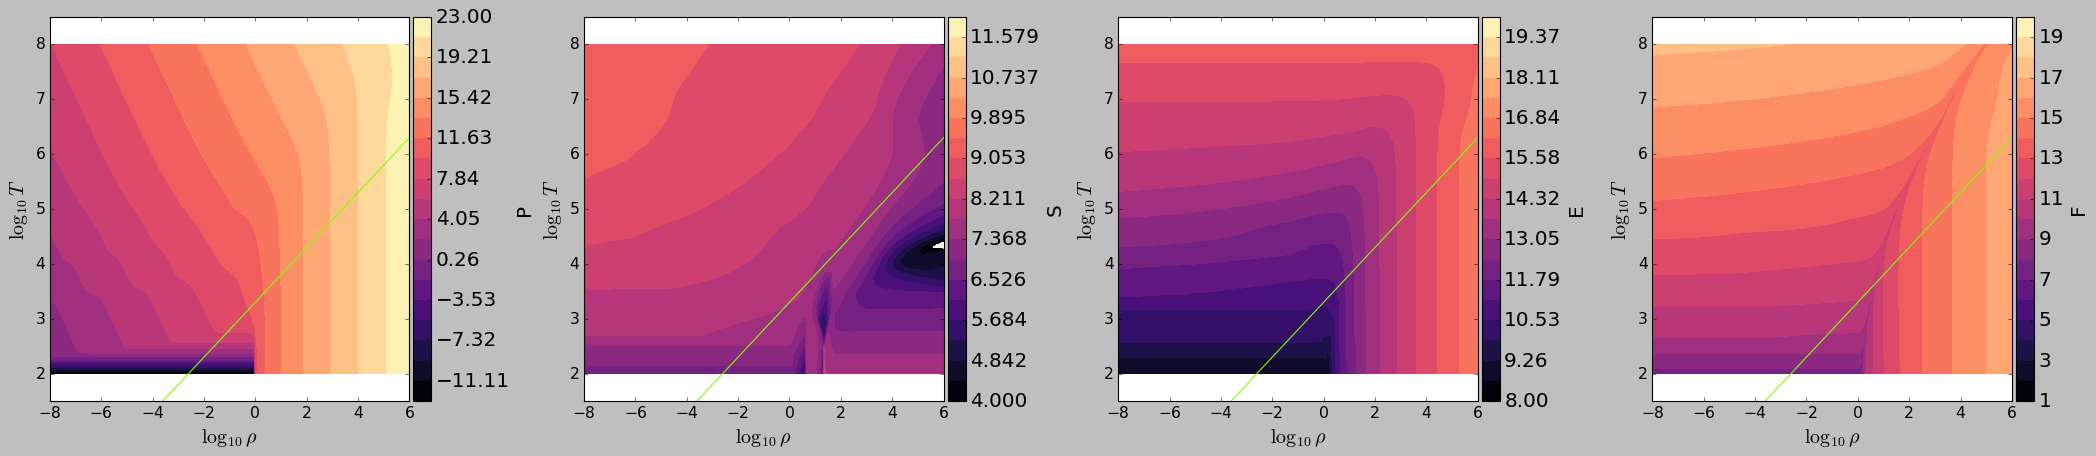

In [47]:
meos.contourf_subplots_with_colorbars(nRow=1, nCol=4, 
                                xs=rock_water.log10rhogrid,
                                ys=rock_water.log10Tgrid,
                                zs=[rock_water.log10Pgrid,rock_water.log10Sgrid,rock_water.log10Egrid,np.log10(np.abs(10**rock_water.log10Egrid - ((10**rock_water.log10Tgrid) * (10**rock_water.log10Sgrid))))],
                                xlims=(-8,6),
                                ylims=(1.5,8.5),
                                zlims=[(-13,23),(4,12),(8,20),(1,20)],
                                levels=20,
                                xlabels=r'$\log_{10}\rho$',
                                ylabels=r'$\log_{10}T$',
                                zlabels=['P','S','E','F'],
                                cmap='magma', vlines=None, hlines=None, otherlines_x=[unphys_x], otherlines_y=[unphys_y], 
                                species='H', plot_interpolation_lines=False, savename=None)
                
        

In [48]:
'''
rock_water_PT = meos.interpolated_PTtable(rock_water,desired_Parr = np.arange(-13.0,23.04,0.05),rhobounds=(-8,6),mask_unphysical=False,extrapolate_below_T=2.89)

outfile = open("./rock_water_PT.pkl","wb")
pickle.dump(rock_water_PT,outfile)
outfile.close()
'''

'\nrock_water_PT = meos.interpolated_PTtable(rock_water,desired_Parr = np.arange(-13.0,23.04,0.05),rhobounds=(-8,6),mask_unphysical=False,extrapolate_below_T=2.89)\n\noutfile = open("./rock_water_PT.pkl","wb")\npickle.dump(rock_water_PT,outfile)\noutfile.close()\n'

In [49]:

infile = open("./rock_water_PT.pkl","rb")
rock_water_PT = pickle.load(infile)
infile.close()


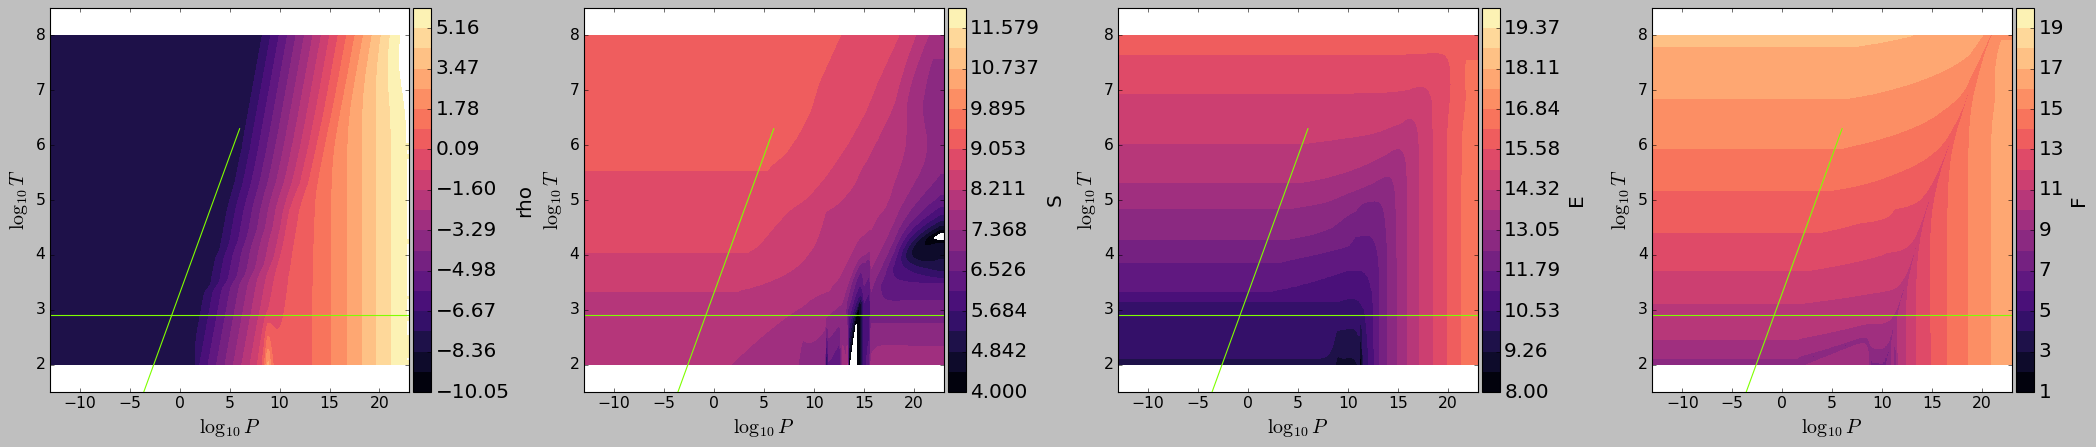

In [50]:
meos.contourf_subplots_with_colorbars(nRow=1, nCol=4, 
                                xs=rock_water_PT.log10Pgrid,
                                ys=rock_water_PT.log10Tgrid,
                                zs=[rock_water_PT.log10rhogrid,rock_water_PT.log10Sgrid,rock_water_PT.log10Egrid,np.log10(np.abs(10**rock_water_PT.log10Egrid - ((10**rock_water_PT.log10Tgrid) * (10**rock_water_PT.log10Sgrid))))],
                                xlims=(-13,23),
                                ylims=(1.5,8.5),
                                zlims=[(-10.05,6),(4,12),(8,20),(1,20)],
                                levels=20,
                                xlabels=r'$\log_{10}P$',
                                ylabels=r'$\log_{10}T$',
                                zlabels=['rho','S','E','F'],
                                cmap='magma', vlines=None, hlines=[2.9], otherlines_x=[unphys_x], otherlines_y=[unphys_y], 
                                species='H', plot_interpolation_lines=False, savename=None)
                
        

In [51]:
print(rock_water_PT.log10Pgrid[280:])
print(rock_water.log10Tgrid[:,0])

[[ 1.    1.    1.   ...  1.    1.    1.  ]
 [ 1.05  1.05  1.05 ...  1.05  1.05  1.05]
 [ 1.1   1.1   1.1  ...  1.1   1.1   1.1 ]
 ...
 [22.9  22.9  22.9  ... 22.9  22.9  22.9 ]
 [22.95 22.95 22.95 ... 22.95 22.95 22.95]
 [23.   23.   23.   ... 23.   23.   23.  ]]
[2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2.

In [ ]:
Xarr = np.arange(0.0,1.0,0.1)[::-1]
Zarr = np.arange(0.1,1.0,0.1)

#Xarr = np.atleast_1d((0.6))
#Zarr = np.atleast_1d((0.1))

#Xarr = np.array((0.0, 0.1))
#Zarr = np.array((0.1, 1.0))

#Xarr = np.array((0.0,0.01,0.02,0.1,0.2,0.3,0.4,0.5,0.6,0.70,0.71,0.8,0.9,0.98,0.99))
#Zarr = np.array((0.0,0.01,0.02,0.1,0.2,0.3,0.4,0.5,0.6,0.70,0.71,0.8,0.9,0.98,0.99))

for i, xi in enumerate(Xarr):
    for k, zi in enumerate(Zarr):
        if (xi + zi) > 1.0:
            continue

        # REMOVE THIS later
        if xi >= 0.6 and zi <= 0.1:
            continue
            
        yi = 1. - (xi + zi)
        print(xi,yi,zi)

        if xi < 1.0:
            xstr = str(xi).split('.')[-1]
            if len(xstr)==1:
                xstr = xstr+'0'
            if len(xstr) > 2:
                xstr = xstr[0:2]
        elif xi == 1.0:
            xstr = '100'

        if zi < 1.0:
            zstr = str(zi).split('.')[-1]
            if len(zstr)==1:
                zstr = zstr+'0'
            if len(zstr) > 2:
                zstr = zstr[0:2]
        elif zi == 1.0:
            zstr = '100'

        print(zstr, xstr)
        
        savefilename = './meos_MESAformat_CMS19+HG23+rock+water/mesa-planetblend_{0}z{1}x.data'.format(zstr,xstr)
        print(savefilename)
            
        #if os.path.isfile(savefilename):
        #    print('exists already')
        #    continue
            
        #else:
        if True:

            mixed_XYZ = add_mixing_terms(H_PTtable=bln_H_PT, He_PTtable=cms_He_PT, Z_PTtable=rock_water_PT, X=xi, Y=yi, mu_Z=0.5*(18.015 + 140.689),HG23path="/Users/emily/Documents/astro/giant_planets/MESA_EoS/HG23_Vmix_Smix_Umix.csv")
            #print(mixed_XYZ.log10Sgrid)
            mixed_XYZ.log10Sgrid = meos.fill_in_nans(mixed_XYZ.log10Sgrid, mixed_XYZ)

            '''

            meos.contourf_subplots_with_colorbars(nRow=1, nCol=4, 
                                xs=mixed_XYZ.log10Pgrid,
                                ys=mixed_XYZ.log10Tgrid,
                                zs=[mixed_XYZ.log10rhogrid,mixed_XYZ.log10Sgrid,mixed_XYZ.log10Egrid,np.log10(np.abs(10**mixed_XYZ.log10Egrid - ((10**mixed_XYZ.log10Tgrid) * (10**mixed_XYZ.log10Sgrid))))],
                                xlims=(-13,23),
                                ylims=(1.5,8.5),
                                zlims=[(-10.05,6),(4,12),(8,20),(1,20)],
                                levels=20,
                                xlabels=r'$\log_{10}P$',
                                ylabels=r'$\log_{10}T$',
                                zlabels=['rho','S','E','F'],
                                cmap='magma', vlines=None, hlines=None, otherlines_x=[unphys_x], otherlines_y=[unphys_y], 
                                species='H', plot_interpolation_lines=False, savename=None)
                
            '''
            
            start = time.time()
            if (xi >= yi) & (xi >= zi):
                mixed_XYZ_rhoT = reinterpolate_mixed_table_to_rhoT(mixed_XYZ,reference_Pgrid=bln_H.log10Pgrid,P_lowlim=-13., X=xi, Y=yi)
            elif (yi > xi) & (yi >= zi):
                mixed_XYZ_rhoT = reinterpolate_mixed_table_to_rhoT(mixed_XYZ,reference_Pgrid=cms_He.log10Pgrid,P_lowlim=-13., X=xi, Y=yi)
            else:
                mixed_XYZ_rhoT = reinterpolate_mixed_table_to_rhoT(mixed_XYZ,reference_Pgrid=rock_water.log10Pgrid, P_lowlim=-13.,X=xi, Y=yi)
            end = time.time()
            print((end-start)/60.)
    
            mixed_XYZ_rhoT.compute_atomic_number()
            mixed_XYZ_rhoT.compute_partials()
            '''
            meos.contourf_subplots_with_colorbars(nRow=1, nCol=4, 
                                xs=mixed_XYZ_rhoT.log10rhogrid,
                                ys=mixed_XYZ_rhoT.log10Tgrid,
                                zs=[mixed_XYZ_rhoT.log10Pgrid,mixed_XYZ_rhoT.log10Sgrid,mixed_XYZ_rhoT.log10Egrid,np.log10(np.abs(10**mixed_XYZ_rhoT.log10Egrid - ((10**mixed_XYZ_rhoT.log10Tgrid) * (10**mixed_XYZ_rhoT.log10Sgrid))))],
                                xlims=(-8,6),
                                ylims=(1.5,8.5),
                                zlims=[(-13,23),(4,12),(8,20),(1,20)],
                                levels=20,
                                xlabels=r'$\log_{10}\rho$',
                                ylabels=r'$\log_{10}T$',
                                zlabels=['P','S','E','F'],
                                cmap='magma', vlines=None, hlines=None, otherlines_x=[unphys_x], otherlines_y=[unphys_y], 
                                species='H', plot_interpolation_lines=False, savename=None)
            '''
        
            MESA_cols_6to16(mixed_XYZ_rhoT, X=Xarr[i],Y=1.-(Xarr[i]+Zarr[k]),mu_Z=0.5*(18.015 + 140.689),calc_eta=True)

            mixed_XYZ_rhoT_QT = change_table_coordinates(mixed_XYZ_rhoT,extrapolation_row_idxs=None,extrapolation_col_idxs=None)
            
            write_MESA_table_QT(mixed_XYZ_rhoT_QT, savefilename,version=1, X=xi, Z=zi)

            for s_i, s in enumerate(smoothing_arr):
                print(s)
                TC = copy.deepcopy(mixed_XYZ_rhoT)
                
                TC.compute_F_table(F_smoothing_kernel=s, F_nan_fill_value='reflect')
                '''
                meos.contourf_subplots_with_colorbars(nRow=1, nCol=4, 
                                xs=TC.log10rhogrid,
                                ys=TC.log10Tgrid,
                                zs=[TC.log10Pgrid,TC.log10Sgrid,TC.log10Egrid,np.log10(np.abs(10**TC.log10Egrid - ((10**TC.log10Tgrid) * (10**TC.log10Sgrid))))],
                                xlims=(-8,6),
                                ylims=(1.5,8.5),
                                zlims=[(-13,23),(4,12),(8,20),(1,20)],
                                levels=20,
                                xlabels=r'$\log_{10}\rho$',
                                ylabels=r'$\log_{10}T$',
                                zlabels=['P','S','E','F'],
                                cmap='magma', vlines=None, hlines=None, otherlines_x=[unphys_x], otherlines_y=[unphys_y], 
                                species='H', plot_interpolation_lines=False, savename=None)
                '''
    
                # replace existing PSE grids with F-based versions
                TC.log10Pgrid = meos.fill_in_nans(TC.F_log10Pgrid,TC)
                TC.log10Sgrid = meos.fill_in_nans(TC.F_log10Sgrid,TC)
                TC.log10Egrid = meos.fill_in_nans(TC.F_log10Egrid,TC)

                TC.log10Ugrid = TC.log10Egrid

                TC.compute_partials()
                '''
                meos.contourf_subplots_with_colorbars(nRow=1, nCol=4, 
                                xs=TC.log10rhogrid,
                                ys=TC.log10Tgrid,
                                zs=[TC.log10Pgrid,TC.log10Sgrid,TC.log10Egrid,np.log10(np.abs(10**TC.log10Egrid - ((10**TC.log10Tgrid) * (10**TC.log10Sgrid))))],
                                xlims=(-8,6),
                                ylims=(1.5,8.5),
                                zlims=[(-13,23),(4,12),(8,20),(1,20)],
                                levels=20,
                                xlabels=r'$\log_{10}\rho$',
                                ylabels=r'$\log_{10}T$',
                                zlabels=['P','S','E','F'],
                                cmap='magma', vlines=None, hlines=None, otherlines_x=[unphys_x], otherlines_y=[unphys_y], 
                                species='H', plot_interpolation_lines=False, savename=None)
                
                '''
                
                MESA_cols_6to16(TC,X=Xarr[i],Y=1.-Xarr[i],mu_Z=0.5*(18.015 + 140.689),calc_eta=False)

                   
                TC.log10Qgrid = TC.log10rhogrid - 2.*TC.log10Tgrid + 12

                TC_QT = change_table_coordinates(TC,extrapolation_row_idxs=None)

                '''
                meos.contourf_sublots_with_colorbars(nRow=1, nCol=2, 
                                                xs=TC_QT.log10Qgrid_QT,
                                                ys=TC_QT.log10Tgrid_QT,
                                                zs=[TC_QT.dE_drho_T_QT,TC_QT.Cp_QT],
                                                xlims=(-12,5.4),
                                                ylims=(2,8),
                                                zlims=None,
                                                levels=20,
                                                xlabels=r'$\log_{10}Q$',
                                                ylabels=r'$\log_{10}T$',
                                                zlabels=['dE_drho','Cp'],
                                                cmap='magma', vlines=None, hlines=None, otherlines_x=[x], otherlines_y=[y1,y2], 
                                                species='H', plot_interpolation_lines=False, savename=None)
                '''
                #write_MESA_table_QT(TC_QT, './my_MESAformat_tables/mesa-planetblend-TC_s={0}_{1}0z{2}0x.data'.format(s,str(np.round(zi,1))[-1],str(np.round(xi,1))[-1]),version=1, X=xi, Z=zi)
                #write_MESA_table_QT(TC_QT, './meos_MESAformat_CMS19+HG23+rock+water/mesa-planetblend-TC_s={0}_{1}0z{2}0x.data'.format(s,str(np.round(zi,1))[-1],str(np.round(xi,1))[-1]),version=1, X=xi, Z=zi)
                write_MESA_table_QT(TC_QT, './meos_MESAformat_CMS19+HG23+rock+water/mesa-planetblend-TC_s={0}_{1}z{2}x.data'.format(s,zstr,xstr),version=1, X=xi, Z=zi)
                
            for s_i, s in enumerate(smoothing_arr):
                for sf_i, sf in enumerate(scaling_fac_arr):
                    control = copy.deepcopy(mixed_XYZ_rhoT)
                    
                    control.compute_F_table(F_smoothing_kernel=s, F_nan_fill_value='reflect')

                    control.F_Pgrid = meos.fill_in_nans(control.F_Pgrid,control)
                    control.F_Sgrid = meos.fill_in_nans(control.F_Sgrid,control)
                    control.F_Egrid = meos.fill_in_nans(control.F_Egrid,control)
    
                    
                    # replace existing PSE grids with F-based versions
                    P_diff = control.F_Pgrid - 10**control.log10Pgrid
                    S_diff = control.F_Sgrid - 10**control.log10Sgrid
                    E_diff = control.F_Egrid - 10**control.log10Egrid
                
                    control.log10Pgrid = np.log10( 10**control.log10Pgrid - sf*P_diff )
                    control.log10Sgrid = np.log10( 10**control.log10Sgrid - sf*S_diff )
                    control.log10Egrid = np.log10( 10**control.log10Egrid - sf*E_diff )

                    control.log10Pgrid = meos.fill_in_nans(control.log10Pgrid,control)
                    control.log10Sgrid = meos.fill_in_nans(control.log10Sgrid,control)
                    control.log10Egrid = meos.fill_in_nans(control.log10Egrid,control)
            
                    
                    control.log10Ugrid = control.log10Egrid

                    control.compute_partials()
                    
                    MESA_cols_6to16(control,X=Xarr[i],Y=1.-Xarr[i],mu_Z=0.5*(18.015 + 140.689),calc_eta=False)
                        
                    control.log10Qgrid = control.log10rhogrid - 2.*control.log10Tgrid + 12
                    control_QT = change_table_coordinates(control,extrapolation_row_idxs=None)
                    '''
                    meos.contourf_sublots_with_colorbars(nRow=1, nCol=2, 
                                                    xs=control_QT.log10Qgrid_QT,
                                                    ys=control_QT.log10Tgrid_QT,
                                                    zs=[control_QT.dE_drho_T_QT,control_QT.Cp_QT],
                                                    xlims=(-12,5.4),
                                                    ylims=(2,8),
                                                    zlims=None,
                                                    levels=20,
                                                    xlabels=r'$\log_{10}Q$',
                                                    ylabels=r'$\log_{10}T$',
                                                    zlabels=['dE_drho','Cp'],
                                                    cmap='magma', vlines=None, hlines=None, otherlines_x=[x], otherlines_y=[y1,y2], 
                                                    species='H', plot_interpolation_lines=False, savename=None)
                
                    '''  
                    #write_MESA_table_QT(control_QT, './my_MESAformat_tables/mesa-planetblend-control_s={0}_sf={1}_{2}0z{3}0x.data'.format(s,sf,str(np.round(zi,1))[-1],str(np.round(xi,1))[-1]),version=1, X=xi, Z=zi)
                    #write_MESA_table_QT(control_QT, './meos_MESAformat_CMS19+HG23+rock+water/mesa-planetblend-control_s={0}_sf={1}_{2}0z{3}0x.data'.format(s,sf,str(np.round(zi,1))[-1],str(np.round(xi,1))[-1]),version=1, X=xi, Z=zi)
                    write_MESA_table_QT(control_QT, './meos_MESAformat_CMS19+HG23+rock+water/mesa-planetblend-control_s={0}_sf={1}_{2}z{3}x.data'.format(s,sf,zstr,xstr),version=1, X=xi, Z=zi)

                    

<>:59: SyntaxWarning: invalid escape sequence '\l'
<>:89: SyntaxWarning: invalid escape sequence '\l'
<>:116: SyntaxWarning: invalid escape sequence '\l'
<>:140: SyntaxWarning: invalid escape sequence '\l'
<>:164: SyntaxWarning: invalid escape sequence '\l'
<>:216: SyntaxWarning: invalid escape sequence '\l'
<>:59: SyntaxWarning: invalid escape sequence '\l'
<>:89: SyntaxWarning: invalid escape sequence '\l'
<>:116: SyntaxWarning: invalid escape sequence '\l'
<>:140: SyntaxWarning: invalid escape sequence '\l'
<>:164: SyntaxWarning: invalid escape sequence '\l'
<>:216: SyntaxWarning: invalid escape sequence '\l'
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/3197863647.py:59: SyntaxWarning: invalid escape sequence '\l'
  '''
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/3197863647.py:89: SyntaxWarning: invalid escape sequence '\l'
  '''
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/3197863647.py:116: SyntaxWarning: invalid escape 

0.8 0.0 0.2
20 80
./meos_MESAformat_CMS19+HG23+rock+water/mesa-planetblend_20z80x.data
[[-13.   -13.   -13.   ... -13.   -13.   -13.  ]
 [-12.95 -12.95 -12.95 ... -12.95 -12.95 -12.95]
 [-12.9  -12.9  -12.9  ... -12.9  -12.9  -12.9 ]
 ...
 [ 22.9   22.9   22.9  ...  22.9   22.9   22.9 ]
 [ 22.95  22.95  22.95 ...  22.95  22.95  22.95]
 [ 23.    23.    23.   ...  23.    23.    23.  ]]
[[ 1.    1.    1.   ...  1.    1.    1.  ]
 [ 1.05  1.05  1.05 ...  1.05  1.05  1.05]
 [ 1.1   1.1   1.1  ...  1.1   1.1   1.1 ]
 ...
 [22.9  22.9  22.9  ... 22.9  22.9  22.9 ]
 [22.95 22.95 22.95 ... 22.95 22.95 22.95]
 [23.   23.   23.   ... 23.   23.   23.  ]]
2.8230743169784547


/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/3179727013.py:84: RuntimeWarning: divide by zero encountered in divide
  mu_e = 1./( X*((1.-f_H2-f_H)/(2*mu_H)) + Y*((2.-2*f_He-f_Heplus)/(3.*mu_He)) )
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/3179727013.py:85: RuntimeWarning: divide by zero encountered in log10
  table.log_free_e = np.log10(1./mu_e)
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/3179727013.py:85: RuntimeWarning: invalid value encountered in log10
  table.log_free_e = np.log10(1./mu_e)


2.0
2.05


# Protosolar composition specifically (Lodders+2021)

In [53]:
X = 0.706
Y = 0.277
Z = 0.017

print(X+Y+Z)

1.0


In [54]:
X = 0.71
Y = 0.28
Z = 0.02
print(X+Y+Z)

1.01


In [55]:
mixed_XYZ = add_mixing_terms(H_PTtable=bln_H_PT, He_PTtable=cms_He_PT, Z_PTtable=rock_water_PT, X=0.706, Y=0.277, mu_Z=0.5*(18.015 + 140.689), HG23path="/Users/emily/Documents/astro/giant_planets/MESA_EoS/HG23_Vmix_Smix_Umix.csv")
mixed_XYZ.log10Sgrid = meos.fill_in_nans(mixed_XYZ.log10Sgrid, mixed_XYZ)
    
mixed_XYZ_rhoT = reinterpolate_mixed_table_to_rhoT(mixed_XYZ,reference_Pgrid=bln_H.log10Pgrid, P_lowlim=-13.,X=xi, Y=yi)
mixed_XYZ_rhoT.compute_partials()
    
MESA_cols_6to16(mixed_XYZ_rhoT, X=0.706,Y=0.277,mu_Z=0.5*(18.015 + 140.689),calc_eta=True)
mixed_XYZ_rhoT_QT = change_table_coordinates(mixed_XYZ_rhoT,extrapolation_row_idxs=None,extrapolation_col_idxs=None)
            
savefilename = './meos_MESAformat_CMS19+HG23+rock+water/mesa-planetblend_protosolar.data'
            
write_MESA_table_QT(mixed_XYZ_rhoT_QT, savefilename,version=1, X=0.706, Z=0.017)
        

/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/1621059805.py:129: RuntimeWarning: invalid value encountered in log10
  mixed_log10Sgrid[i,j] = np.log10(X*S_H + Y*S_He + X*Y*this_Smix + Z*S_Z - S_id_mix_XYonly + S_id_mix_XYZ)


[[-13.   -13.   -13.   ... -13.   -13.   -13.  ]
 [-12.95 -12.95 -12.95 ... -12.95 -12.95 -12.95]
 [-12.9  -12.9  -12.9  ... -12.9  -12.9  -12.9 ]
 ...
 [ 22.9   22.9   22.9  ...  22.9   22.9   22.9 ]
 [ 22.95  22.95  22.95 ...  22.95  22.95  22.95]
 [ 23.    23.    23.   ...  23.    23.    23.  ]]
[[ 1.    1.    1.   ...  1.    1.    1.  ]
 [ 1.05  1.05  1.05 ...  1.05  1.05  1.05]
 [ 1.1   1.1   1.1  ...  1.1   1.1   1.1 ]
 ...
 [22.9  22.9  22.9  ... 22.9  22.9  22.9 ]
 [22.95 22.95 22.95 ... 22.95 22.95 22.95]
 [23.   23.   23.   ... 23.   23.   23.  ]]
2.0
2.05
2.0999999999999996
2.1499999999999995
2.1999999999999993
2.249999999999999
2.299999999999999
2.3499999999999988
2.3999999999999986
2.4499999999999984
2.4999999999999982
2.549999999999998
2.599999999999998
2.6499999999999977
2.6999999999999975
2.7499999999999973
2.799999999999997
2.849999999999997
2.899999999999997
2.9499999999999966
2.9999999999999964
3.0499999999999963
3.099999999999996
3.149999999999996
3.1999999999999957

<>:50: SyntaxWarning: invalid escape sequence '\l'
<>:50: SyntaxWarning: invalid escape sequence '\l'
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/645422187.py:50: SyntaxWarning: invalid escape sequence '\l'
  '''


1


/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/652309645.py:178: RuntimeWarning: invalid value encountered in log10
  self.F_log10Pgrid = np.log10(self.F_Pgrid)
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/652309645.py:179: RuntimeWarning: invalid value encountered in log10
  self.F_log10Sgrid = np.log10(self.F_Sgrid)
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/652309645.py:180: RuntimeWarning: invalid value encountered in log10
  self.F_log10Egrid = np.log10(self.F_Egrid)
/Users/emily/Documents/astro/giant_planets/MESA_EoS/EOSutils/EOSutils/EOSutils.py:1559: UserWarning: The following kwargs were not used by contour: 'shading'
  cs = axes[i,j].contourf(xs[i*nCol + j], ys[i*nCol + j], zs[i*nCol + j], shading='nearest', cmap=cmap[i*nCol + j], levels=np.linspace(zlims[i*nCol+j][0],zlims[i*nCol+j][1],levels[i*nCol+j]))


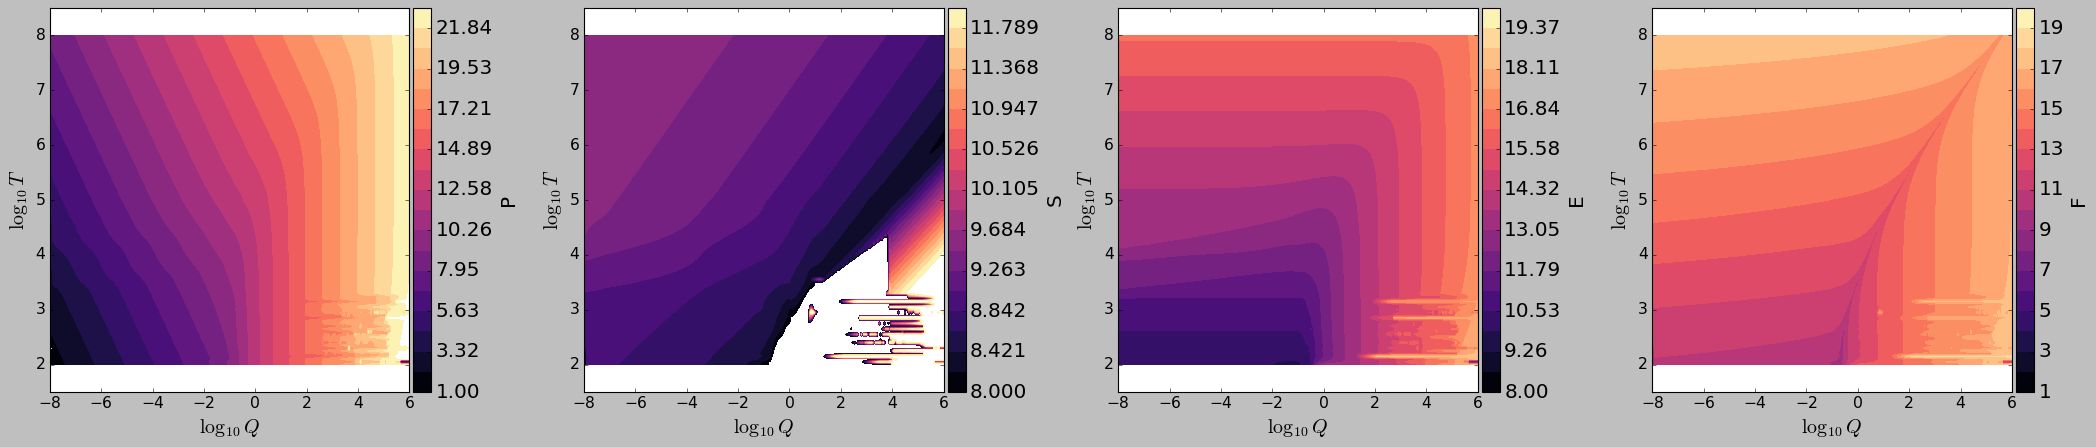

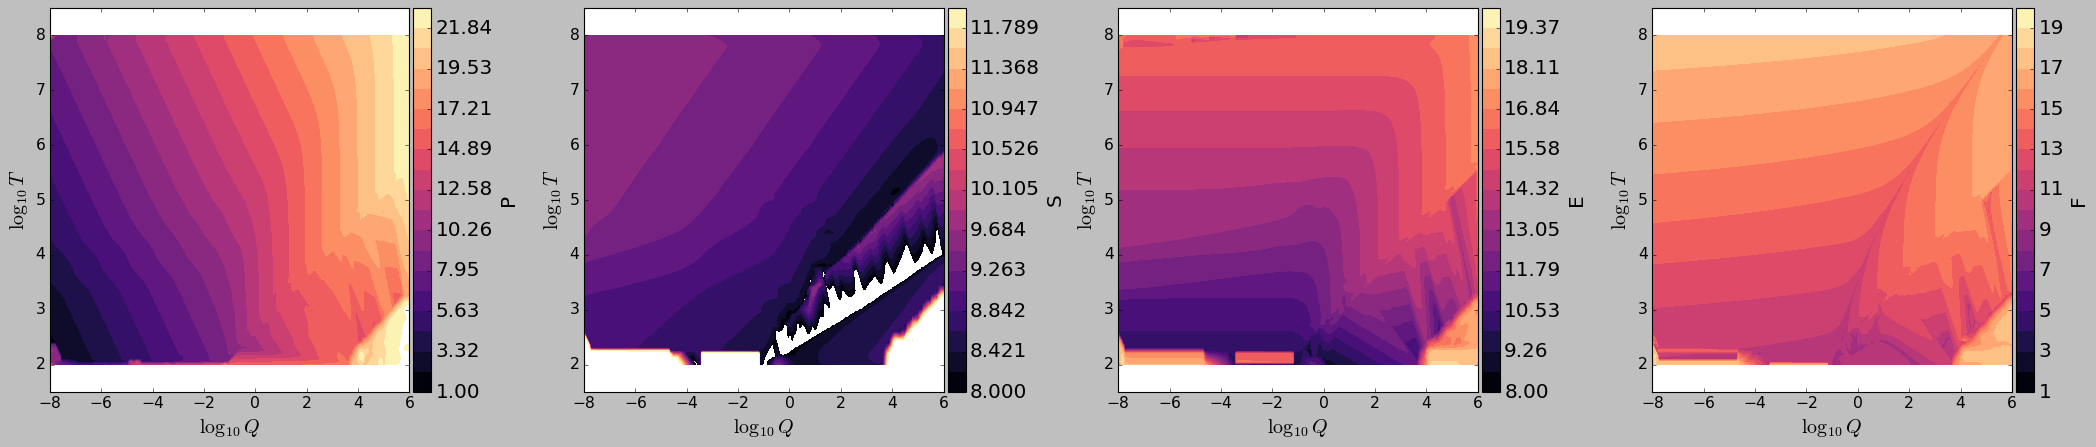

2


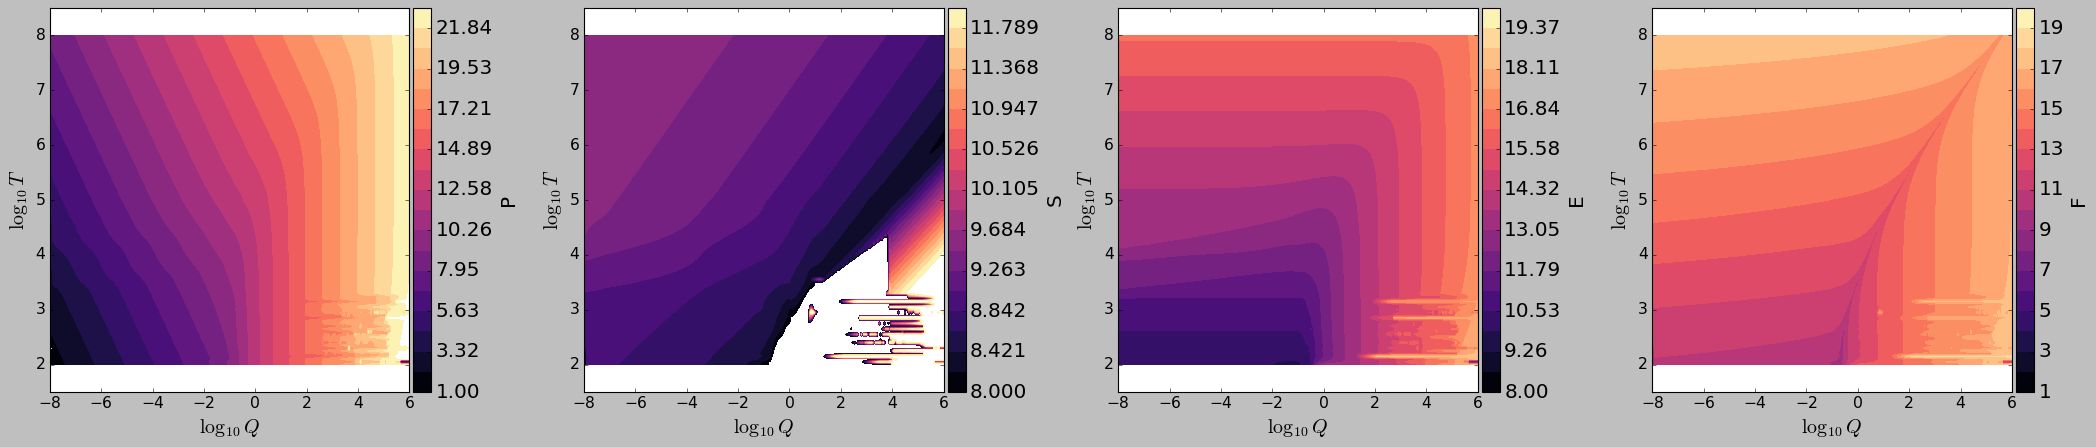

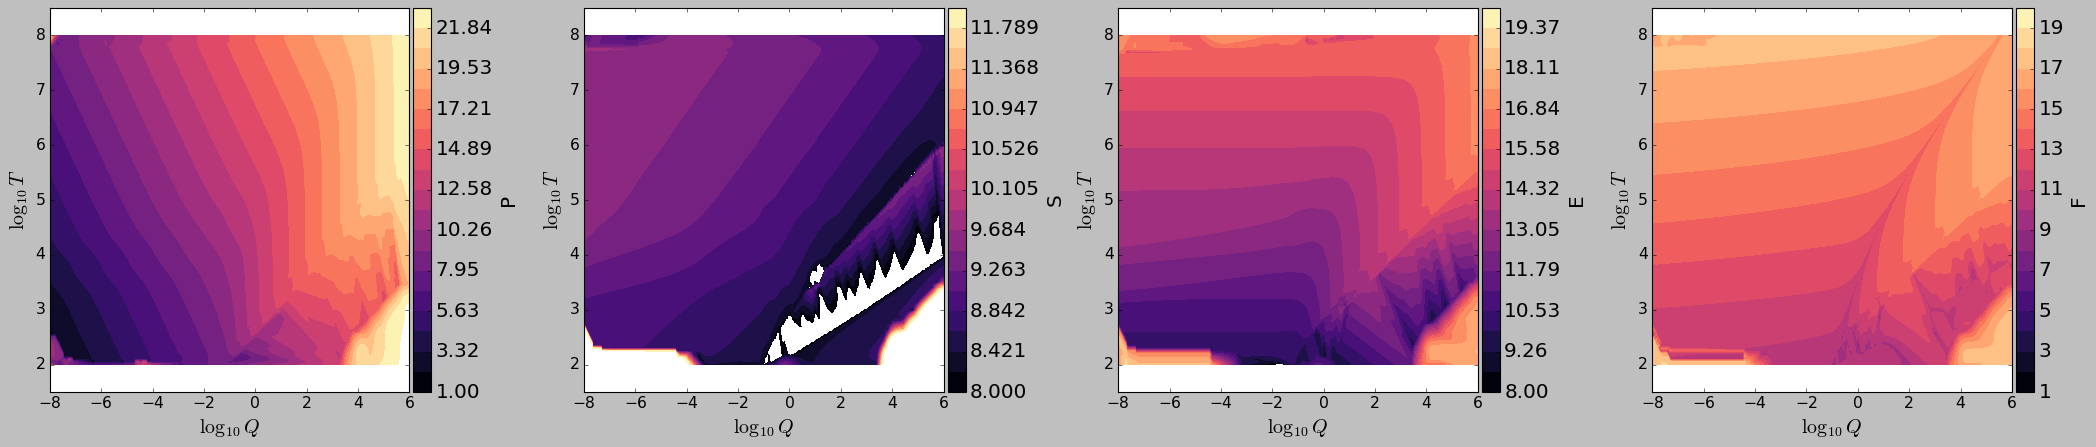

5


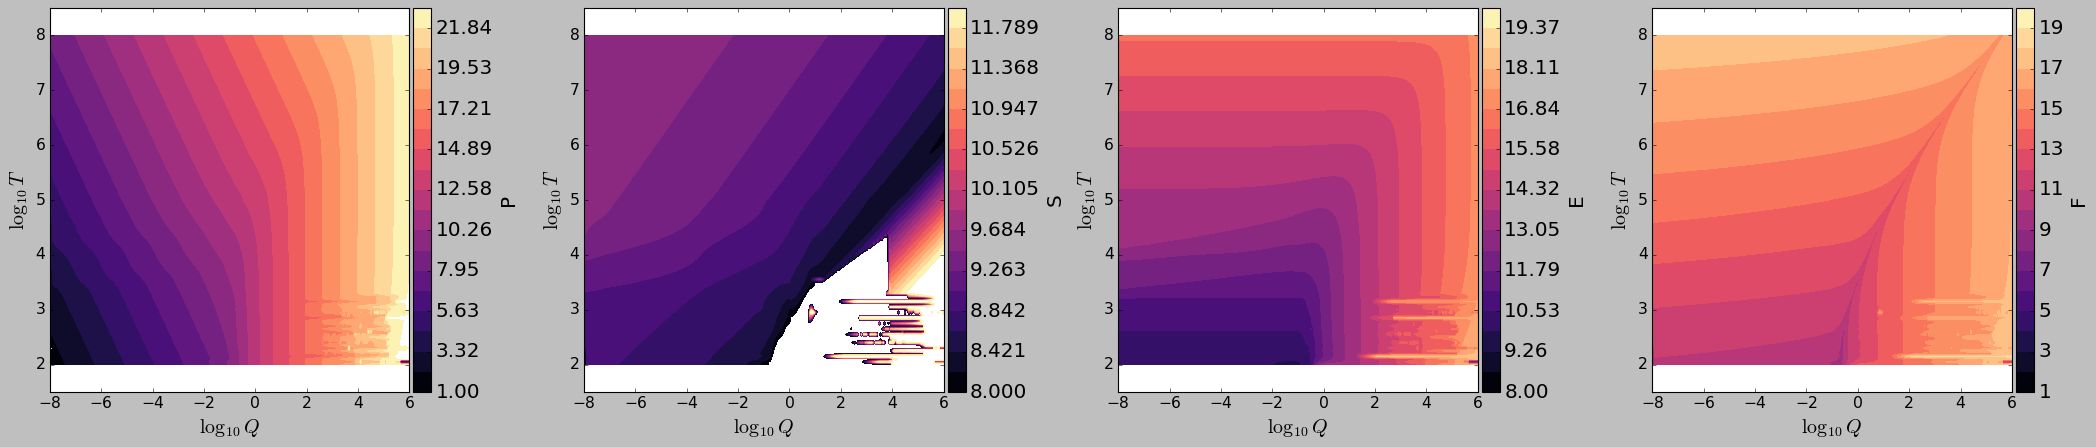

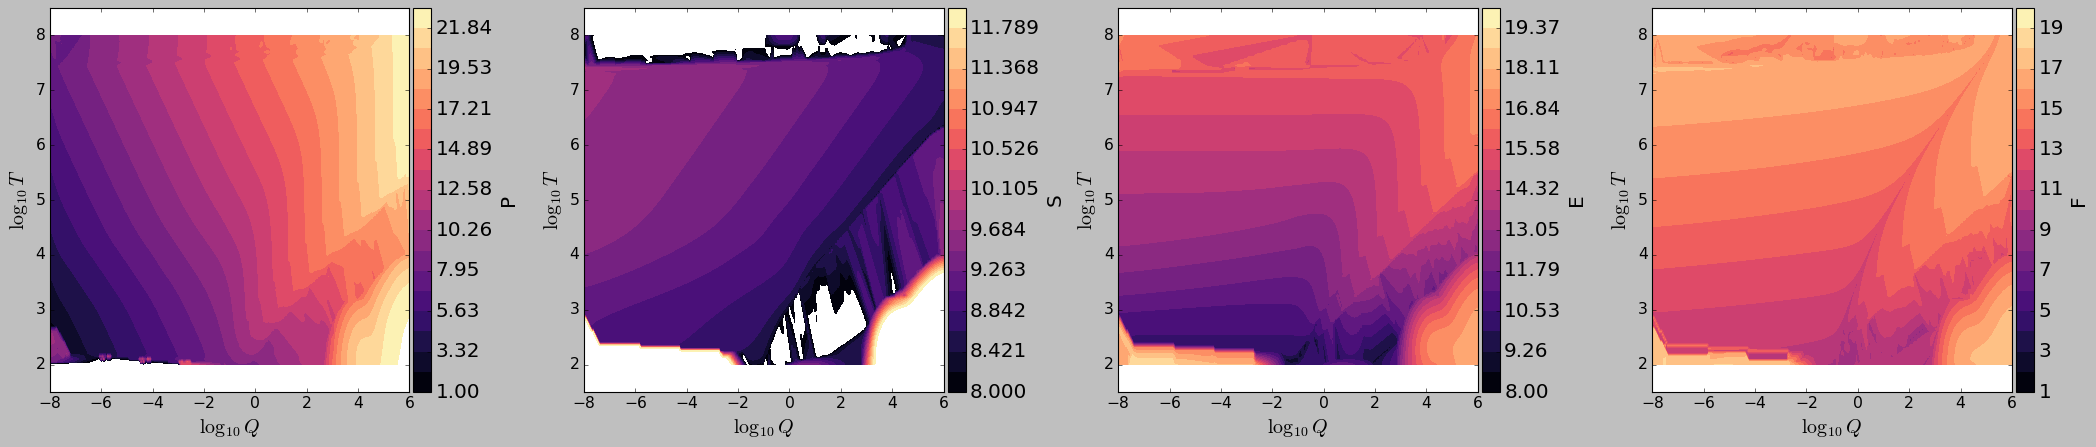

In [56]:
for s_i, s in enumerate(smoothing_arr):
    print(s)
    TC = copy.deepcopy(mixed_XYZ_rhoT)
    
    TC.compute_atomic_number()
    TC.compute_F_table(F_smoothing_kernel=s, F_nan_fill_value='reflect')

    meos.contourf_subplots_with_colorbars(nRow=1, nCol=4, 
                                xs=TC.log10rhogrid,
                                ys=TC.log10Tgrid,
                                zs=[TC.log10Pgrid,TC.log10Sgrid,TC.log10Egrid,np.log10(np.abs(10**TC.log10Egrid - ((10**TC.log10Tgrid) * (10**TC.log10Sgrid))))],
                                xlims=(-8,6),
                                ylims=(1.5,8.5),
                                zlims=[(1,23),(8,12),(8,20),(1,20)],
                                levels=20,
                                xlabels=r'$\log_{10}Q$',
                                ylabels=r'$\log_{10}T$',
                                zlabels=['P','S','E','F'],
                                cmap='magma', vlines=None, hlines=None, otherlines_x=None, otherlines_y=None, 
                                species='H', plot_interpolation_lines=False, savename=None)


    # replace existing PSE grids with F-based versions
    TC.log10Pgrid = meos.fill_in_nans(TC.F_log10Pgrid,TC)
    TC.log10Sgrid = meos.fill_in_nans(TC.F_log10Sgrid,TC)
    TC.log10Egrid = meos.fill_in_nans(TC.F_log10Egrid,TC)

    TC.log10Ugrid = TC.log10Egrid
    TC.compute_partials()

    meos.contourf_subplots_with_colorbars(nRow=1, nCol=4, 
                                xs=TC.log10rhogrid,
                                ys=TC.log10Tgrid,
                                zs=[TC.log10Pgrid,TC.log10Sgrid,TC.log10Egrid,np.log10(np.abs(10**TC.log10Egrid - ((10**TC.log10Tgrid) * (10**TC.log10Sgrid))))],
                                xlims=(-8,6),
                                ylims=(1.5,8.5),
                                zlims=[(1,23),(8,12),(8,20),(1,20)],
                                levels=20,
                                xlabels=r'$\log_{10}Q$',
                                ylabels=r'$\log_{10}T$',
                                zlabels=['P','S','E','F'],
                                cmap='magma', vlines=None, hlines=None, otherlines_x=None, otherlines_y=None, 
                                species='H', plot_interpolation_lines=False, savename=None)


    MESA_cols_6to16(TC,X=0.706,Y=0.277,mu_Z=0.5*(18.015 + 140.689),calc_eta=False)
    
    TC.log10Qgrid = TC.log10rhogrid - 2.*TC.log10Tgrid + 12
    TC_QT = change_table_coordinates(TC,extrapolation_row_idxs=None)
    '''
    meos.contourf_sublots_with_colorbars(nRow=1, nCol=2, 
                                xs=TC_QT.log10Qgrid_QT,
                                ys=TC_QT.log10Tgrid_QT,
                                zs=[TC_QT.dE_drho_T_QT,TC_QT.Cp_QT],
                                xlims=(-12,5.4),
                                ylims=(2,8),
                                zlims=None,
                                levels=20,
                                xlabels=r'$\log_{10}Q$',
                                ylabels=r'$\log_{10}T$',
                                zlabels=['dE_drho','Cp'],
                                cmap='magma', vlines=None, hlines=None, otherlines_x=[x], otherlines_y=[y1,y2], 
                                 species='H', plot_interpolation_lines=False, savename=None)
    '''
    #write_MESA_table_QT(TC_QT, './my_MESAformat_tables/mesa-planetblend-TC_s={0}_protosolar.data'.format(s),version=1, X=0.706, Z=0.017)
    write_MESA_table_QT(TC_QT, './meos_MESAformat_CMS19+HG23+rock+water/mesa-planetblend-TC_s={0}_protosolar.data'.format(s),version=1, X=0.706, Z=0.017)
      

/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/652309645.py:178: RuntimeWarning: invalid value encountered in log10
  self.F_log10Pgrid = np.log10(self.F_Pgrid)
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/652309645.py:179: RuntimeWarning: invalid value encountered in log10
  self.F_log10Sgrid = np.log10(self.F_Sgrid)
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/652309645.py:180: RuntimeWarning: invalid value encountered in log10
  self.F_log10Egrid = np.log10(self.F_Egrid)
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/3907226033.py:18: RuntimeWarning: invalid value encountered in log10
  control.log10Pgrid = np.log10( 10**control.log10Pgrid - sf*P_diff )
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_15053/3907226033.py:19: RuntimeWarning: invalid value encountered in log10
  control.log10Sgrid = np.log10( 10**control.log10Sgrid - sf*S_diff )
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipyker

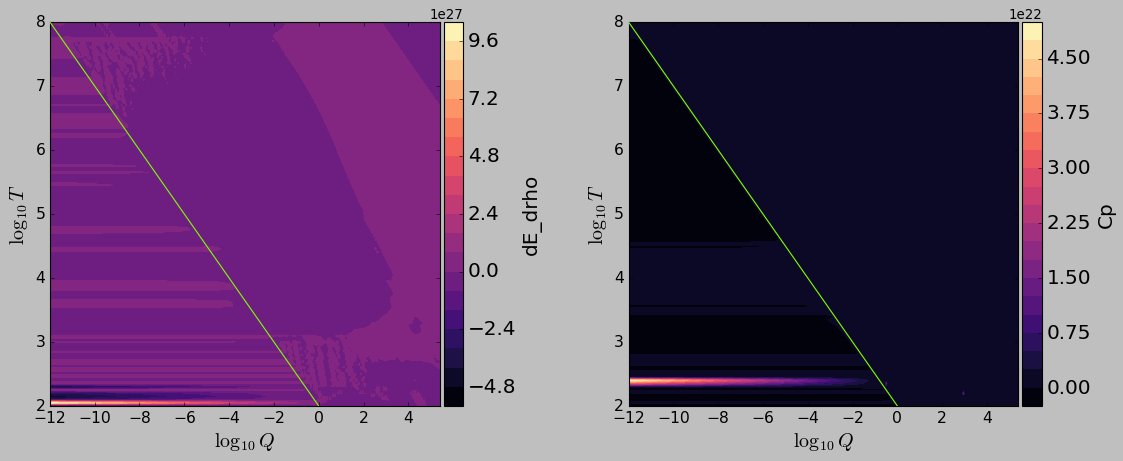

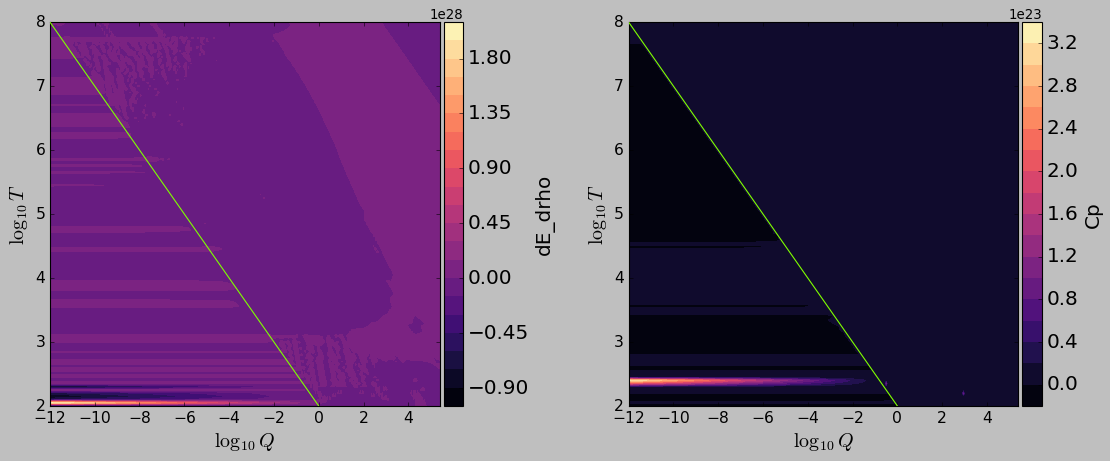

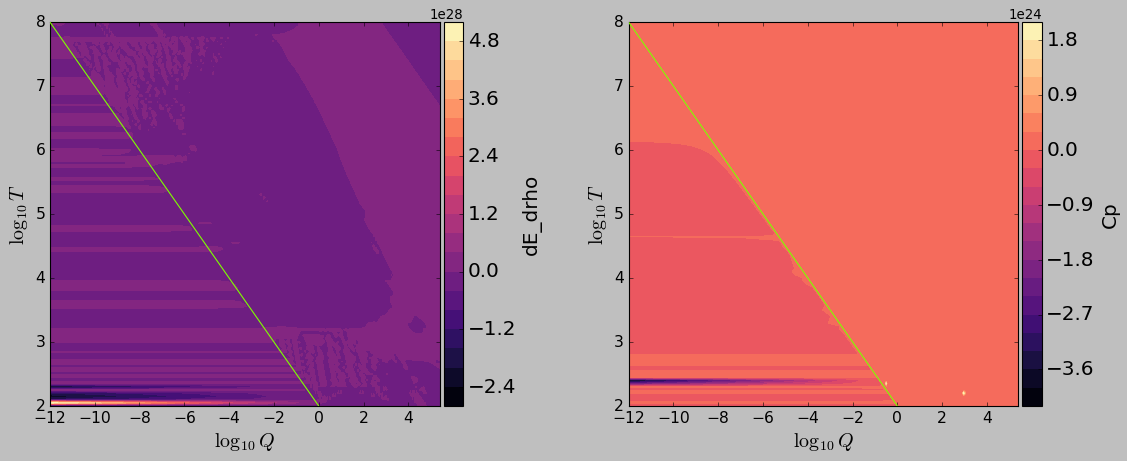

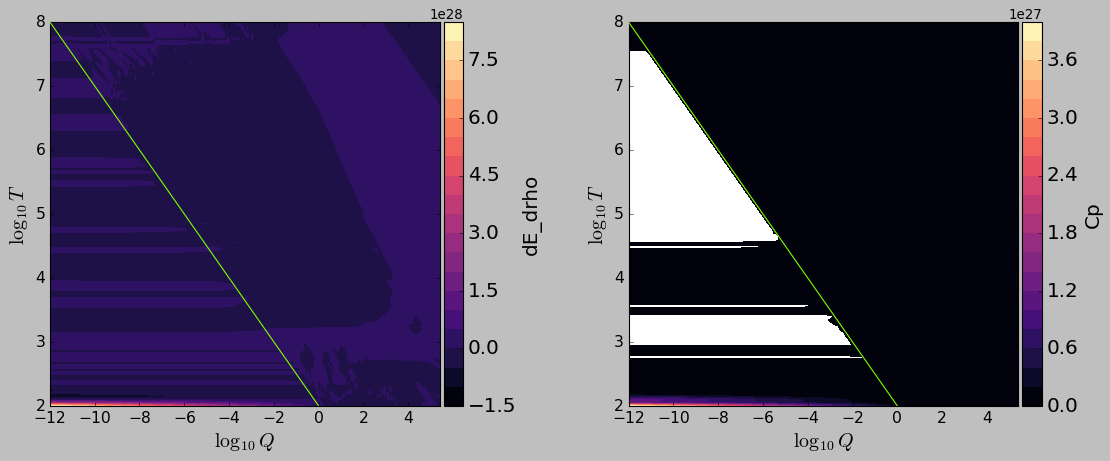

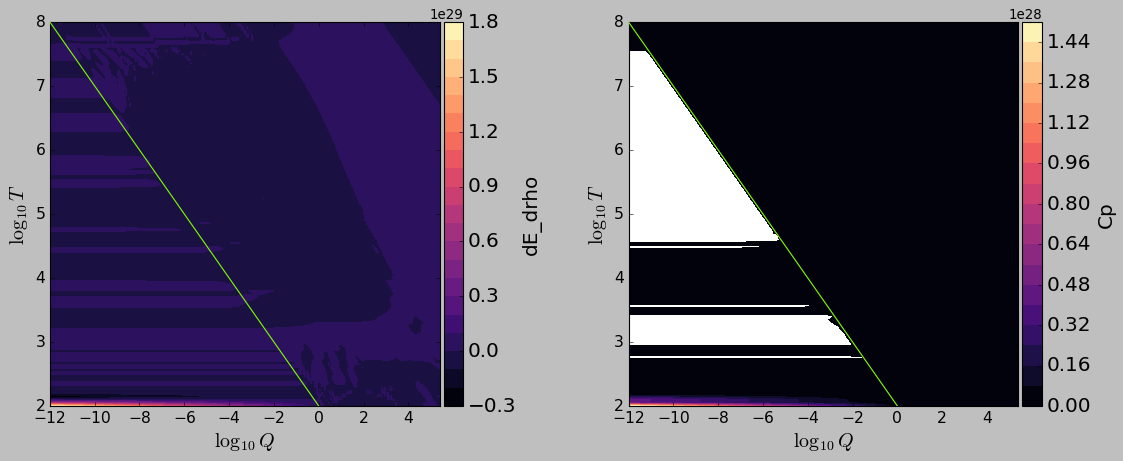

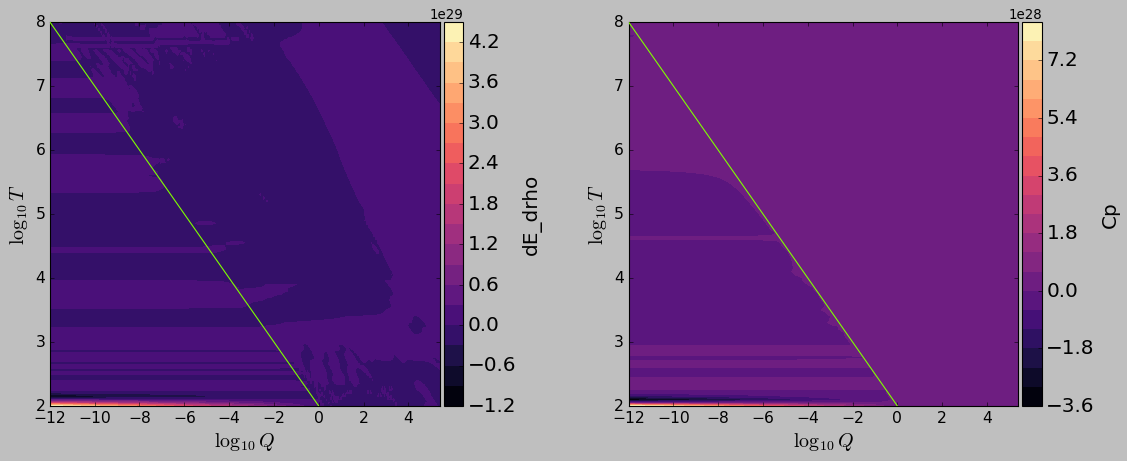

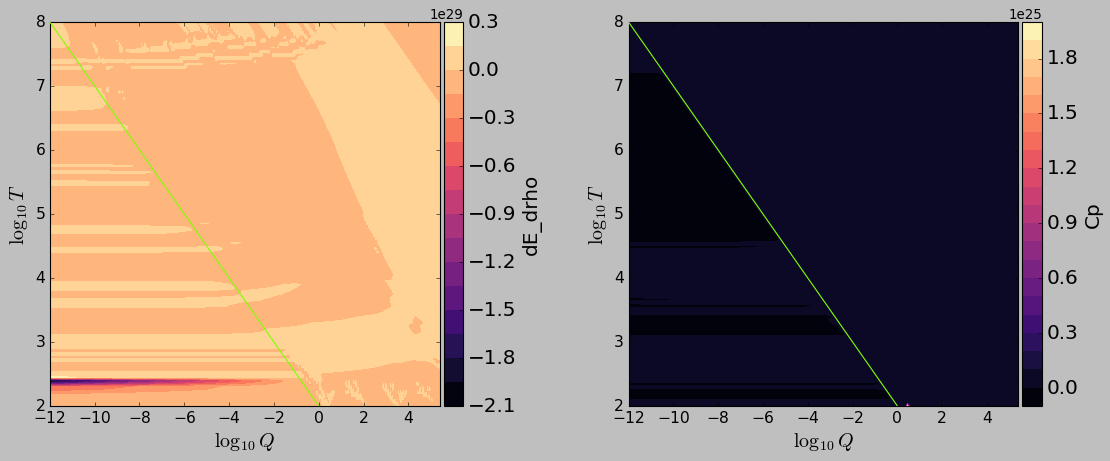

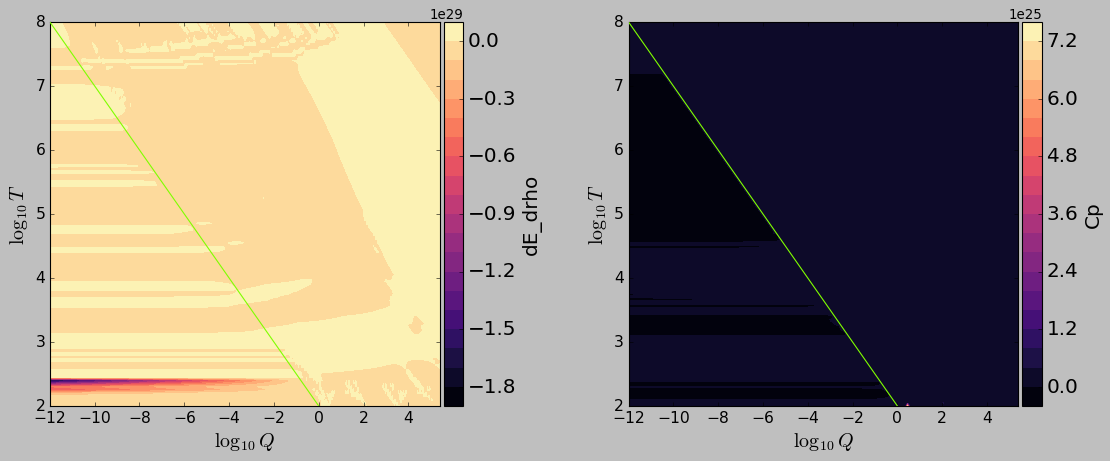

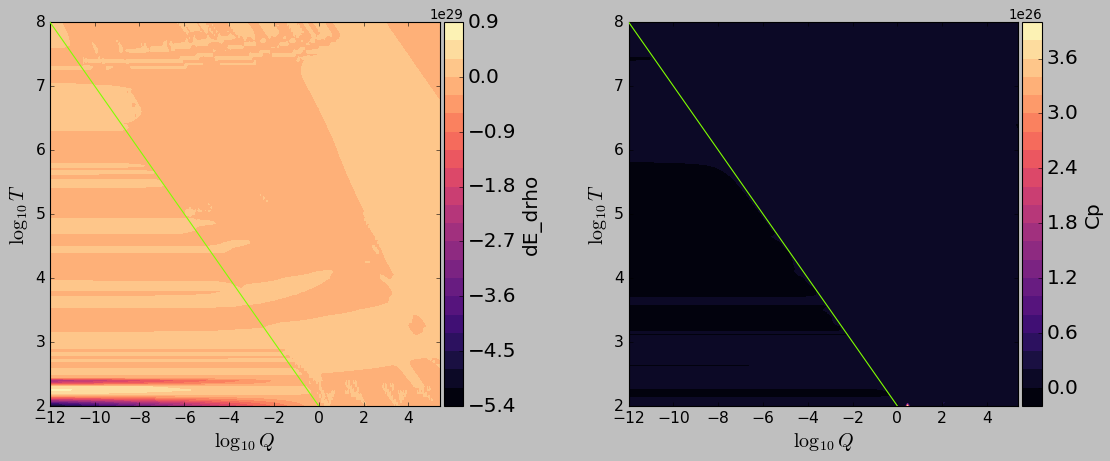

In [57]:
for s_i, s in enumerate(smoothing_arr):
    for sf_i, sf in enumerate(scaling_fac_arr):
        control = copy.deepcopy(mixed_XYZ_rhoT)

        control.compute_atomic_number()
        control.compute_F_table(F_smoothing_kernel=s, F_nan_fill_value='reflect')

        control.F_Pgrid = meos.fill_in_nans(control.F_Pgrid,control)
        control.F_Sgrid = meos.fill_in_nans(control.F_Sgrid,control)
        control.F_Egrid = meos.fill_in_nans(control.F_Egrid,control)
    
    
        # replace existing PSE grids with F-based versions
        P_diff = control.F_Pgrid - 10**control.log10Pgrid
        S_diff = control.F_Sgrid - 10**control.log10Sgrid
        E_diff = control.F_Egrid - 10**control.log10Egrid

        control.log10Pgrid = np.log10( 10**control.log10Pgrid - sf*P_diff )
        control.log10Sgrid = np.log10( 10**control.log10Sgrid - sf*S_diff )
        control.log10Egrid = np.log10( 10**control.log10Egrid - sf*E_diff )

        control.log10Pgrid = meos.fill_in_nans(control.log10Pgrid,control)
        control.log10Sgrid = meos.fill_in_nans(control.log10Sgrid,control)
        control.log10Egrid = meos.fill_in_nans(control.log10Egrid,control)
            
    
        control.log10Ugrid = control.log10Egrid
        control.compute_partials()
    
        MESA_cols_6to16(control,X=0.706,Y=0.277,mu_Z=0.5*(18.015 + 140.689),calc_eta=False)
        
        control.log10Qgrid = control.log10rhogrid - 2.*control.log10Tgrid + 12
        control_QT = change_table_coordinates(control,extrapolation_row_idxs=None)

        meos.contourf_subplots_with_colorbars(nRow=1, nCol=2, 
                                    xs=control_QT.log10Qgrid_QT,
                                    ys=control_QT.log10Tgrid_QT,
                                    zs=[control_QT.dE_drho_T_QT,control_QT.Cp_QT],
                                    xlims=(-12,5.4),
                                    ylims=(2,8),
                                    zlims=None,
                                    levels=20,
                                    xlabels=r'$\log_{10}Q$',
                                    ylabels=r'$\log_{10}T$',
                                    zlabels=['dE_drho','Cp'],
                                    cmap='magma', vlines=None, hlines=None, otherlines_x=[x], otherlines_y=[y1,y2], 
                                    species='H', plot_interpolation_lines=False, savename=None)

        
        #write_MESA_table_QT(control_QT, './my_MESAformat_tables/mesa-planetblend-control_s={0}_sf={1}_protosolar.data'.format(s,sf),version=1, X=0.706,Z=0.017)
        write_MESA_table_QT(control_QT, './meos_MESAformat_CMS19+HG23+rock+water/mesa-planetblend-control_s={0}_sf={1}_protosolar.data'.format(s,sf),version=1, X=0.706,Z=0.017)
          